In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


## 2. Load Data
- Each function dataset has input dimensions (x1, x2, ..., x8) and output 'y'. (10 Data Points)



In [2]:
import os

try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# Dictionary to store all function datasets
functions_data = {}

for i in range(1, 9):

    # Build file paths
    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    # Load .npy arrays
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)


    # Reshape to 2D if needed
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # Create column names (temporary)
    input_cols = [f"input_{j}" for j in range(inputs.shape[1])]
    output_cols = [f"output_{j}" for j in range(outputs.shape[1])]
    
    # Concatenate inputs + outputs
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)


    # Rename columns in-place
    new_input_names = {col: f"X{j+1}" for j, col in enumerate(input_cols)}
    new_output_names = {col: f"y{j+1}" for j, col in enumerate(output_cols)}
    df_combined.rename(columns={**new_input_names, **new_output_names}, inplace=True)


    # Store in dictionary
    functions_data[f"f{i}"] = df_combined

    print(f"Loaded function {i}: shape = {df_combined.shape}, columns = {df_combined.columns.tolist()}")


Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


In [3]:
# Manually define Week 1 submission results
week1_results = {
    "f1": ([0.793600, 0.666269], 1.4034986520274933e-21),
    "f2": ([0.554975, 0.999446], -0.07640833812988071),
    "f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328),
    "f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305),
    "f5": ([0.037069, 0.974641, 0.864911, 0.019169], 684.5607486761136),
    "f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064),
    "f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847),
    "f8": ([0.311992, 0.966526, 0.355002, 0.358409, 0.551500, 0.690176, 0.717450, 0.542367], 8.4452078666581),
}

In [4]:
week2_results = {
    "f1": ([0.800601, 0.002800], 9.069108791316283e-223),
    "f2": ([0.999500, 0.001800], -0.07975546223482953),
    "f3": ([0.967200, 0.029200, 0.723300], -0.20496612752890705),
    "f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795),
    "f5": ([0.624000, 0.735500, 0.976700, 0.994100], 2434.328593289806),
    "f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203),
    "f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147),
    "f8": ([0.293300, 0.174300, 0.080500, 0.056000, 0.429100, 0.492300, 0.221400, 0.410200], 9.835131961),
}

In [5]:
week3_results = {
    "f1": ([0.729726, 0.729276], 5.31459276351908e-15),
    "f2": ([0.727681, 0.187140], 0.5037032225936308),
    "f3": ([0.437962, 0.715305, 0.000876], -0.1117676821078815),
    "f4": ([0.402906, 0.437778, 0.329101, 0.424377], 0.07045398603133579),
    "f5": ([0.898795, 0.963833, 1.000000, 0.791851], 4171.124196806389),
    "f6": ([0.416408, 0.263572, 0.345102, 1.000000, 0.000000], -0.7670334120297669),
    "f7": ([0.000000, 0.189754, 0.123991, 0.253411, 0.406355, 0.251864], 0.4981320924641522),
    "f8": ([0.190768, 0.209525, 0.202591, 0.198246, 0.813824, 0.387519, 0.200772, 0.663670], 9.948688972661),
}

In [6]:
week4_results = {
    "f1": ([0.732162, 0.364472], 5.473776123300507e-57),
    "f2": ([0.715483, 0.563901], 0.5661662506769448),
    "f3": ([0.387933, 0.405240, 0.580181], -0.041279121306865105),
    "f4": ([0.351926, 0.442039, 0.451511, 0.443953], -0.27637133038944084),
    "f5": ([0.072013, 0.315203, 0.125702, 0.883341], 15.250051561683966),
    "f6": (	[0.494472, 0.050000, 0.451934, 0.152883, 0.386469], -1.421729209627387),
    "f7": ([0.097366, 0.334928, 0.369818, 0.382418, 0.464971, 0.750762], 1.5985145628892428),
}

In [7]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results
}

for week, results in weekly_results.items():
    for func, (inputs, output) in results.items():
        # Convert inputs and outputs to DataFrame
        inputs = np.array(inputs).reshape(1, -1)
        output = np.array([output]).reshape(1, -1)
        
        # Dynamically generate input column names
        df_inputs = pd.DataFrame(inputs, columns=[f"X{i+1}" for i in range(inputs.shape[1])])
        # Use existing output column names from the function
        output_cols = [col for col in functions_data[func].columns if col.startswith("y")]
        df_outputs = pd.DataFrame(output, columns=output_cols)
        
        # Combine
        df_week = pd.concat([df_inputs, df_outputs], axis=1)
        
        # Append only rows that are not already in the DataFrame
        functions_data[func] = pd.concat([functions_data[func], df_week], ignore_index=True)
        functions_data[func] = functions_data[func].drop_duplicates(ignore_index=True)

# Optional: check updated shapes
for func, df in functions_data.items():
    print(f"{func} updated shape: {df.shape}")


f1 updated shape: (14, 3)
f2 updated shape: (14, 3)
f3 updated shape: (19, 4)
f4 updated shape: (34, 5)
f5 updated shape: (24, 5)
f6 updated shape: (24, 6)
f7 updated shape: (34, 7)
f8 updated shape: (43, 9)


In [8]:
for name, df in functions_data.items():
    print(df)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
1

In [9]:
for name, df in functions_data.items():
    print(f"\n{name} Summary Statistics")
    
    # Display numeric summary statistics
    display(df.describe().T)  # Transposed for easier reading (features as rows)





f1 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,14.0,0.610304,0.238780,0.082507,4.514102e-01,7.065721e-01,7.782405e-01,8.838898e-01
X2,14.0,0.511286,0.297192,0.002800,2.896667e-01,6.242615e-01,7.320689e-01,8.798981e-01
y1,14.0,-0.000258,0.000964,-0.003606,8.354428e-125,2.736888e-57,1.901251e-40,5.314593e-15



f2 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,14.0,0.598769,0.237839,0.142699,0.442286,0.621756,0.724631,0.999500
X2,14.0,0.473685,0.341308,0.001800,0.193822,0.456453,0.756760,0.999446
y1,14.0,0.230032,0.261012,-0.079755,-0.004617,0.229792,0.482924,0.611205



f3 Summary Statistics


...

,count,mean,std,min,25%,50%,75%,max
X1,24.0,0.537339,0.280526,0.021735,0.337459,0.577805,0.760851,0.957740
X2,24.0,0.491474,0.308247,0.001300,0.256596,0.391958,0.796129,0.931871
X3,24.0,0.482424,0.302633,0.016523,0.303186,0.447609,0.714228,0.978806
X4,24.0,0.561856,0.294992,0.045613,0.329066,0.663673,0.772533,1.000000
X5,24.0,0.383290,0.291326,0.000000,0.111981,0.357652,0.602252,0.892819
y1,24.0,-1.389527,0.502947,-2.571170,-1.696397,-1.332899,-1.092528,-0.564857



f7 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,34.0,0.477381,0.321392,0.000000,0.155480,0.534869,0.783687,0.942451
X2,34.0,0.400783,0.259088,0.011813,0.197771,0.359191,0.543137,0.949047
X3,34.0,0.391215,0.311589,0.003635,0.108508,0.318555,0.662281,0.924571
X4,34.0,0.481923,0.306806,0.073659,0.220787,0.401401,0.794507,0.961017
X5,34.0,0.465937,0.297672,0.014944,0.208411,0.442700,0.711722,0.998655
X6,34.0,0.496308,0.274608,0.051100,0.276764,0.552544,0.724095,0.980800
y1,34.0,0.278728,0.386661,0.002701,0.018992,0.088196,0.492448,1.598515



f8 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,43.0,0.515824,0.307645,0.009077,0.242970,0.506028,0.785353,0.985945
X2,43.0,0.470612,0.314066,0.003419,0.191912,0.523642,0.725326,0.973980
X3,43.0,0.494811,0.284756,0.022929,0.275708,0.420888,0.728788,0.998885
X4,43.0,0.414665,0.260727,0.009043,0.179065,0.424597,0.650684,0.902986
X5,43.0,0.477964,0.276529,0.009649,0.243904,0.429100,0.725197,0.986902
X6,43.0,0.464535,0.269874,0.022113,0.248903,0.410105,0.698413,0.990244
X7,43.0,0.565290,0.261692,0.035909,0.360232,0.592415,0.764076,0.992914
X8,43.0,0.508955,0.272646,0.041956,0.304600,0.525348,0.722286,0.988755
y1,43.0,7.926512,1.027724,5.592193,7.305383,7.957875,8.573932,9.948689


#### Pearson Correlation


f1 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.144664,-0.047986
X2,0.144664,1.000000,-0.164871
y1,-0.047986,-0.164871,1.000000


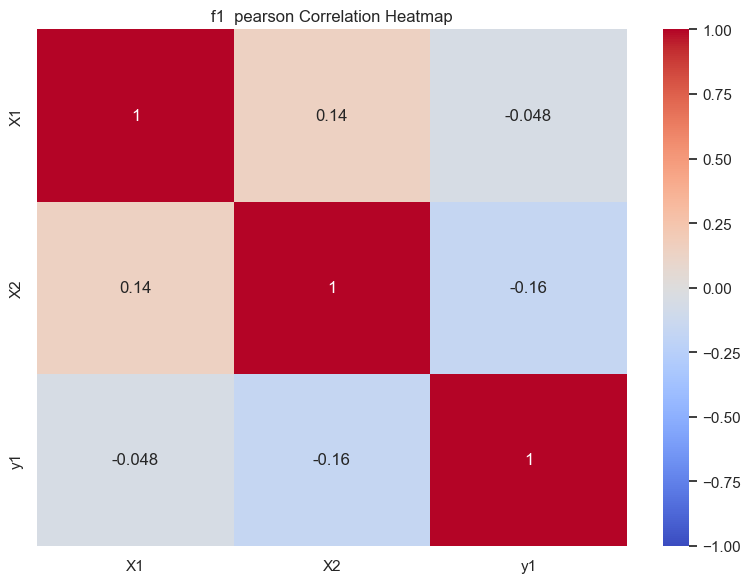


f2 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.145630,0.427072
X2,0.145630,1.000000,0.176419
y1,0.427072,0.176419,1.000000


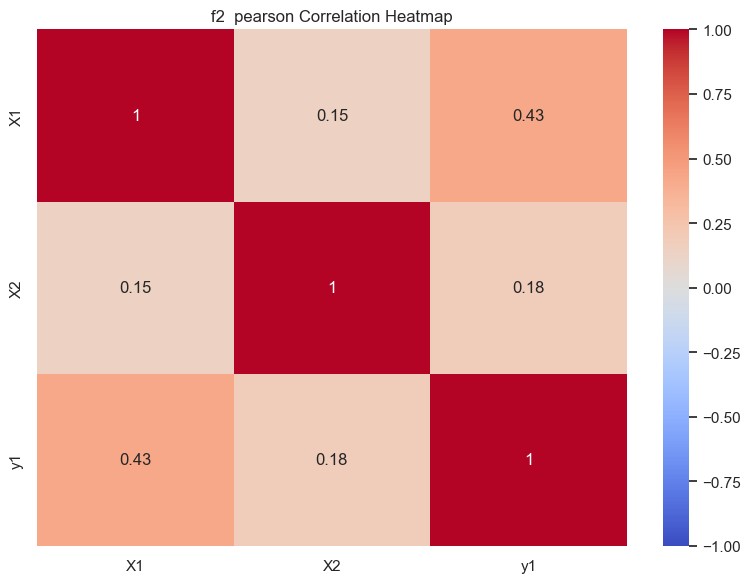


f3 Pearson Correlation Matrix


,X1,X2,X3,y1
X1,1.000000,0.089360,0.005217,0.062872
X2,0.089360,1.000000,-0.448060,0.211647
X3,0.005217,-0.448060,1.000000,-0.487042
y1,0.062872,0.211647,-0.487042,1.000000


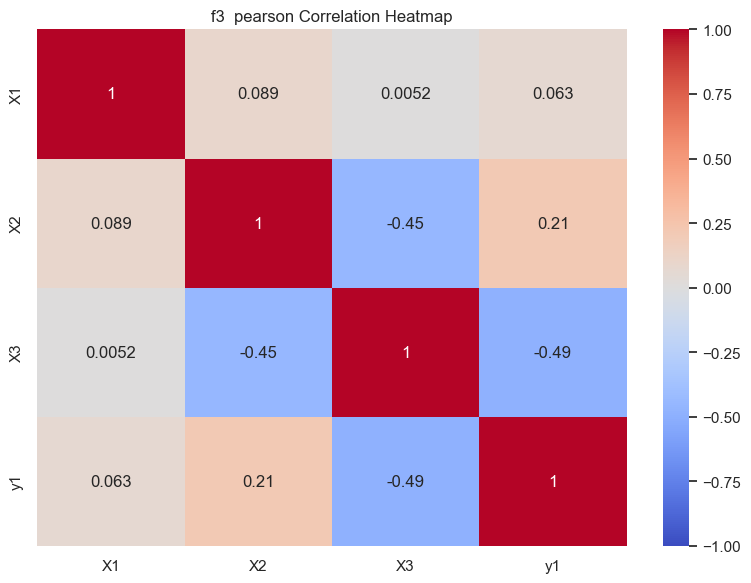


f4 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,0.254114,0.257530,0.192054,-0.499510
X2,0.254114,1.000000,-0.066129,0.190234,-0.445026
X3,0.257530,-0.066129,1.000000,-0.149093,-0.128449
X4,0.192054,0.190234,-0.149093,1.000000,-0.444465
y1,-0.499510,-0.445026,-0.128449,-0.444465,1.000000


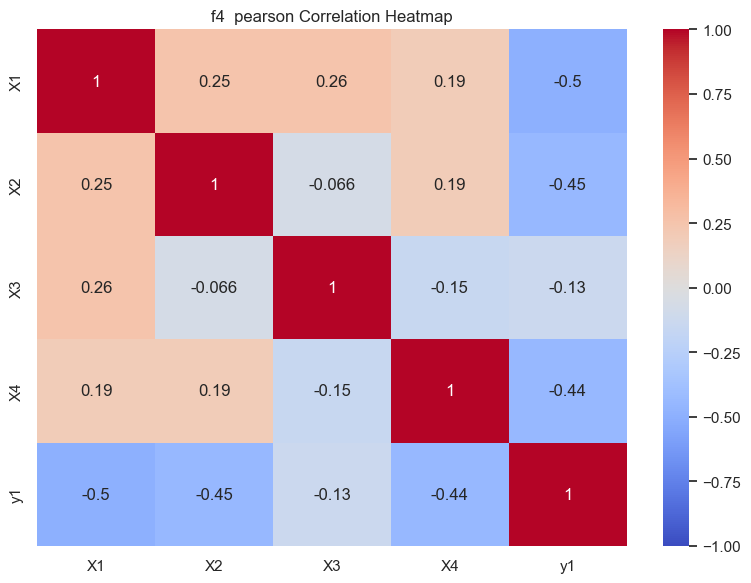


f5 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,-0.072005,0.049652,0.184863,0.302189
X2,-0.072005,1.000000,0.198657,0.141763,0.460820
X3,0.049652,0.198657,1.000000,-0.075194,0.573766
X4,0.184863,0.141763,-0.075194,1.000000,0.368490
y1,0.302189,0.460820,0.573766,0.368490,1.000000


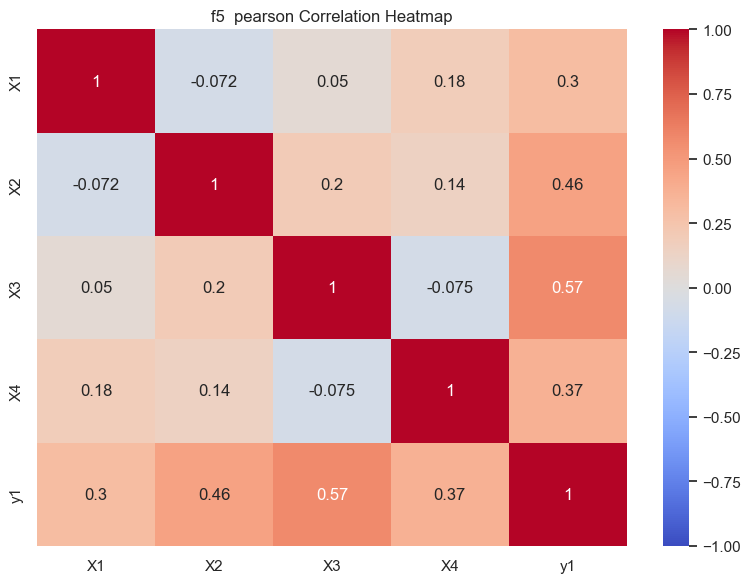


f6 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.178192,-0.073340,0.119006,-0.364324,0.043584
X2,-0.178192,1.000000,0.157162,-0.177347,0.318523,-0.465285
X3,-0.073340,0.157162,1.000000,0.193606,-0.135937,0.284785
X4,0.119006,-0.177347,0.193606,1.000000,-0.319533,0.596879
X5,-0.364324,0.318523,-0.135937,-0.319533,1.000000,-0.643047
y1,0.043584,-0.465285,0.284785,0.596879,-0.643047,1.000000


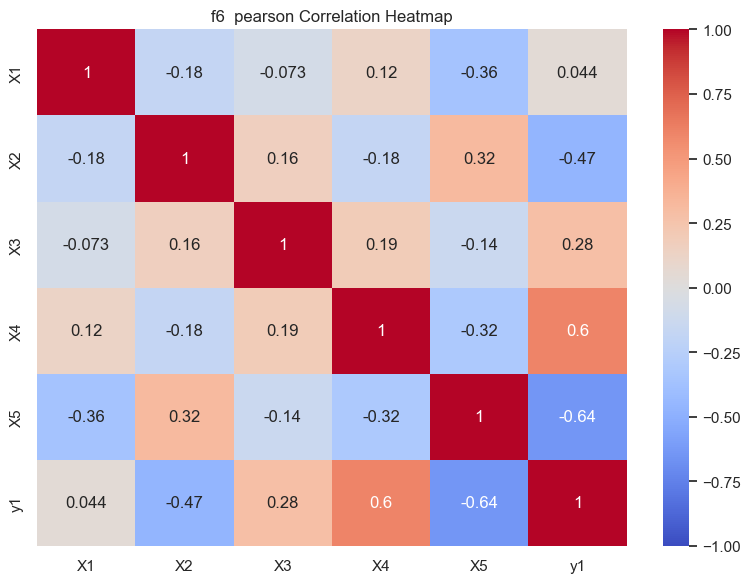


f7 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.057890,-0.072440,-0.050867,0.014644,-0.453658,-0.464466
X2,0.057890,1.000000,0.081471,0.130499,0.337865,0.123821,-0.064596
X3,-0.072440,0.081471,1.000000,0.199813,-0.244704,0.035895,0.052650
X4,-0.050867,0.130499,0.199813,1.000000,0.069669,0.007678,-0.147942
X5,0.014644,0.337865,-0.244704,0.069669,1.000000,0.066807,-0.312753
X6,-0.453658,0.123821,0.035895,0.007678,0.066807,1.000000,0.374707
y1,-0.464466,-0.064596,0.052650,-0.147942,-0.312753,0.374707,1.000000


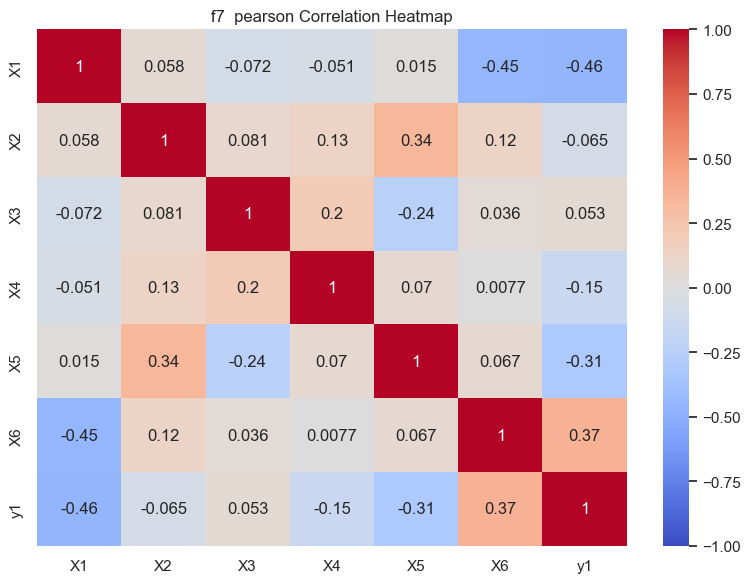


f8 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.162909,0.091203,0.148557,0.238145,0.153371,0.200447,0.118546,-0.643357
X2,0.162909,1.000000,0.112406,-0.158060,0.058318,0.015886,-0.109196,-0.264884,-0.263280
X3,0.091203,0.112406,1.000000,0.099979,-0.063805,-0.198387,-0.103447,0.001943,-0.661285
X4,0.148557,-0.158060,0.099979,1.000000,-0.063172,-0.109615,-0.029839,0.374282,-0.171586
X5,0.238145,0.058318,-0.063805,-0.063172,1.000000,0.080664,0.152486,0.071832,-0.093656
X6,0.153371,0.015886,-0.198387,-0.109615,0.080664,1.000000,-0.012955,0.057061,0.062779
X7,0.200447,-0.109196,-0.103447,-0.029839,0.152486,-0.012955,1.000000,-0.140989,-0.368870
X8,0.118546,-0.264884,0.001943,0.374282,0.071832,0.057061,-0.140989,1.000000,0.060706
y1,-0.643357,-0.263280,-0.661285,-0.171586,-0.093656,0.062779,-0.368870,0.060706,1.000000


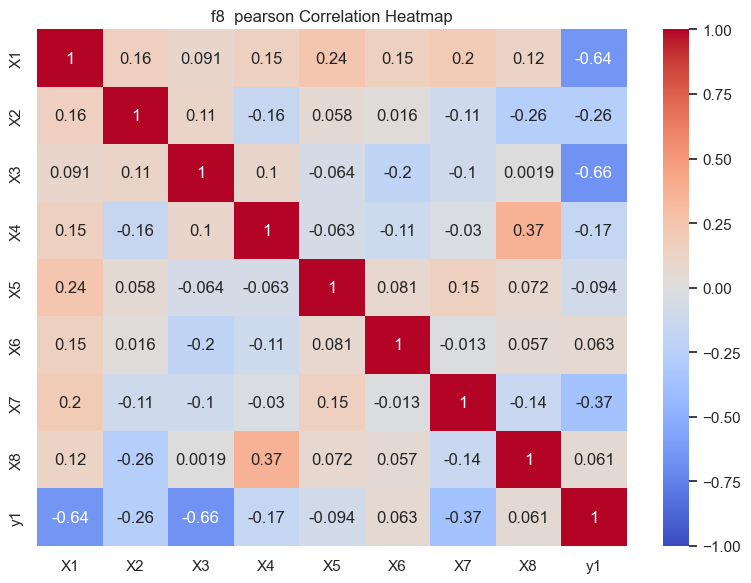

In [10]:
for name, df in functions_data.items():

    print(f"\n{name} Pearson Correlation Matrix")
    
    # Compute correlation matrix
    corr = df.corr()

    # Display numeric correlation table
    display(corr)

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )
    plt.title(f"{name}  pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

#### Spearman Correlation


f1 — Spearman Correlation


,X1,X2,y1
X1,1.000000,-0.156044,0.292308
X2,-0.156044,1.000000,0.626374
y1,0.292308,0.626374,1.000000


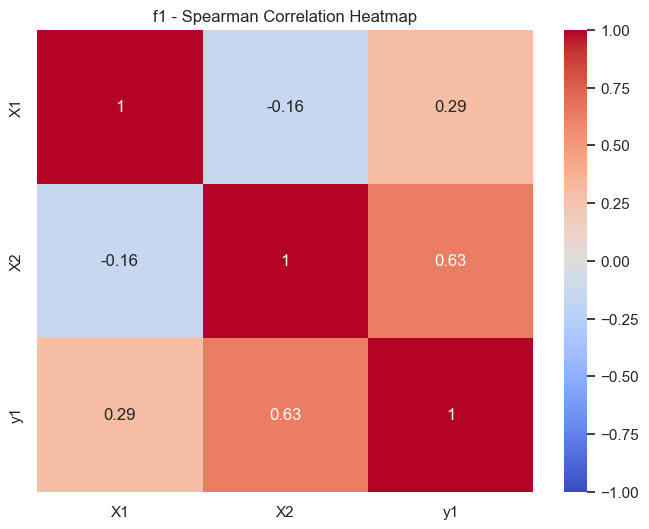


f2 — Spearman Correlation


,X1,X2,y1
X1,1.000000,0.076923,0.353846
X2,0.076923,1.000000,0.173626
y1,0.353846,0.173626,1.000000


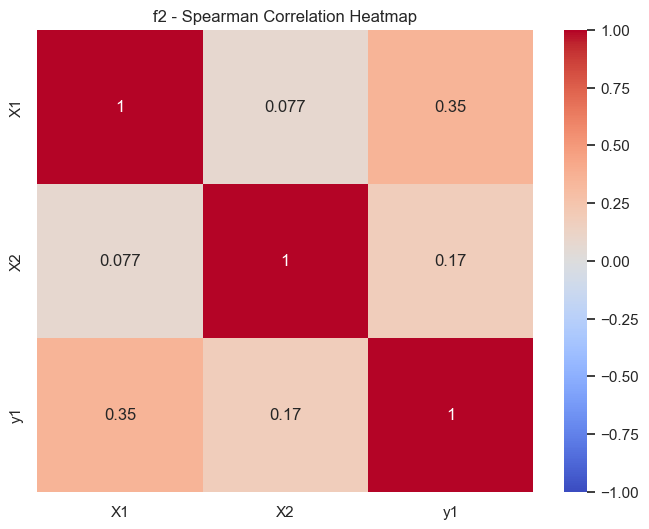


f3 — Spearman Correlation


,X1,X2,X3,y1
X1,1.000000,0.163158,-0.138596,-0.021053
X2,0.163158,1.000000,-0.424561,0.314035
X3,-0.138596,-0.424561,1.000000,-0.210526
y1,-0.021053,0.314035,-0.210526,1.000000


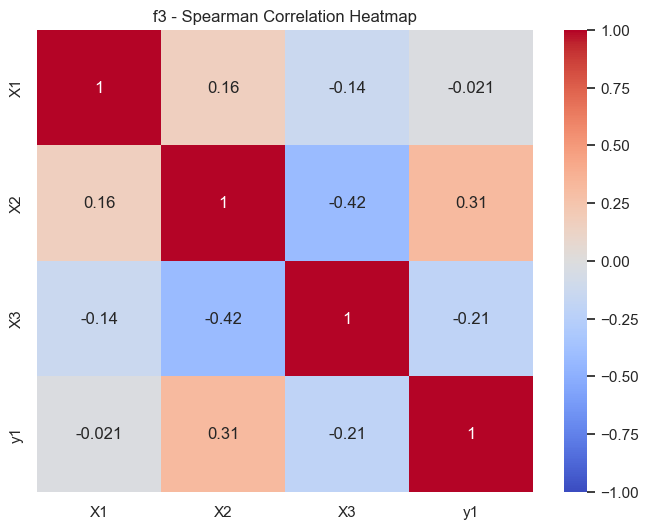


f4 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.265699,0.240336,0.191444,-0.508938
X2,0.265699,1.000000,-0.017876,0.169137,-0.451490
X3,0.240336,-0.017876,1.000000,-0.176776,-0.161803
X4,0.191444,0.169137,-0.176776,1.000000,-0.396180
y1,-0.508938,-0.451490,-0.161803,-0.396180,1.000000


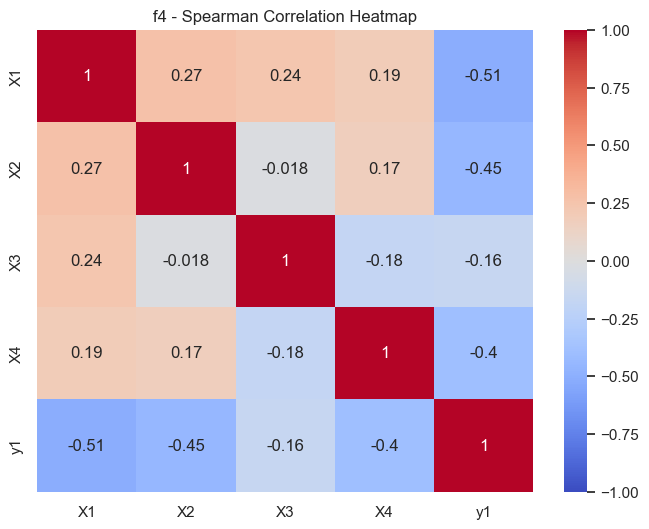


f5 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.116522,0.040870,0.140000,0.044348
X2,-0.116522,1.000000,0.272174,0.122609,0.400000
X3,0.040870,0.272174,1.000000,-0.097391,0.523478
X4,0.140000,0.122609,-0.097391,1.000000,0.409565
y1,0.044348,0.400000,0.523478,0.409565,1.000000


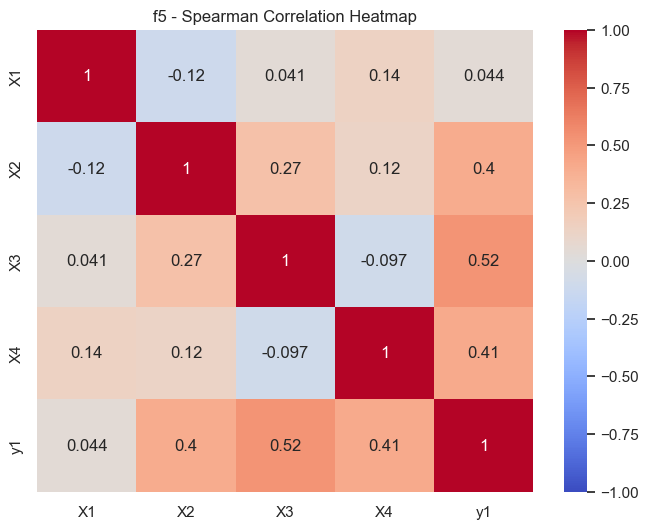


f6 — Spearman Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.125217,-0.051304,0.122609,-0.343478,-0.052174
X2,-0.125217,1.000000,0.079130,-0.150435,0.268696,-0.371304
X3,-0.051304,0.079130,1.000000,0.206957,-0.164348,0.260000
X4,0.122609,-0.150435,0.206957,1.000000,-0.376522,0.623478
X5,-0.343478,0.268696,-0.164348,-0.376522,1.000000,-0.628696
y1,-0.052174,-0.371304,0.260000,0.623478,-0.628696,1.000000


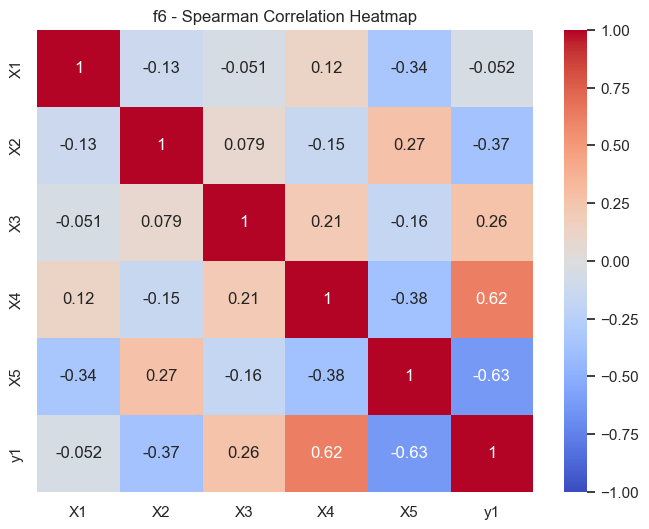


f7 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.006570,-0.056990,-0.040183,-0.026432,-0.418793,-0.425516
X2,0.006570,1.000000,0.050573,0.187166,0.348510,0.123300,-0.165775
X3,-0.056990,0.050573,1.000000,0.134301,-0.266616,0.089992,0.240947
X4,-0.040183,0.187166,0.134301,1.000000,0.066769,0.052406,-0.147441
X5,-0.026432,0.348510,-0.266616,0.066769,1.000000,0.050879,-0.429794
X6,-0.418793,0.123300,0.089992,0.052406,0.050879,1.000000,0.273644
y1,-0.425516,-0.165775,0.240947,-0.147441,-0.429794,0.273644,1.000000


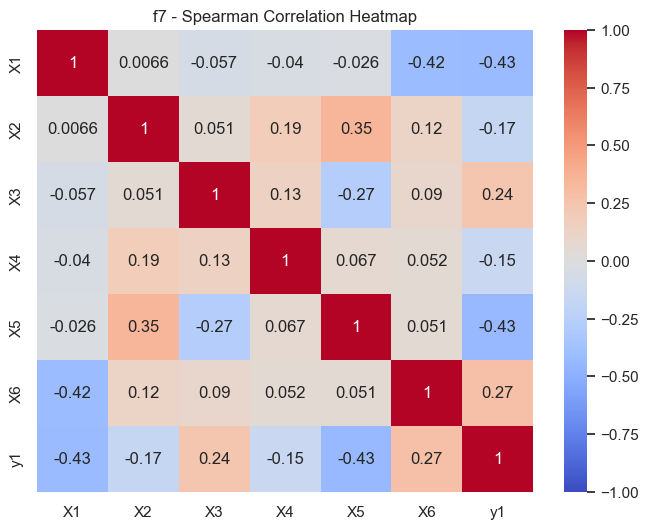


f8 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.171398,0.060254,0.144820,0.245243,0.161734,0.188010,0.111900,-0.624887
X2,0.171398,1.000000,0.127454,-0.164603,0.033827,-0.006191,-0.102235,-0.260344,-0.268952
X3,0.060254,0.127454,1.000000,0.138780,-0.077922,-0.168831,-0.087285,-0.034733,-0.617638
X4,0.144820,-0.164603,0.138780,1.000000,-0.086228,-0.136213,-0.015403,0.356992,-0.185291
X5,0.245243,0.033827,-0.077922,-0.086228,1.000000,0.123377,0.159015,0.034733,-0.054968
X6,0.161734,-0.006191,-0.168831,-0.136213,0.123377,1.000000,0.008457,0.099517,0.017970
X7,0.188010,-0.102235,-0.087285,-0.015403,0.159015,0.008457,1.000000,-0.131531,-0.365297
X8,0.111900,-0.260344,-0.034733,0.356992,0.034733,0.099517,-0.131531,1.000000,0.054666
y1,-0.624887,-0.268952,-0.617638,-0.185291,-0.054968,0.017970,-0.365297,0.054666,1.000000


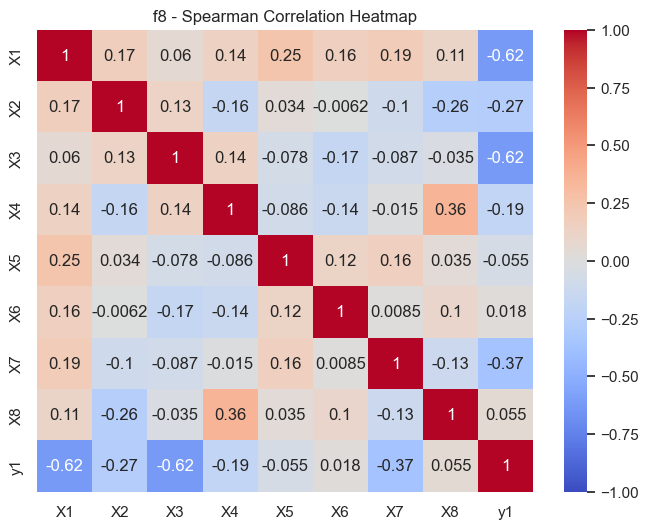

In [11]:
for name, df in functions_data.items():
    print(f"\n{name} — Spearman Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    spearman_corr = df[input_cols + output_cols].corr(method='spearman')
    display(spearman_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Spearman Correlation Heatmap")
    plt.show()

#### Kendall Correlation


f1 — Kendall Correlation


,X1,X2,y1
X1,1.000000,-0.142857,0.186813
X2,-0.142857,1.000000,0.450549
y1,0.186813,0.450549,1.000000


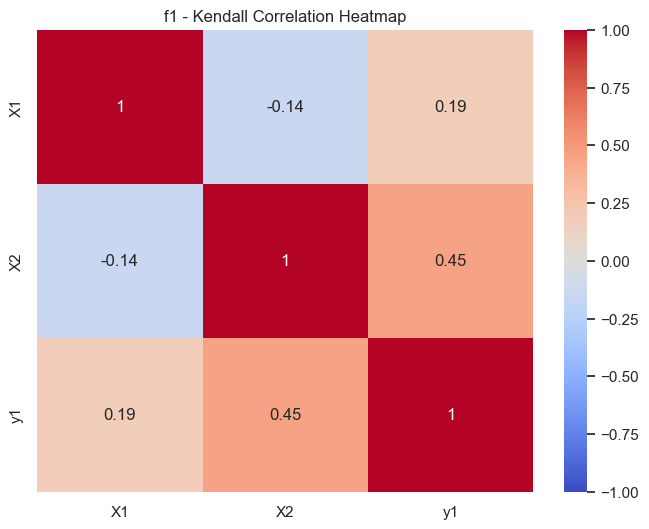


f2 — Kendall Correlation


,X1,X2,y1
X1,1.000000,0.054945,0.252747
X2,0.054945,1.000000,0.142857
y1,0.252747,0.142857,1.000000


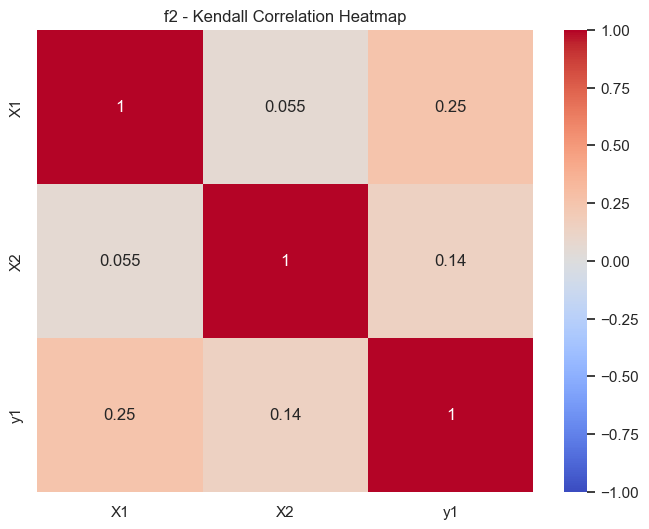


f3 — Kendall Correlation


,X1,X2,X3,y1
X1,1.000000,0.122807,-0.087719,0.005848
X2,0.122807,1.000000,-0.309942,0.228070
X3,-0.087719,-0.309942,1.000000,-0.099415
y1,0.005848,0.228070,-0.099415,1.000000


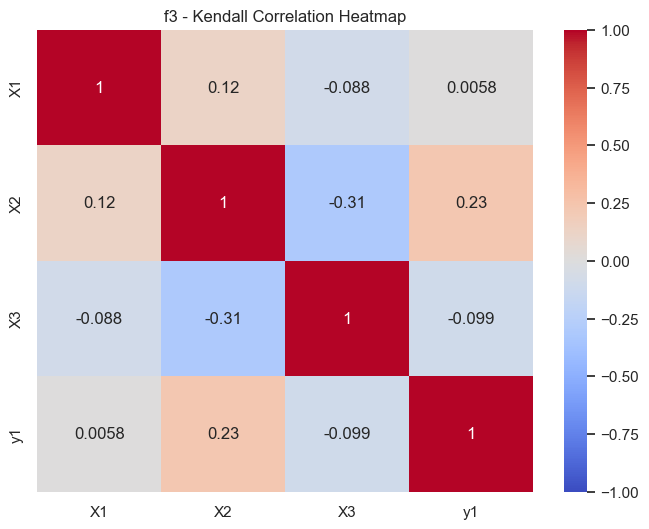


f4 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.187166,0.183601,0.133690,-0.351159
X2,0.187166,1.000000,0.005348,0.126560,-0.322638
X3,0.183601,0.005348,1.000000,-0.133690,-0.155080
X4,0.133690,0.126560,-0.133690,1.000000,-0.276292
y1,-0.351159,-0.322638,-0.155080,-0.276292,1.000000


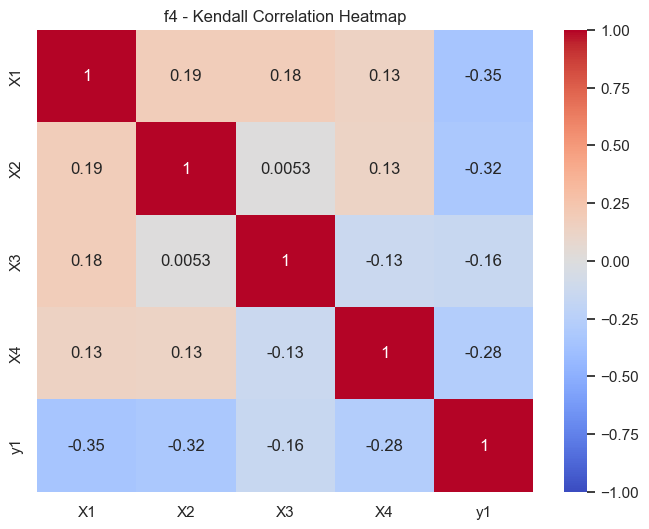


f5 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.094203,0.007246,0.115942,0.000000
X2,-0.094203,1.000000,0.159420,0.065217,0.253623
X3,0.007246,0.159420,1.000000,-0.094203,0.398551
X4,0.115942,0.065217,-0.094203,1.000000,0.289855
y1,0.000000,0.253623,0.398551,0.289855,1.000000


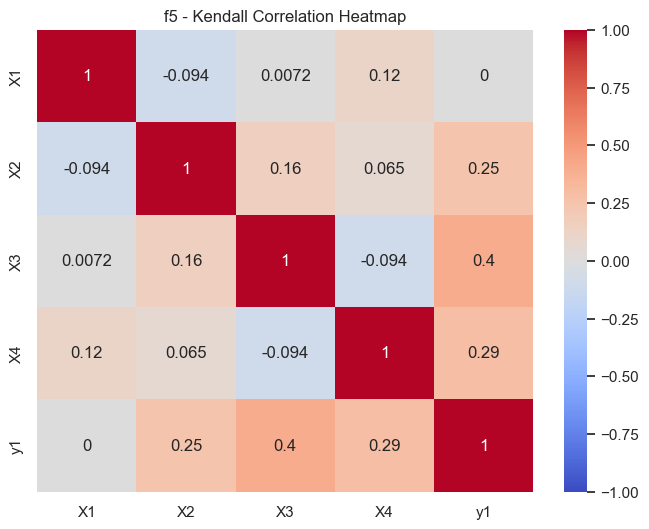


f6 — Kendall Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.094203,-0.028986,0.108696,-0.268116,-0.036232
X2,-0.094203,1.000000,0.065217,-0.101449,0.159420,-0.275362
X3,-0.028986,0.065217,1.000000,0.152174,-0.079710,0.181159
X4,0.108696,-0.101449,0.152174,1.000000,-0.304348,0.449275
X5,-0.268116,0.159420,-0.079710,-0.304348,1.000000,-0.434783
y1,-0.036232,-0.275362,0.181159,0.449275,-0.434783,1.000000


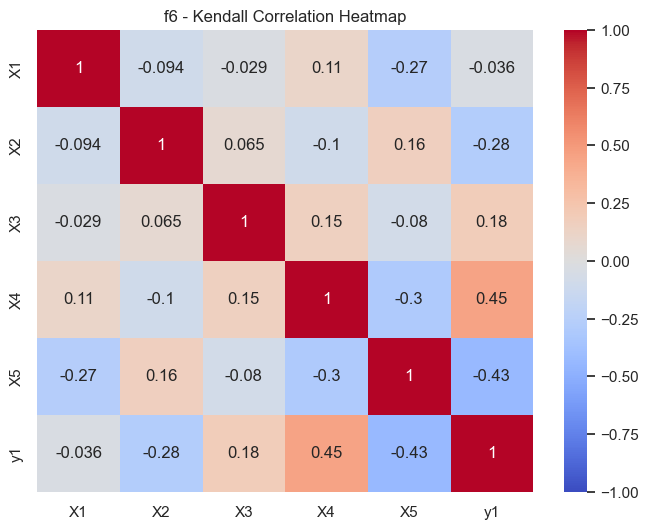


f7 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.030303,-0.037433,-0.030303,-0.040998,-0.283422,-0.340463
X2,0.030303,1.000000,0.026738,0.119430,0.237077,0.051693,-0.119430
X3,-0.037433,0.026738,1.000000,0.065954,-0.180036,0.076649,0.155080
X4,-0.030303,0.119430,0.065954,1.000000,0.048128,0.019608,-0.108734
X5,-0.040998,0.237077,-0.180036,0.048128,1.000000,0.058824,-0.283422
X6,-0.283422,0.051693,0.076649,0.019608,0.058824,1.000000,0.187166
y1,-0.340463,-0.119430,0.155080,-0.108734,-0.283422,0.187166,1.000000


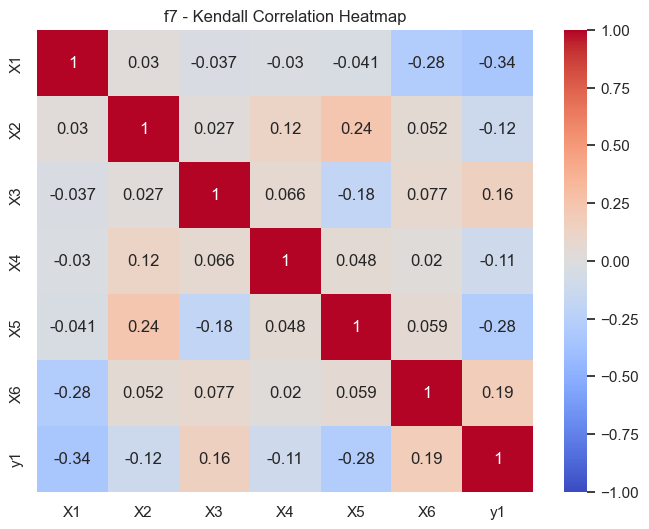


f8 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.127353,0.012182,0.087486,0.162791,0.089701,0.111849,0.071982,-0.450720
X2,0.127353,1.000000,0.078627,-0.125138,0.034330,-0.034330,-0.083056,-0.162791,-0.162791
X3,0.012182,0.078627,1.000000,0.074197,-0.045404,-0.118494,-0.052049,-0.025471,-0.450720
X4,0.087486,-0.125138,0.074197,1.000000,-0.054264,-0.065338,-0.007752,0.253599,-0.122924
X5,0.162791,0.034330,-0.045404,-0.054264,1.000000,0.089701,0.107420,0.032115,-0.025471
X6,0.089701,-0.034330,-0.118494,-0.065338,0.089701,1.000000,0.012182,0.060908,-0.001107
X7,0.111849,-0.083056,-0.052049,-0.007752,0.107420,0.012182,1.000000,-0.089701,-0.280177
X8,0.071982,-0.162791,-0.025471,0.253599,0.032115,0.060908,-0.089701,1.000000,0.043189
y1,-0.450720,-0.162791,-0.450720,-0.122924,-0.025471,-0.001107,-0.280177,0.043189,1.000000


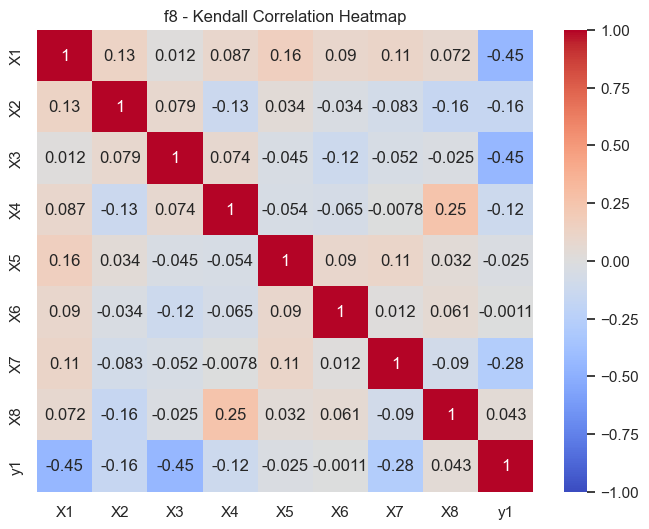

In [12]:
for name, df in functions_data.items():
    print(f"\n{name} — Kendall Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    ken_corr = df[input_cols + output_cols].corr(method='kendall')
    display(ken_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(ken_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()

#### Mutual Information


=== f1 — Kendall Correlation ===


,X1,X2,y1
X1,1.000000,-0.142857,0.186813
X2,-0.142857,1.000000,0.450549
y1,0.186813,0.450549,1.000000


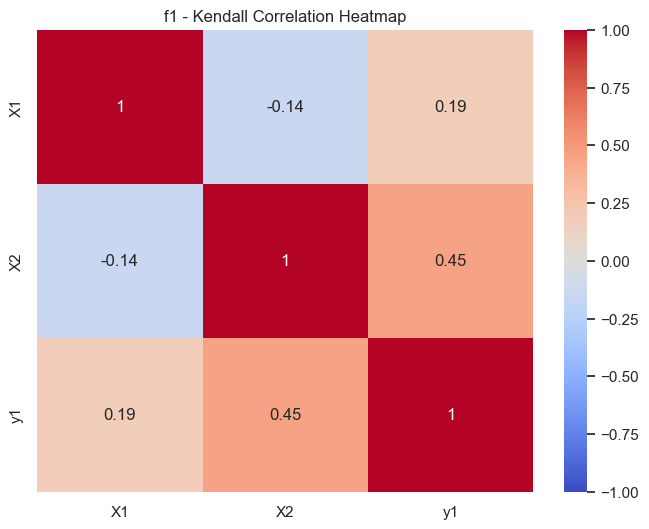


=== f2 — Kendall Correlation ===


,X1,X2,y1
X1,1.000000,0.054945,0.252747
X2,0.054945,1.000000,0.142857
y1,0.252747,0.142857,1.000000


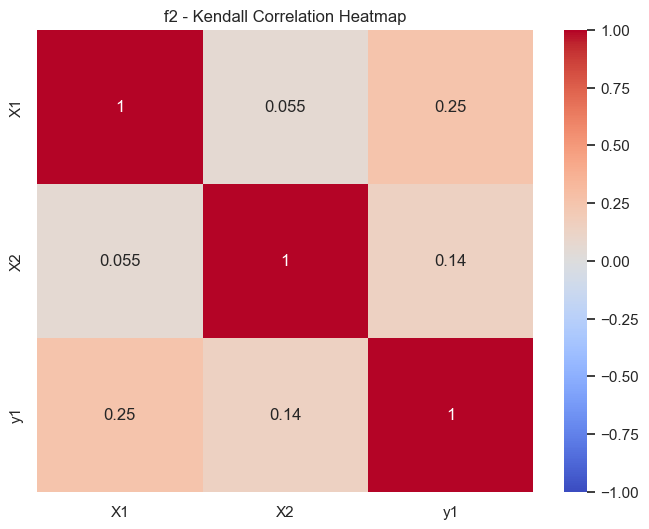


=== f3 — Kendall Correlation ===


,X1,X2,X3,y1
X1,1.000000,0.122807,-0.087719,0.005848
X2,0.122807,1.000000,-0.309942,0.228070
X3,-0.087719,-0.309942,1.000000,-0.099415
y1,0.005848,0.228070,-0.099415,1.000000


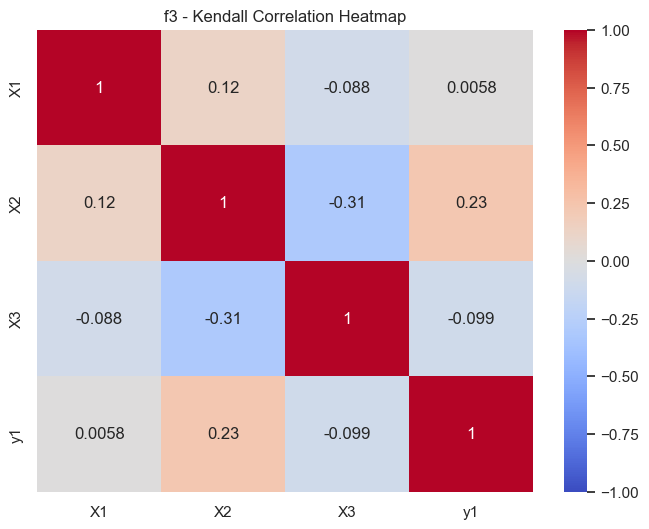


=== f4 — Kendall Correlation ===


,X1,X2,X3,X4,y1
X1,1.000000,0.187166,0.183601,0.133690,-0.351159
X2,0.187166,1.000000,0.005348,0.126560,-0.322638
X3,0.183601,0.005348,1.000000,-0.133690,-0.155080
X4,0.133690,0.126560,-0.133690,1.000000,-0.276292
y1,-0.351159,-0.322638,-0.155080,-0.276292,1.000000


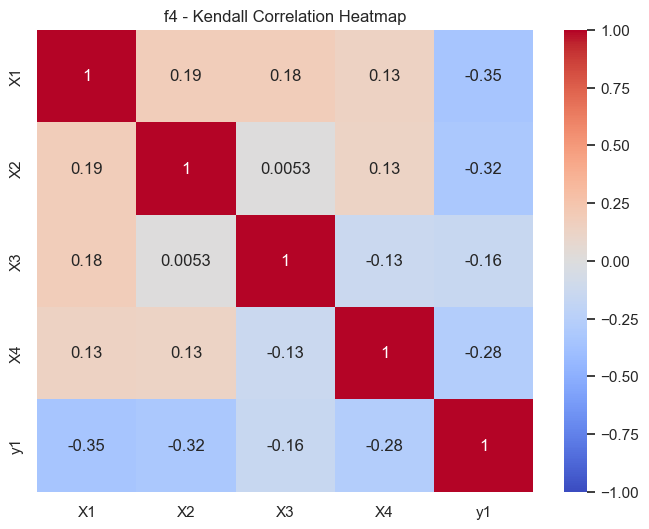


=== f5 — Kendall Correlation ===


,X1,X2,X3,X4,y1
X1,1.000000,-0.094203,0.007246,0.115942,0.000000
X2,-0.094203,1.000000,0.159420,0.065217,0.253623
X3,0.007246,0.159420,1.000000,-0.094203,0.398551
X4,0.115942,0.065217,-0.094203,1.000000,0.289855
y1,0.000000,0.253623,0.398551,0.289855,1.000000


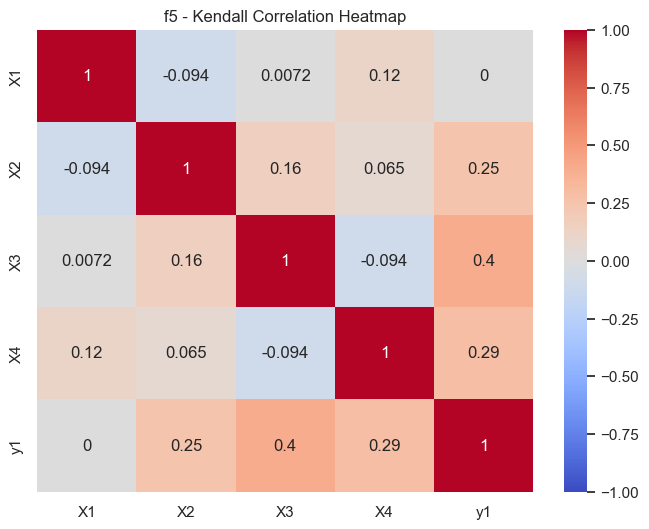


=== f6 — Kendall Correlation ===


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.094203,-0.028986,0.108696,-0.268116,-0.036232
X2,-0.094203,1.000000,0.065217,-0.101449,0.159420,-0.275362
X3,-0.028986,0.065217,1.000000,0.152174,-0.079710,0.181159
X4,0.108696,-0.101449,0.152174,1.000000,-0.304348,0.449275
X5,-0.268116,0.159420,-0.079710,-0.304348,1.000000,-0.434783
y1,-0.036232,-0.275362,0.181159,0.449275,-0.434783,1.000000


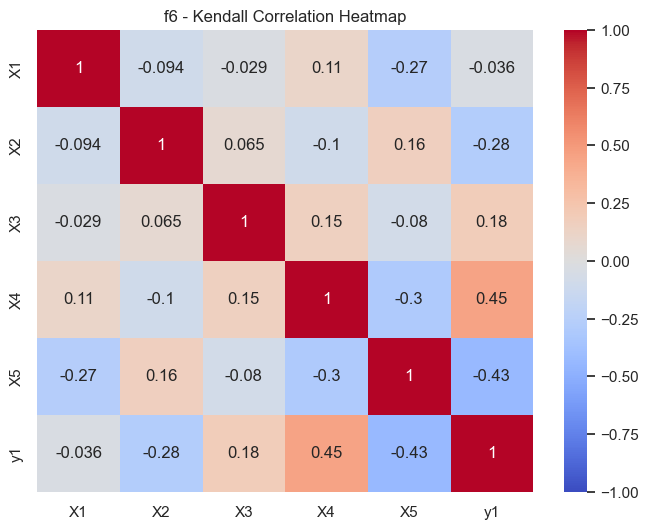


=== f7 — Kendall Correlation ===


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.030303,-0.037433,-0.030303,-0.040998,-0.283422,-0.340463
X2,0.030303,1.000000,0.026738,0.119430,0.237077,0.051693,-0.119430
X3,-0.037433,0.026738,1.000000,0.065954,-0.180036,0.076649,0.155080
X4,-0.030303,0.119430,0.065954,1.000000,0.048128,0.019608,-0.108734
X5,-0.040998,0.237077,-0.180036,0.048128,1.000000,0.058824,-0.283422
X6,-0.283422,0.051693,0.076649,0.019608,0.058824,1.000000,0.187166
y1,-0.340463,-0.119430,0.155080,-0.108734,-0.283422,0.187166,1.000000


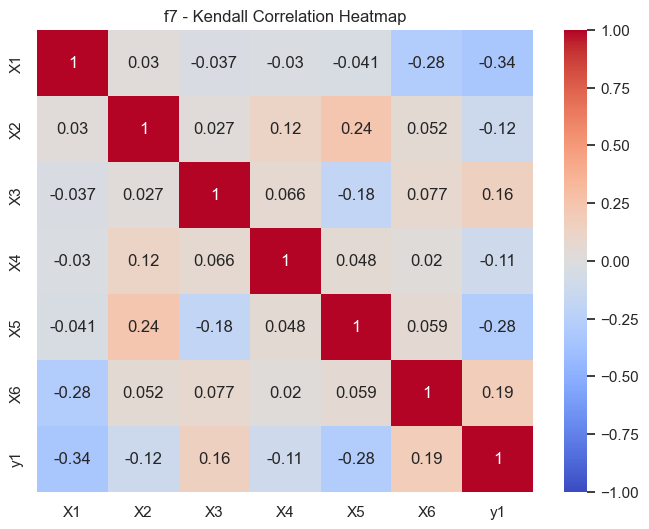


=== f8 — Kendall Correlation ===


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.127353,0.012182,0.087486,0.162791,0.089701,0.111849,0.071982,-0.450720
X2,0.127353,1.000000,0.078627,-0.125138,0.034330,-0.034330,-0.083056,-0.162791,-0.162791
X3,0.012182,0.078627,1.000000,0.074197,-0.045404,-0.118494,-0.052049,-0.025471,-0.450720
X4,0.087486,-0.125138,0.074197,1.000000,-0.054264,-0.065338,-0.007752,0.253599,-0.122924
X5,0.162791,0.034330,-0.045404,-0.054264,1.000000,0.089701,0.107420,0.032115,-0.025471
X6,0.089701,-0.034330,-0.118494,-0.065338,0.089701,1.000000,0.012182,0.060908,-0.001107
X7,0.111849,-0.083056,-0.052049,-0.007752,0.107420,0.012182,1.000000,-0.089701,-0.280177
X8,0.071982,-0.162791,-0.025471,0.253599,0.032115,0.060908,-0.089701,1.000000,0.043189
y1,-0.450720,-0.162791,-0.450720,-0.122924,-0.025471,-0.001107,-0.280177,0.043189,1.000000


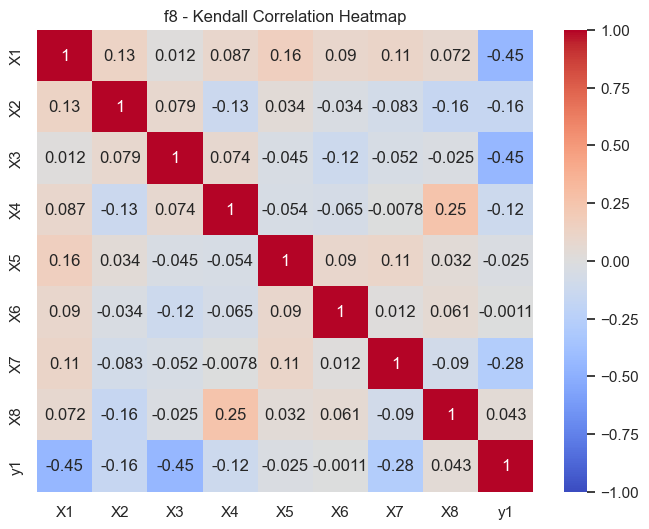

In [13]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Kendall Correlation ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    kendall_corr = df[input_cols + output_cols].corr(method='kendall')
    display(kendall_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()


In [14]:
from sklearn.feature_selection import mutual_info_regression

for name, df in functions_data.items():
    print(f"\n{name} — Mutual Information with Output")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values

    mi = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': input_cols, 'Mutual_Info': mi}).sort_values(by='Mutual_Info', ascending=False)
    display(mi_df)



f1 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0.02381
1,X2,0.00000



f2 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0.473161
1,X2,0.000000



f3 — Mutual Information with Output


...

,Feature,Mutual_Info
4,X5,0.216299
3,X4,0.140919
0,X1,0.000000
1,X2,0.000000
2,X3,0.000000



f7 — Mutual Information with Output


,Feature,Mutual_Info
4,X5,0.136604
5,X6,0.115426
0,X1,0.083727
1,X2,0.007878
2,X3,0.000000
3,X4,0.000000



f8 — Mutual Information with Output


,Feature,Mutual_Info
2,X3,0.314956
0,X1,0.283513
6,X7,0.113041
1,X2,0.000000
3,X4,0.000000
4,X5,0.000000
5,X6,0.000000
7,X8,0.000000


#### Partial Correlation

In [15]:
!pip install pingouin
import pingouin as pg

for name, df in functions_data.items():
    print(f"\n=== {name} — Partial Correlation ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    for x in input_cols:
        pcorr = pg.partial_corr(data=df, x=x, y=output_cols[0], covar=[c for c in input_cols if c != x])
        print(pcorr)



=== f1 — Partial Correlation ===
          n        r          CI95%     p-val
pearson  14 -0.02473  [-0.57, 0.53]  0.936084
          n         r          CI95%     p-val
pearson  14 -0.159792  [-0.65, 0.43]  0.602047

=== f2 — Partial Correlation ===
          n        r          CI95%     p-val
pearson  14  0.41217  [-0.18, 0.78]  0.161659
          n         r          CI95%     p-val
pearson  14  0.127686  [-0.46, 0.63]  0.677631

=== f3 — Partial Correlation ===
          n         r          CI95%     p-val
pearson  19  0.076166  [-0.42, 0.54]  0.771402
          n         r          CI95%     p-val
pearson  19 -0.016236  [-0.49, 0.47]  0.950683
          n         r          CI95%     p-val
pearson  19 -0.452222  [-0.77, 0.04]  0.068375

=== f4 — Partial Correlation ===
          n         r           CI95%    p-val
pearson  34 -0.376244  [-0.64, -0.03]  0.03697
          n         r           CI95%     p-val
pearson  34 -0.368141  [-0.64, -0.02]  0.041582
          n        r

#### Feature vs Output Plots 


Feature vs Output Plots for f1
X shape for f1: (14, 2)
y shape for f1: (14,)


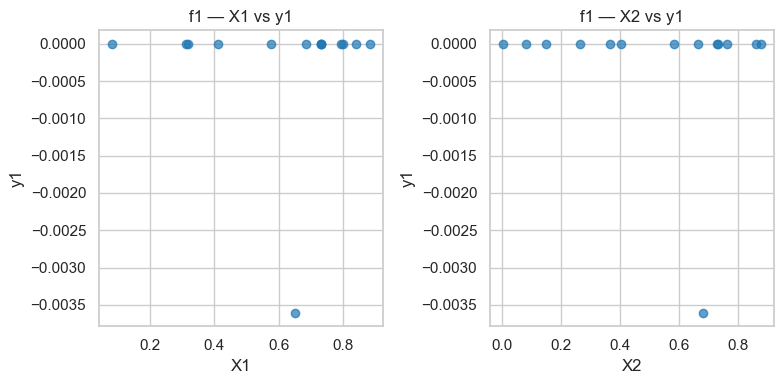


Feature vs Output Plots for f2
X shape for f2: (14, 2)
y shape for f2: (14,)


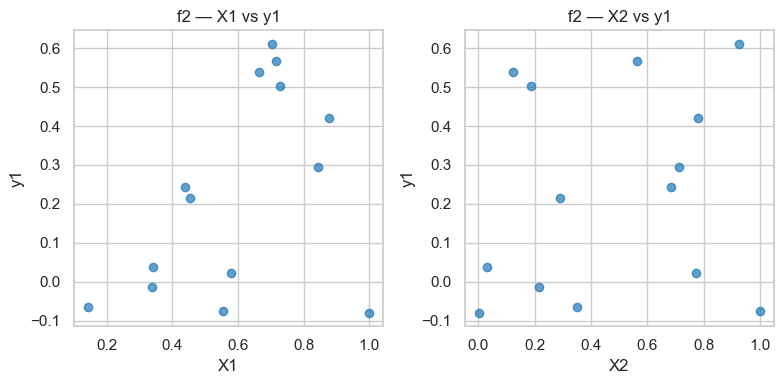


Feature vs Output Plots for f3
X shape for f3: (19, 3)
y shape for f3: (19,)


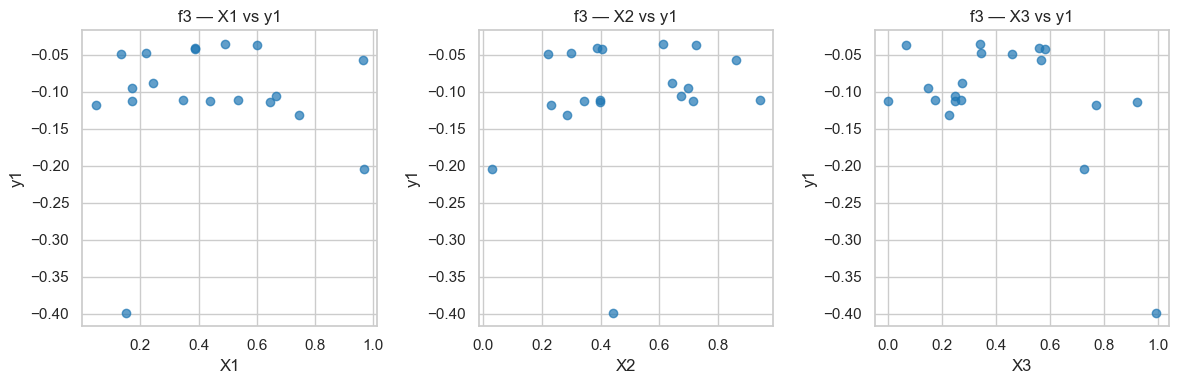


Feature vs Output Plots for f4
X shape for f4: (34, 4)
y shape for f4: (34,)


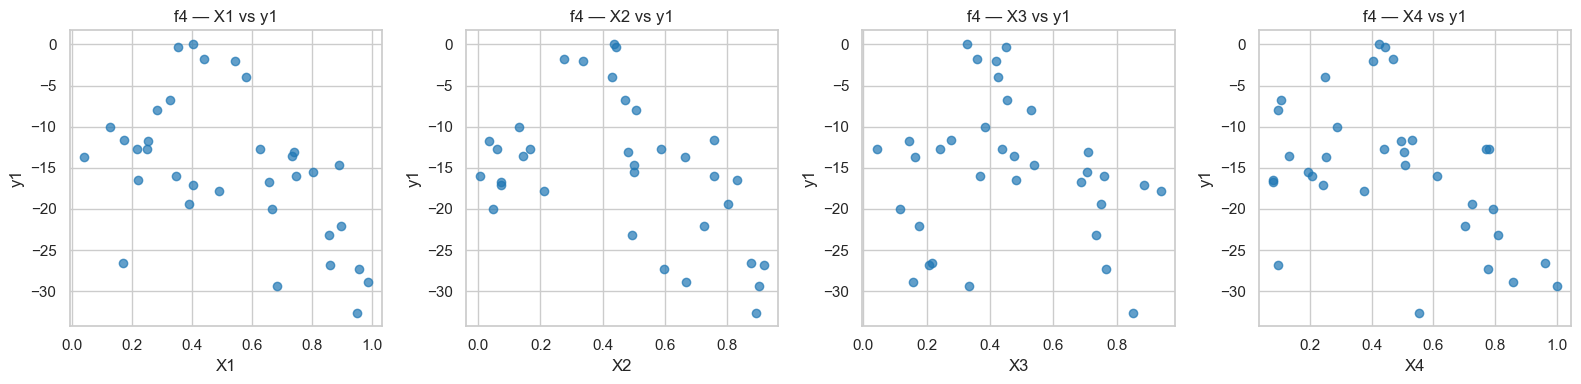


Feature vs Output Plots for f5
X shape for f5: (24, 4)
y shape for f5: (24,)


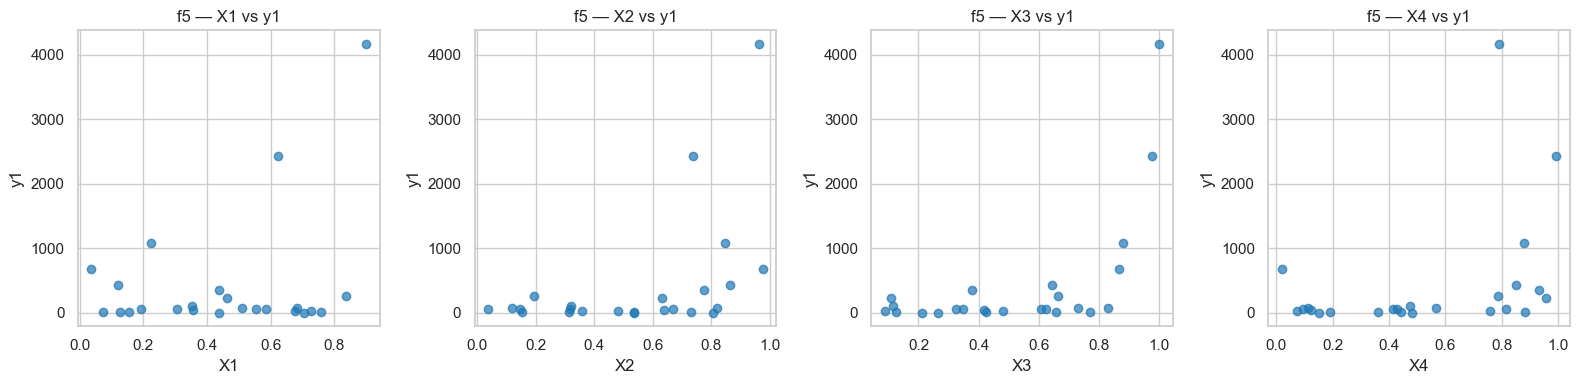


Feature vs Output Plots for f6
X shape for f6: (24, 5)
y shape for f6: (24,)


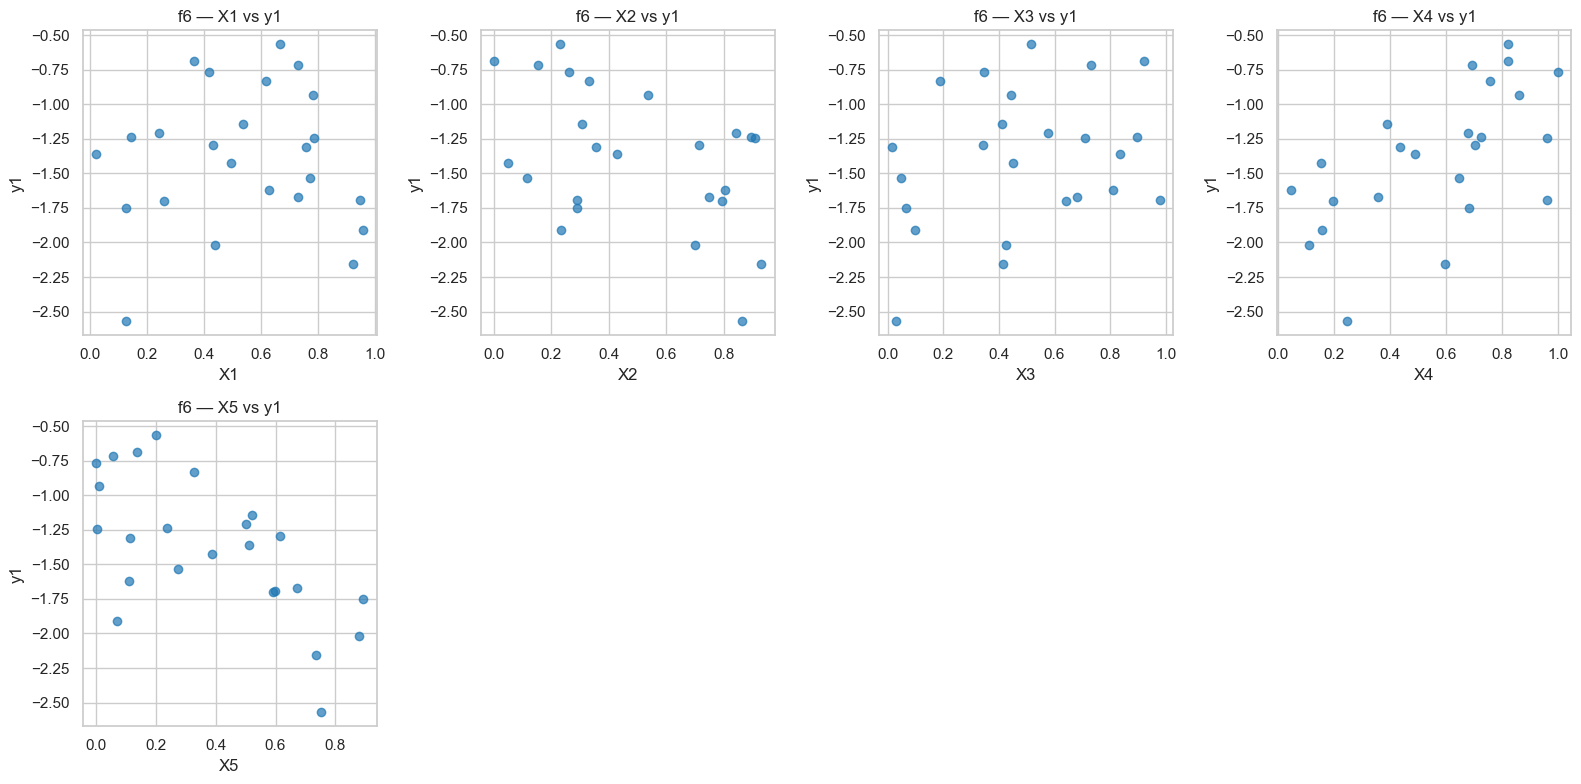


Feature vs Output Plots for f7
X shape for f7: (34, 6)
y shape for f7: (34,)


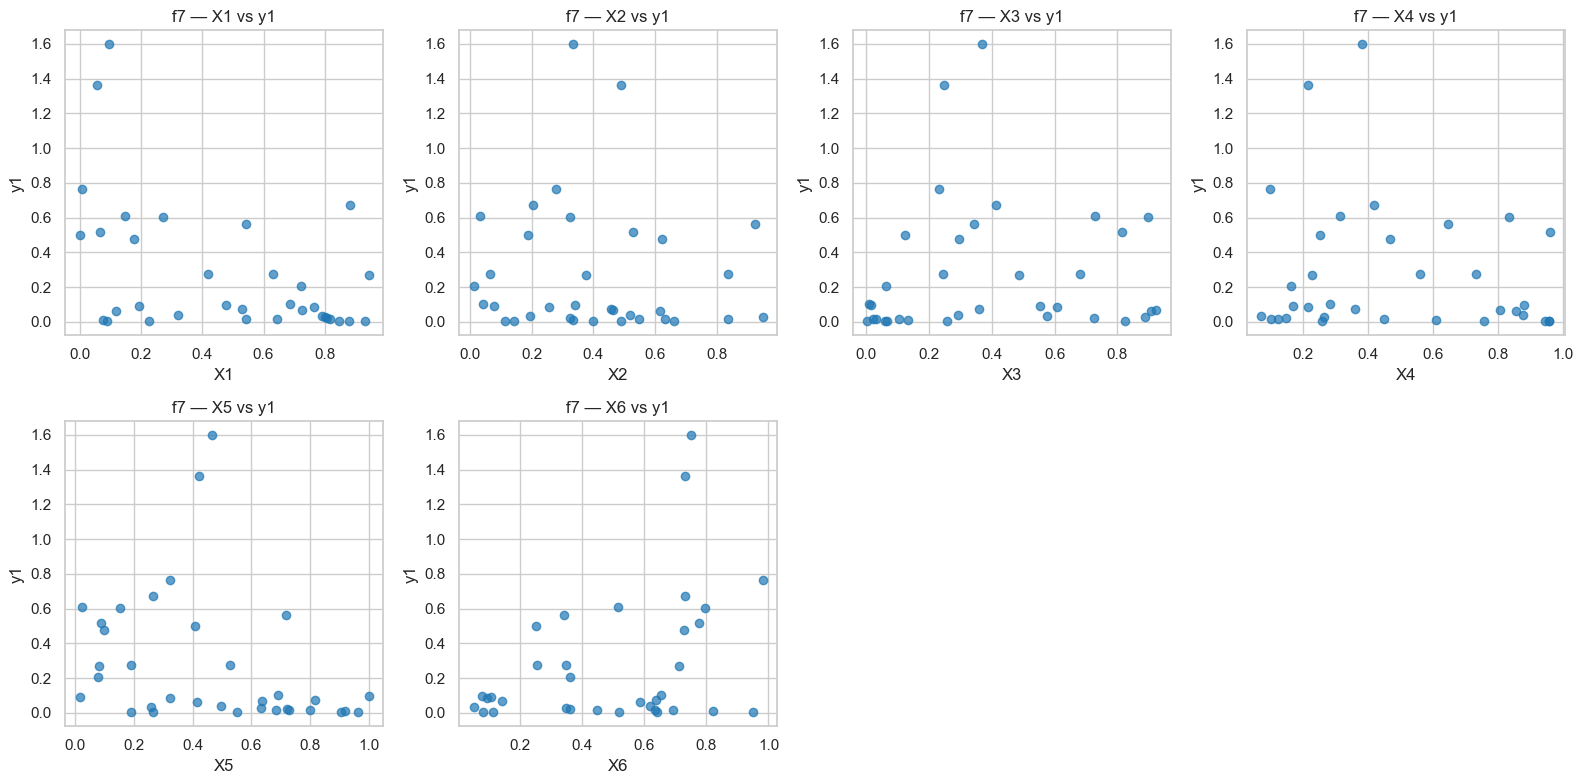


Feature vs Output Plots for f8
X shape for f8: (43, 8)
y shape for f8: (43,)


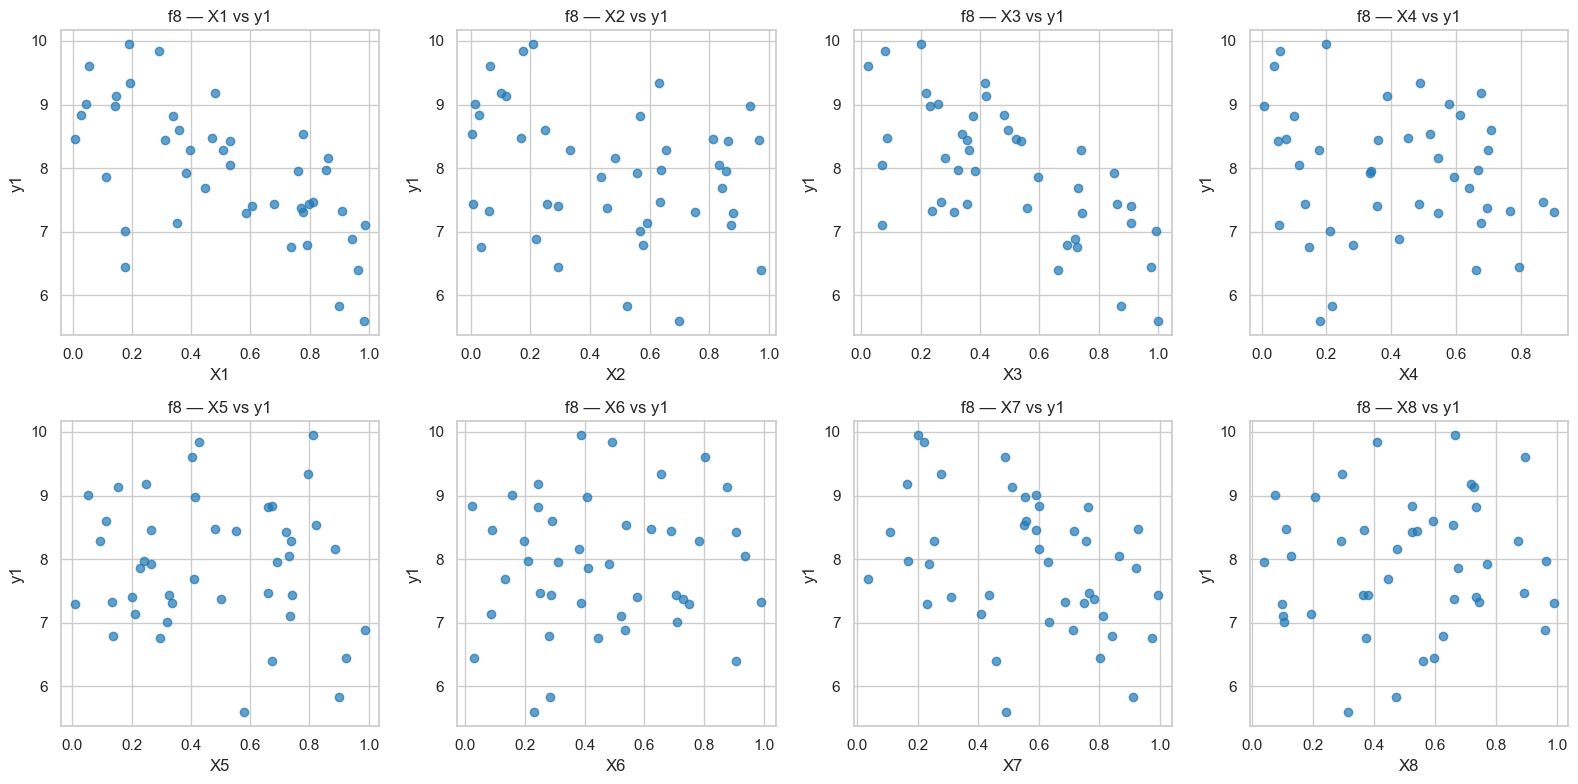

In [16]:
for name, df in functions_data.items():

    print(f"\nFeature vs Output Plots for {name}")


    # Extract input/output columns
    input_cols = [col for col in df.columns if col.startswith("X")]
    output_cols = [col for col in df.columns if col.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values  # use first output column for coloring/plot

    # Sanity checks
    print(f"X shape for {name}: {X.shape}")
    print(f"y shape for {name}: {y.shape}")

    assert X.shape[0] == y.shape[0], f"Mismatch in samples for {name}!"
    expected_features = len(input_cols)
    assert X.shape[1] == expected_features, f"Unexpected feature count in {name}!"


    # Plot each feature vs y
    n_features = X.shape[1]

    # Determine grid size (2 rows, dynamic columns)
    n_cols = min(4, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.ravel() if n_features > 1 else [axes]

    for i in range(n_features):
        ax = axes[i]
        ax.scatter(X[:, i], y, color='tab:blue', alpha=0.7)
        ax.set_xlabel(input_cols[i])
        ax.set_ylabel(output_cols[0])
        ax.set_title(f"{name} — {input_cols[i]} vs {output_cols[0]}")

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()



=== f1 — Feature & Output Distributions ===


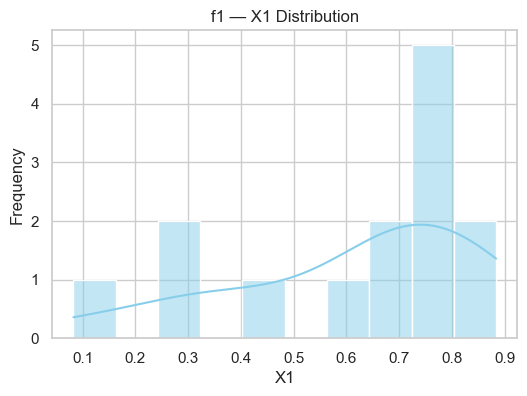

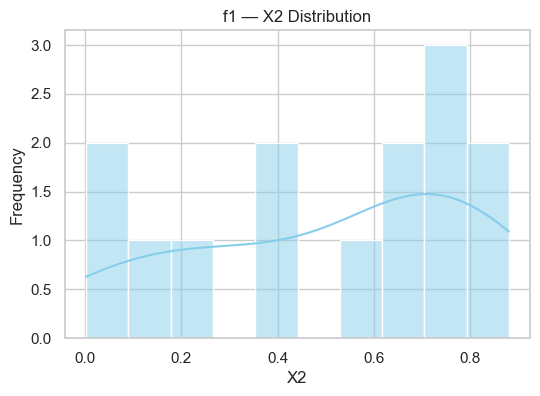

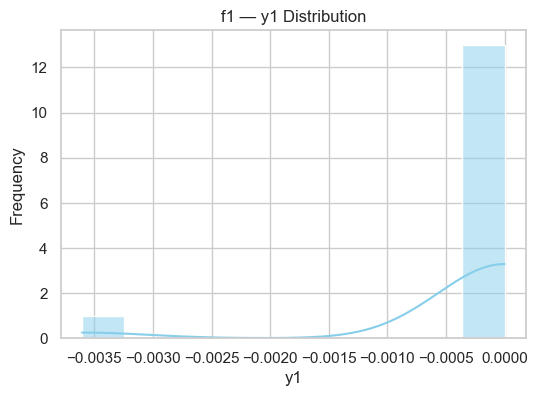


=== f2 — Feature & Output Distributions ===


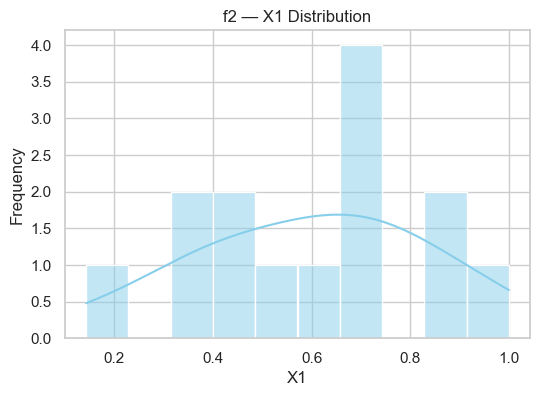

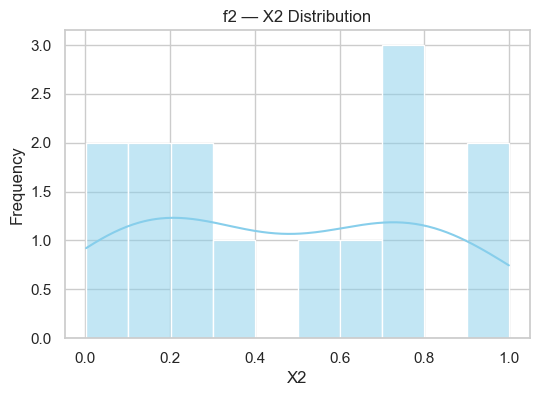

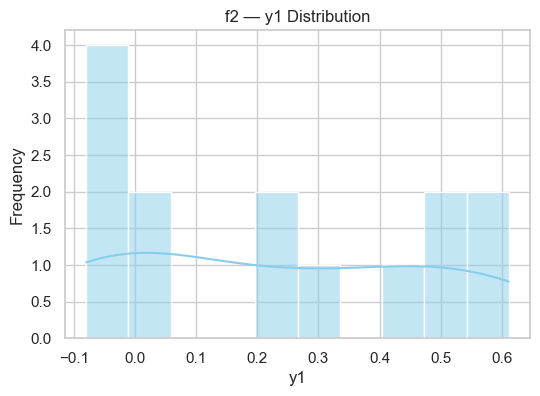


=== f3 — Feature & Output Distributions ===


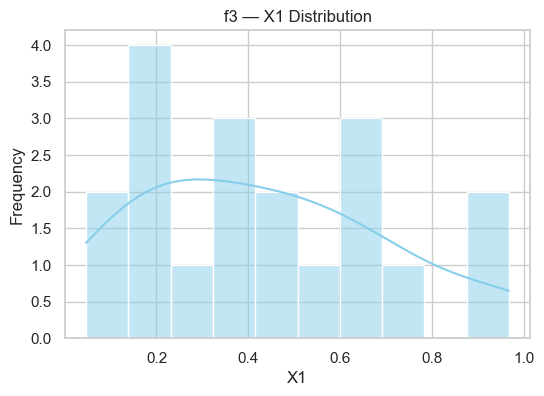

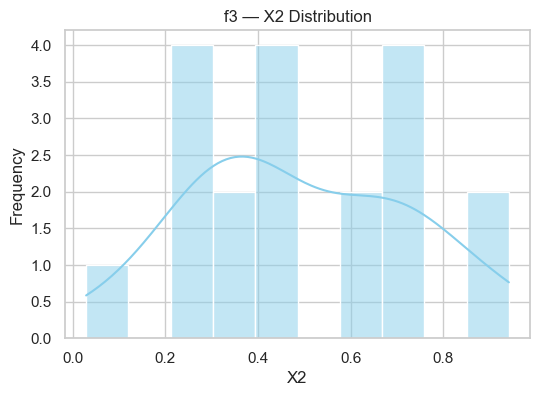

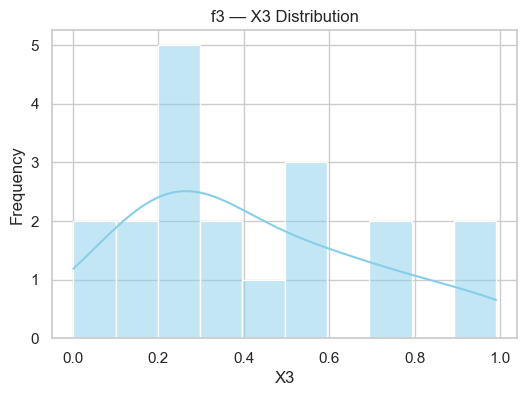

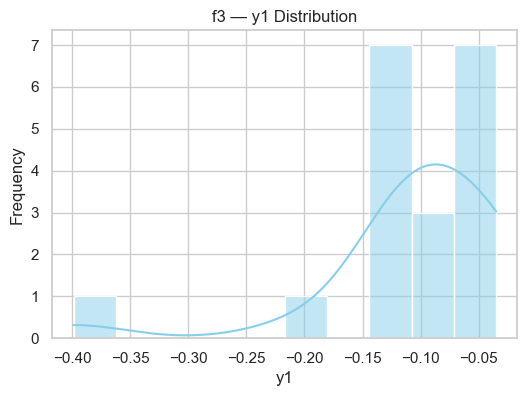


=== f4 — Feature & Output Distributions ===


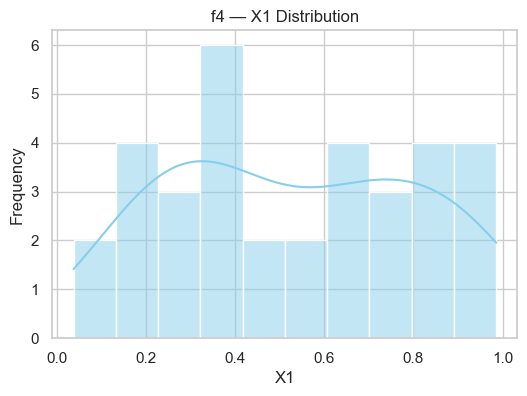

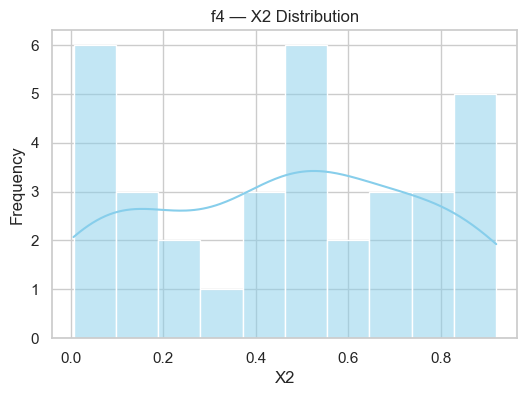

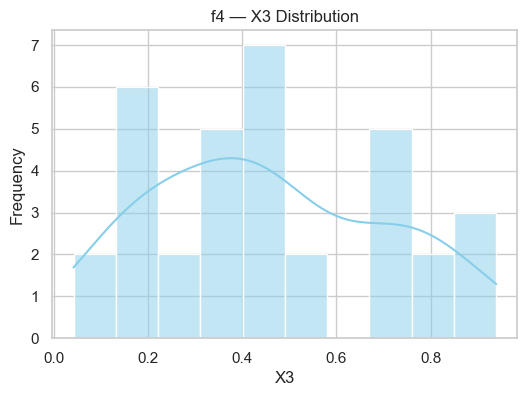

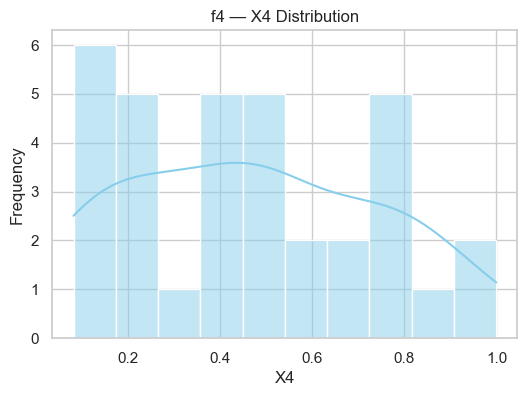

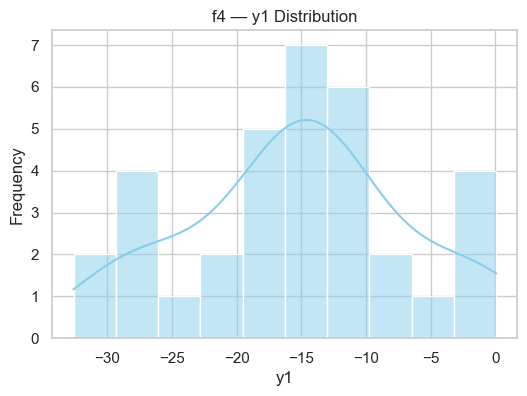


=== f5 — Feature & Output Distributions ===


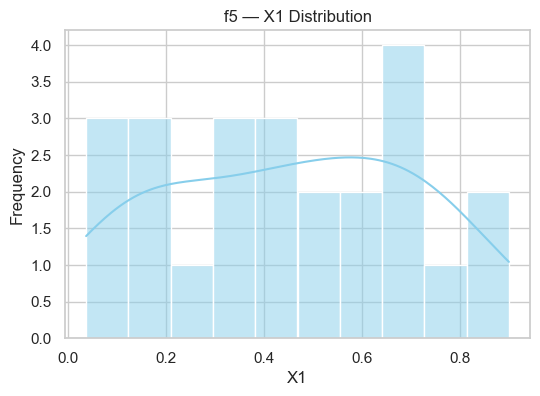

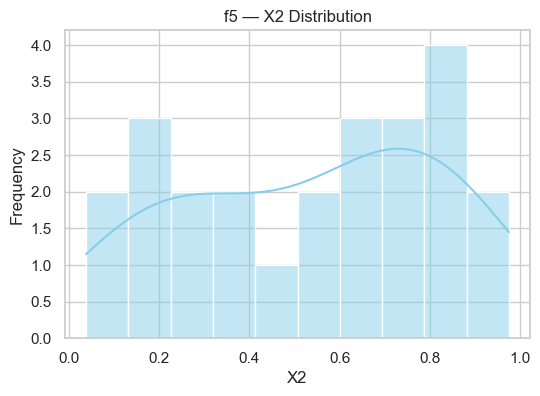

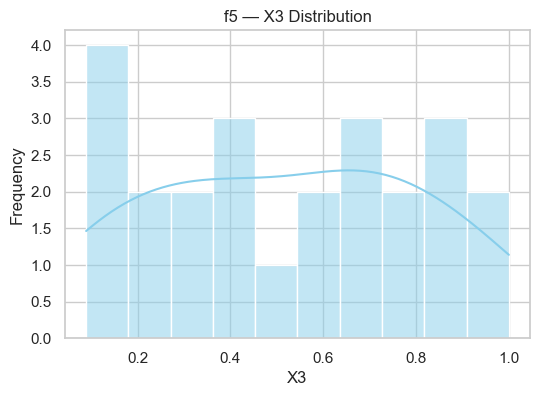

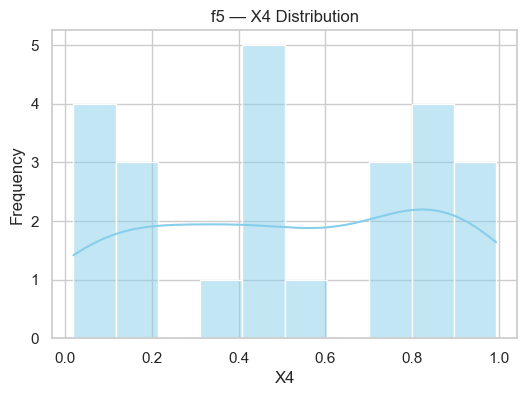

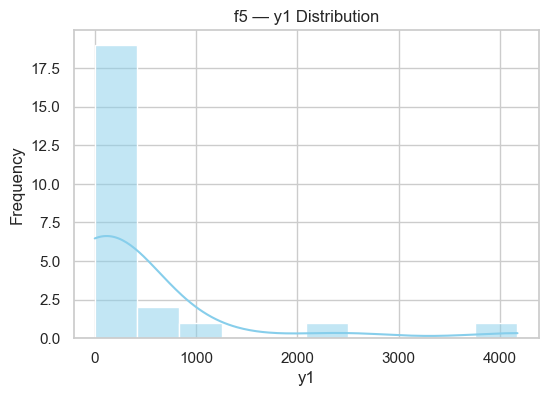


=== f6 — Feature & Output Distributions ===


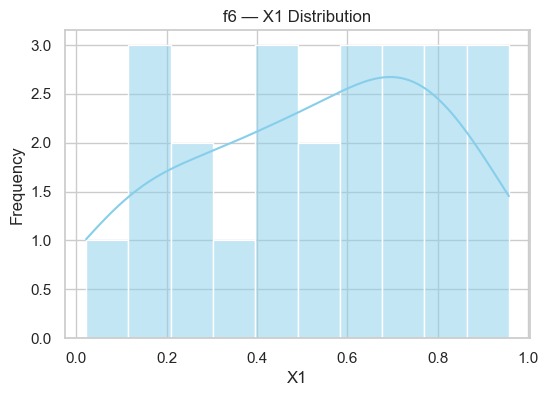

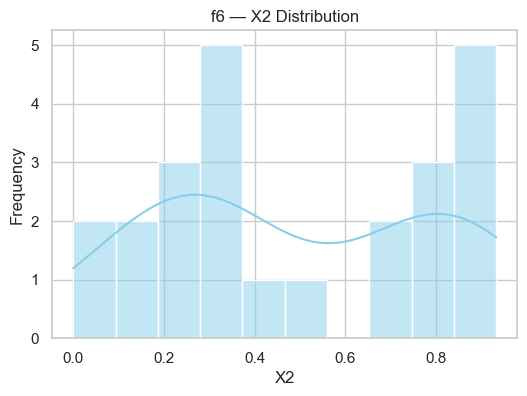

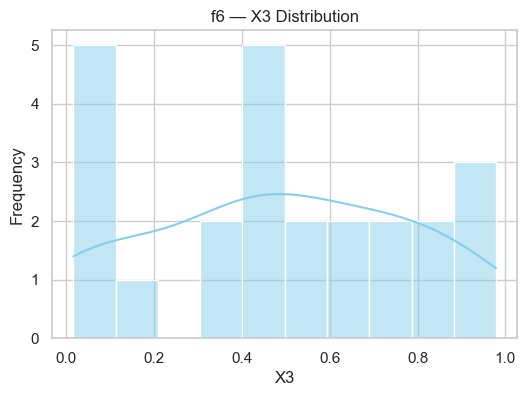

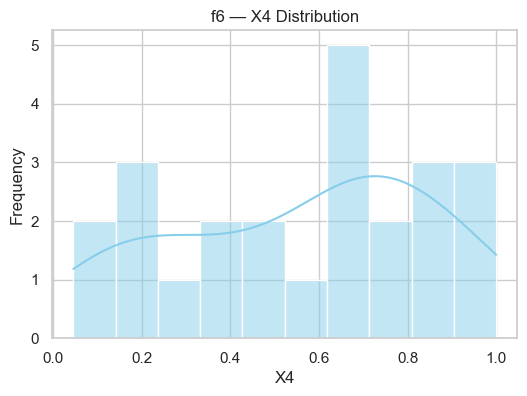

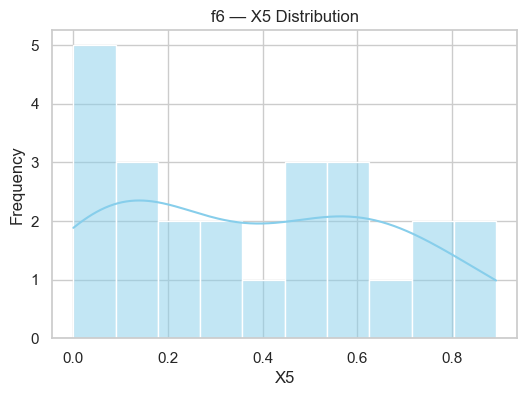

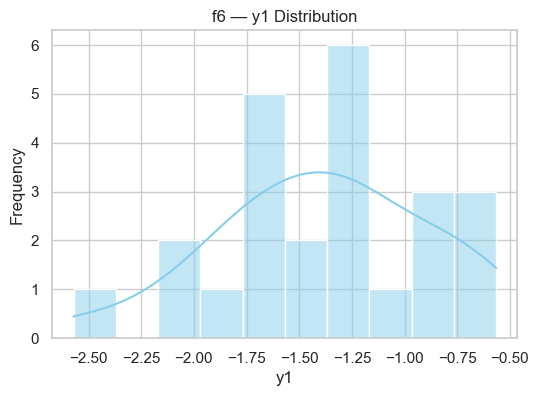


=== f7 — Feature & Output Distributions ===


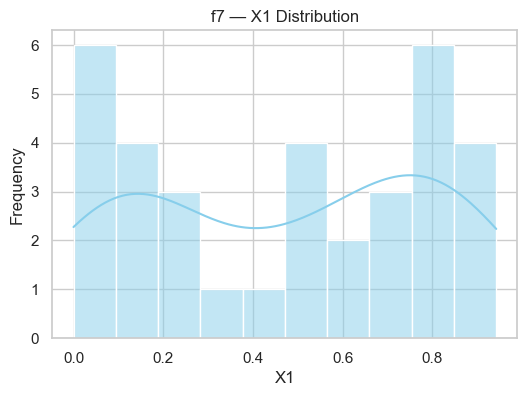

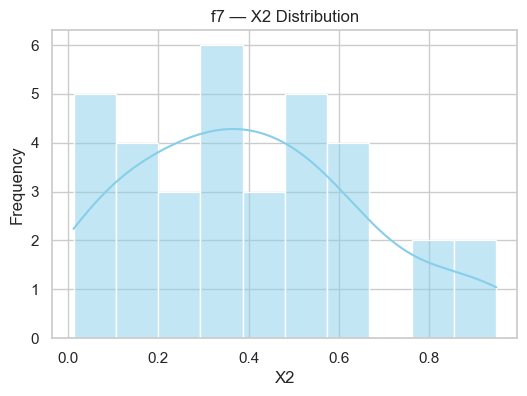

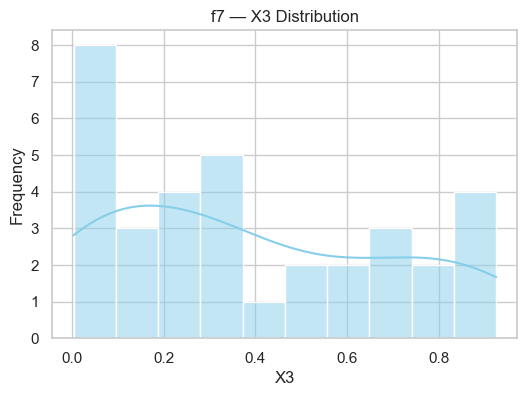

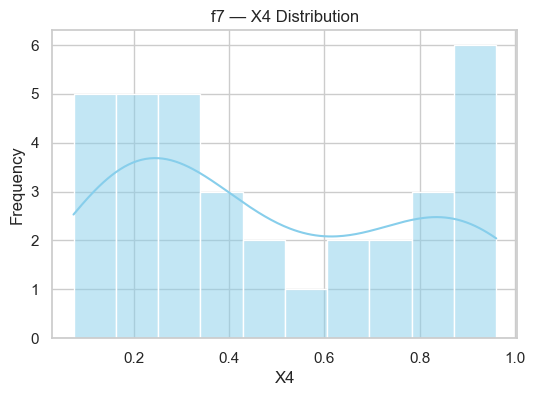

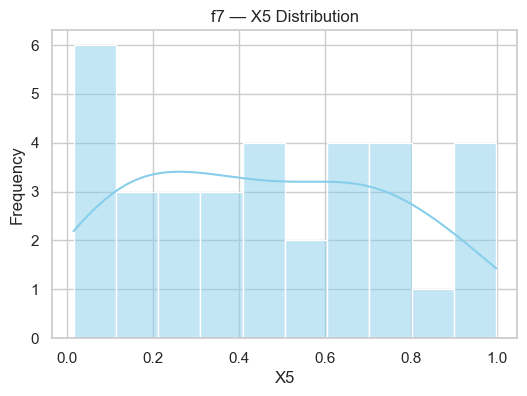

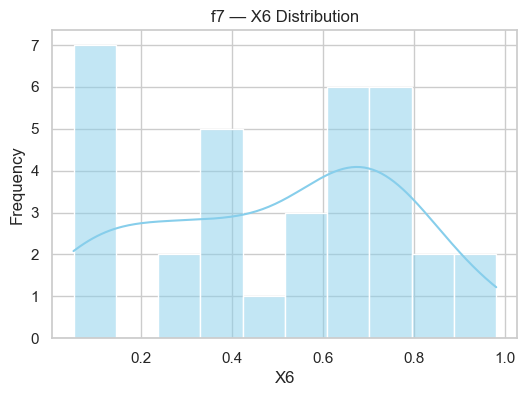

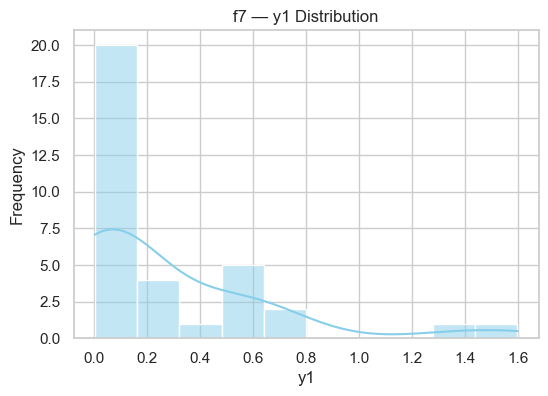


=== f8 — Feature & Output Distributions ===


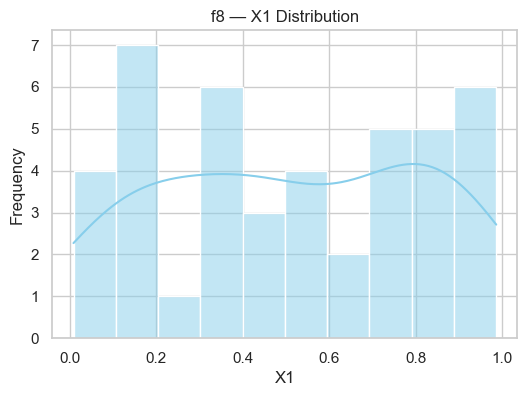

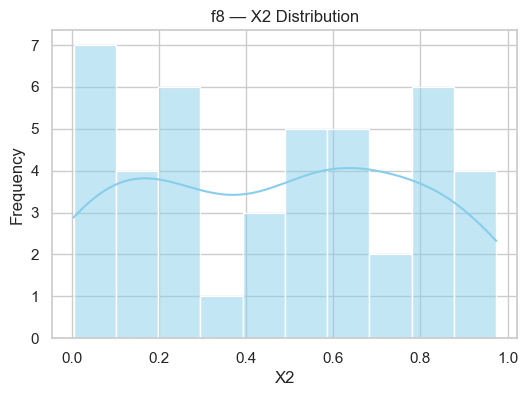

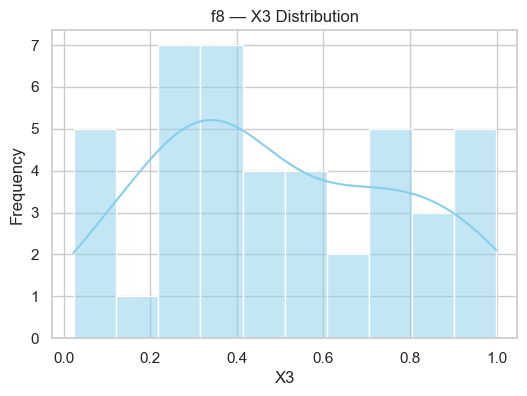

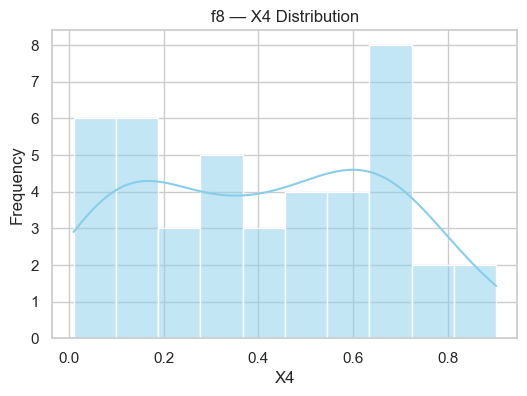

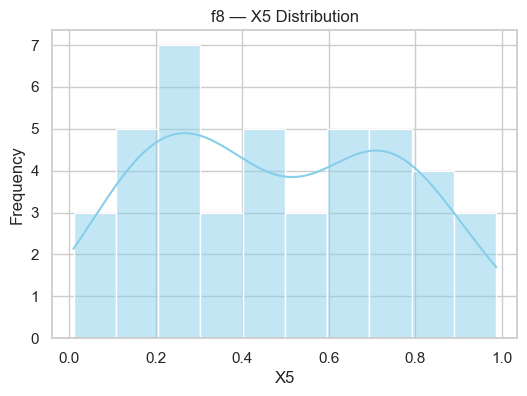

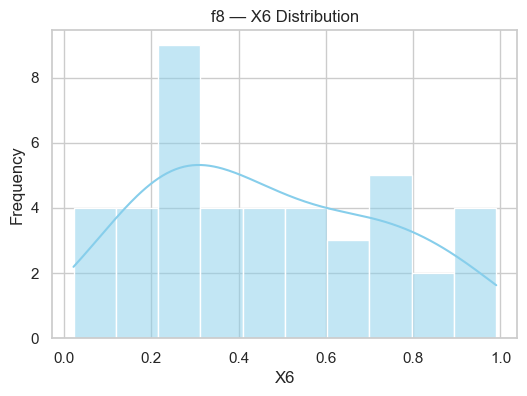

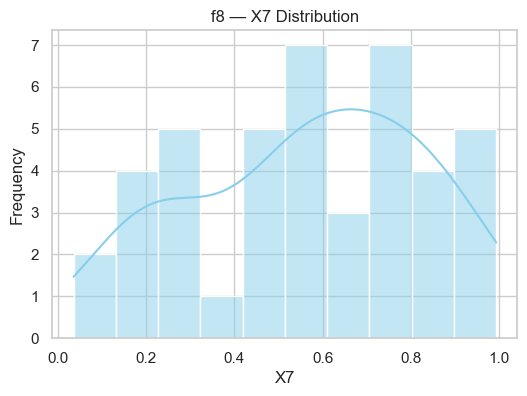

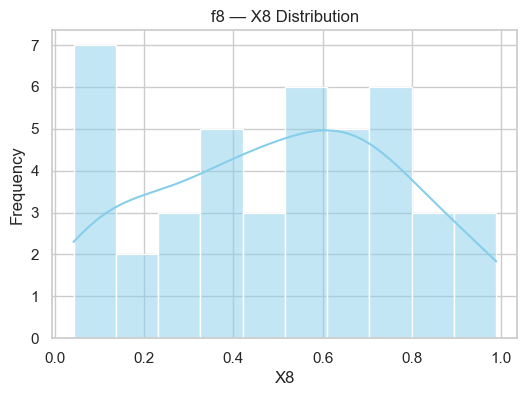

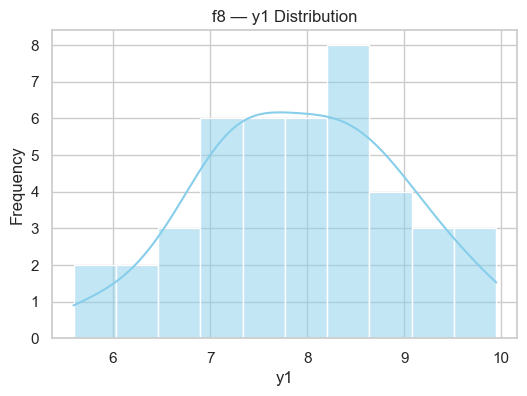

In [17]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Feature & Output Distributions ===")
    
    # Identify input and output columns
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    all_cols = input_cols + output_cols
    
    for col in all_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=10, color='skyblue')
        plt.title(f"{name} — {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


#### Line Plot of y Values


f1 — Full Data Table
          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57

f1 — y vs Instance Plot


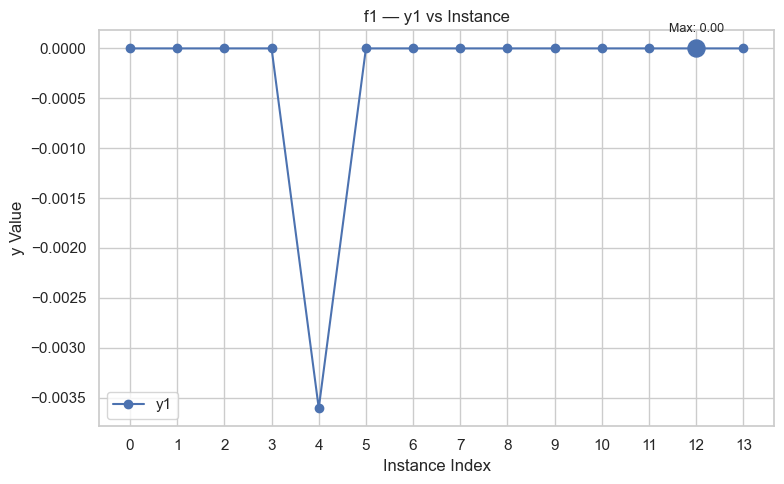


f2 — Full Data Table
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
12  0.727681  0.187140  0.503703
13  0.715483  0.563901  0.566166

f2 — y vs Instance Plot


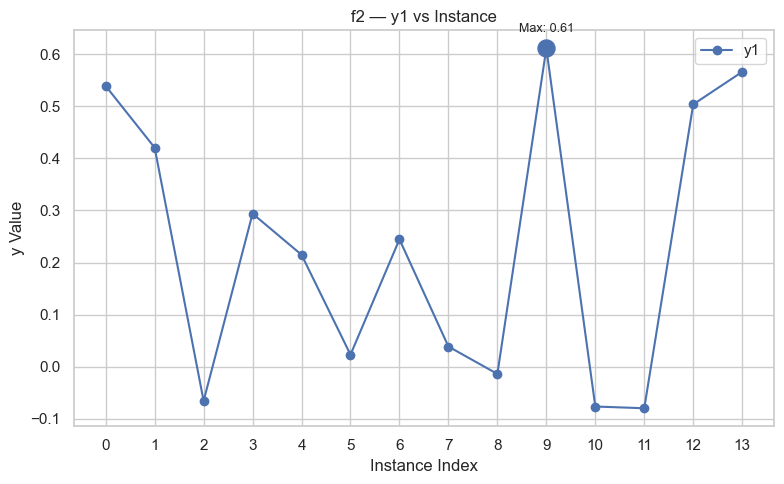


f3 — Full Data Table
          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.389233  0.386084  0.558916 -0.041168
16  0.967200  0.029200  0.723300 -0.204966
17  0.437962  0.715305  0.000876 -0.111768
18  0.387933  0.405240  0.580181 -0.041279

f3 — y vs Instance Plot


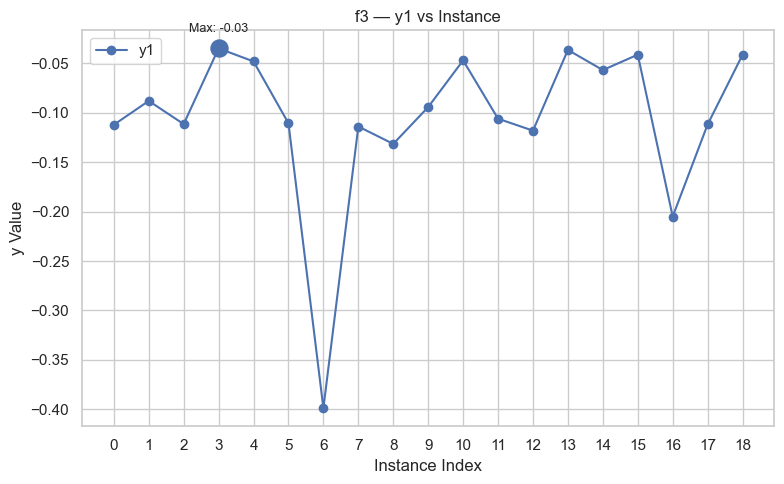


f4 — Full Data Table
          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.

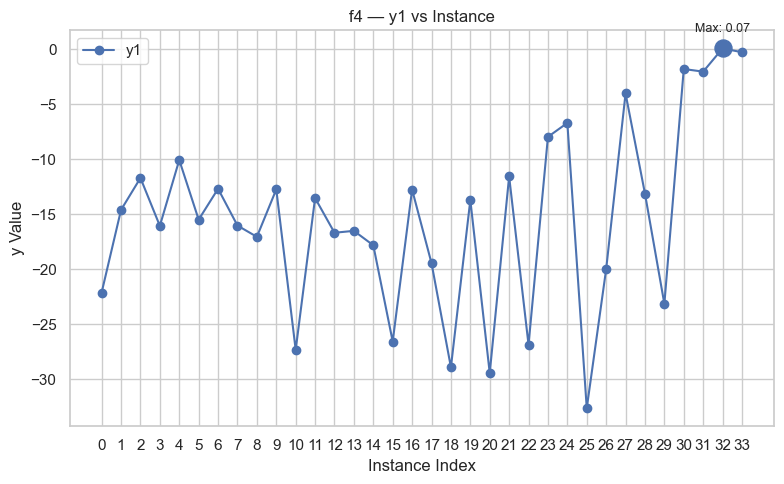


f5 — Full Data Table
          X1        X2        X3        X4           y1
0   0.191447  0.038193  0.607418  0.414584    64.443440
1   0.758653  0.536518  0.656000  0.360342    18.301380
2   0.438350  0.804340  0.210245  0.151295     0.112940
3   0.706051  0.534192  0.264243  0.482088     4.210898
4   0.836478  0.193610  0.663893  0.785649   258.370525
5   0.683432  0.118663  0.829046  0.567577    78.434389
6   0.553621  0.667350  0.323806  0.814870    57.571537
7   0.352356  0.322242  0.116979  0.473113   109.571876
8   0.153786  0.729382  0.422598  0.443074     8.847992
9   0.463442  0.630025  0.107906  0.957644   233.223610
10  0.677491  0.358510  0.479592  0.072880    24.423088
11  0.583973  0.147243  0.348097  0.428615    64.420147
12  0.306889  0.316878  0.622634  0.095399    63.476716
13  0.511142  0.817957  0.728710  0.112354    79.729130
14  0.438933  0.774092  0.378167  0.933696   355.806818
15  0.224189  0.846480  0.879484  0.878516  1088.859618
16  0.725262  0.479870  0.

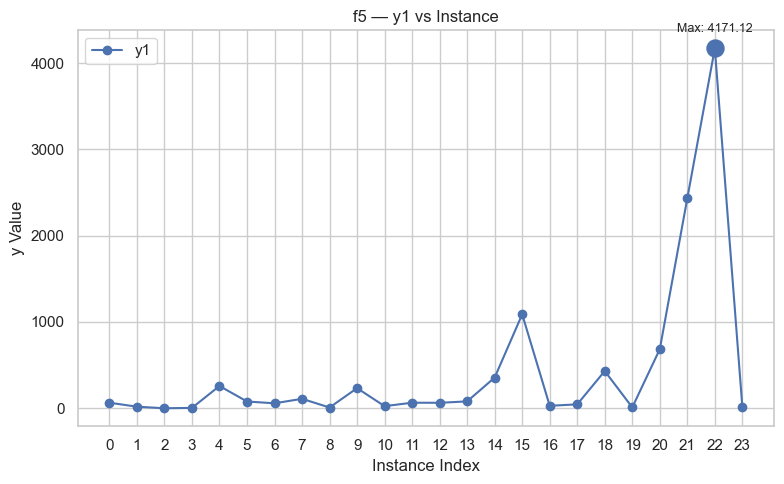


f6 — Full Data Table
          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820 

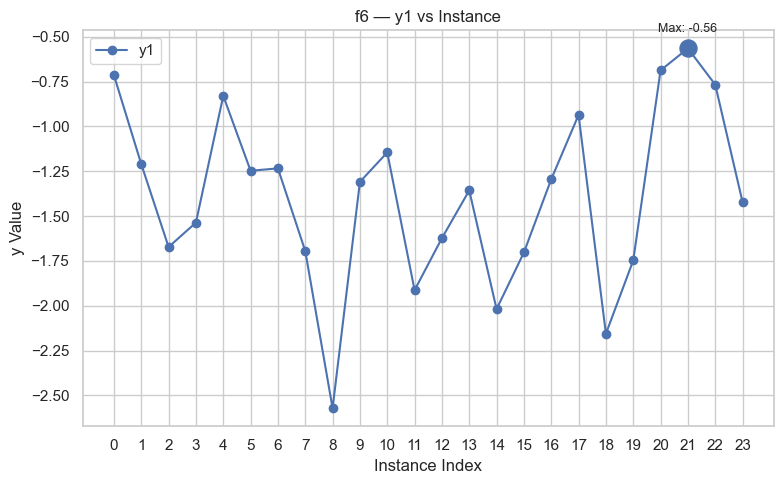


f7 — Full Data Table
          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.334502  0.132

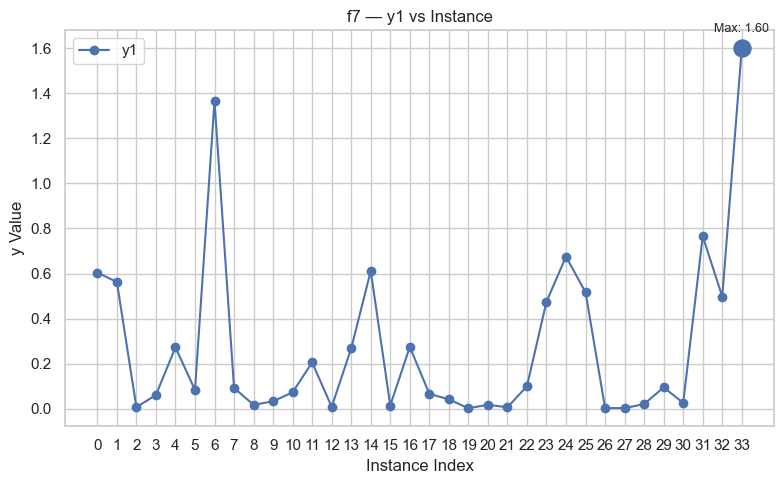


f8 — Full Data Table
          X1        X2        X3        X4        X5        X6        X7        X8        y1
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311  0.734281  7.398721
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384  0.107132  7.005227
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415  0.367320  8.459482
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827  0.292472  8.284008
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295  0.593882  8.606117
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347  0.660032  8.541748
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068  0.742496  7.327435
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907  0.097916  7.299872
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380  0.041956  7.957875
9   0.984933  0.699506  0.998885  0.180148  0.58

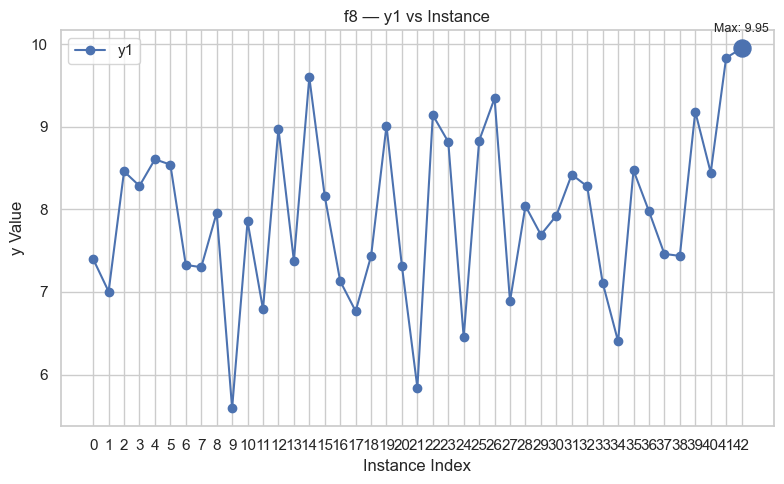

In [18]:
# Dictionary to store week labels for each DataFrame
week_labels_dict = {}
# Dictionary to track the next week number to assign
next_week_counter = {}

for name, df in functions_data.items():
    print(f"\n{name} — Full Data Table")
    print(df.to_string())
    print(f"\n{name} — y vs Instance Plot")
    
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    
    for col in output_cols:
        plt.figure(figsize=(8, 5))
        x = df.index
        y = df[col]
        plt.plot(x, y, marker='o', label=col)
        
        # Highlight maximum y
        max_idx = y.idxmax()
        max_val = y.max()
        plt.scatter(max_idx, max_val, s=150, zorder=5)
        plt.annotate(
            f"Max: {max_val:.2f}",
            (max_idx, max_val),
            textcoords="offset points",
            xytext=(0, 12),
            ha='center',
            fontsize=9
        )
        
        
        plt.xticks(x)
        plt.title(f"{name} — {col} vs Instance")
        plt.xlabel("Instance Index")
        plt.ylabel("y Value")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



#### f1 | GP with low L & B + UCB + Sobol Sequence for candidate Selection

In [19]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats.qmc import Sobol

In [20]:
# Extract existing data for Function 1
df = functions_data["f1"]

# Separate inputs (X) and outputs (y)
X_train_1 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_1 = df["y1"].values
print(X_train_1)
print(y_train_1)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.7936     0.666269  ]
 [0.800601   0.0028    ]
 [0.729726   0.729276  ]
 [0.732162   0.364472  ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.40349865e-021  9.06910879e-223
  5.31459276e-015  5.47377612e-057]


In [21]:
# this function proposes the next query point for f1
# it also returns the gp mean prediction at that point
# all comments are in lowercase for clarity

def propose_f1_query(X_train_1, y_train_1):
    # step 1: build a gaussian process model
    # the rbf kernel is a common choice for smooth functions
    # the constant kernel scales the output
    kernel = C(1.0) * RBF(length_scale=0.2)

    # create the gp model
    gp = GPR(
        kernel=kernel,
        alpha=1e-8,          # small noise term for numerical stability
        normalize_y=True     # normalise targets for better training
    )

    # fit the gp to all observations
    gp.fit(X_train_1, y_train_1)

    # step 2: generate sobol candidates in the 2d unit square
    # sobol sequences cover the space more evenly than random points
    sampler = Sobol(d=2, scramble=True)
    candidates = sampler.random_base2(m=8)   # 2 to the power of 8 equals 256 points

    # step 3: filter out points that are too close to existing data
    # this prevents wasting a query on a location we have already explored
    def min_distance(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    filtered = np.array([x for x in candidates if min_distance(x, X_train_1) > 0.10])

    # if filtering removes too many points, fall back to all candidates
    if len(filtered) == 0:
        filtered = candidates

    # step 4: compute gp ucb for each candidate
    # ucb equals mean plus beta times standard deviation
    # beta is small because the function has no structure
    beta = 0.3
    means, stds = gp.predict(filtered, return_std=True)
    ucb_values = means + beta * stds

    # step 5: select the candidate with the highest ucb value
    next_index = np.argmax(ucb_values)
    next_x = filtered[next_index]

    # step 6: compute the gp mean at the selected point
    # this is useful for logging and diagnostics
    gp_mean_at_next = gp.predict(next_x.reshape(1, -1))[0]

    # return both the next query point and the gp mean prediction
    return next_x, gp_mean_at_next, gp


next_query, gp_mean, gp = propose_f1_query(X_train_1, y_train_1)


print("next query for f1:", next_query)
print("gp mean at this point:", gp_mean)

next query for f1: [0.06596645 0.82948182]
gp mean at this point: -0.00025757590316838504


#### f2 | GP + yeo johnson input warping + high beta ucb

In [22]:
# Extract existing data for Function 2
df = functions_data["f2"]

# Separate inputs (X) and outputs (y)
X_train_2 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_2 = df["y1"].values
print(X_train_2)
print(y_train_2)

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.554975   0.999446  ]
 [0.9995     0.0018    ]
 [0.727681   0.18714   ]
 [0.715483   0.563901  ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522 -0.07640834 -0.07975546
  0.50370322  0.56616625]


In [23]:
from sklearn.preprocessing import PowerTransformer
from sklearn.gaussian_process.kernels import Matern

In [24]:
# this function proposes the next query point for f2
# it applies a yeo johnson warp to x1
# it fits a gaussian process with a matern kernel
# it uses a high beta ucb rule to encourage exploration in the high x1 region

def propose_f2_query(X_train_2, y_train_2):
    # step 1: apply yeo johnson transform to x1 only
    # this corrects non stationary monotonic behaviour
    pt = PowerTransformer(method="yeo-johnson")
    x1_warped = pt.fit_transform(X_train_2[:, 0].reshape(-1, 1)).flatten()

    # rebuild the transformed input matrix
    X_warped_2 = np.column_stack([x1_warped, X_train_2[:, 1]])

    # step 2: build the gaussian process model
    # the matern five over two kernel is flexible and smooth
    kernel = C(1.0) * Matern(length_scale=[0.2, 0.2], nu=2.5)

    gp = GPR(
        kernel=kernel,
        alpha=1e-6,          # small noise for stability
        normalize_y=True     # normalise outputs for better training
    )

    # fit the gp to the warped inputs
    gp.fit(X_warped_2, y_train_2)

    # step 3: generate sobol candidates in the two dimensional unit square
    sampler = Sobol(d=2, scramble=True)
    candidates = sampler.random_base2(m=10)   # 2 to the power of 10 equals 1024 points

    # step 4: apply directional bias toward x1 greater than zero point seven five
    # keep seventy percent of candidates from the high x1 region
    high_x1 = candidates[candidates[:, 0] > 0.75]
    low_x1 = candidates[candidates[:, 0] <= 0.75]

    if len(high_x1) > 0:
        num_high = int(0.7 * len(candidates))
        num_low = len(candidates) - num_high
        biased_candidates = np.vstack([
            high_x1[:num_high],
            low_x1[:num_low]
        ])
    else:
        biased_candidates = candidates

    # step 5: filter out points too close to existing data
    def min_distance(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    filtered = np.array([x for x in biased_candidates if min_distance(x, X_train_2) > 0.05])

    if len(filtered) == 0:
        filtered = biased_candidates

    # step 6: warp x1 for all candidate points
    x1_cand_warped = pt.transform(filtered[:, 0].reshape(-1, 1)).flatten()
    X_cand_warped = np.column_stack([x1_cand_warped, filtered[:, 1]])

    # step 7: compute gp ucb with high beta
    beta = 2.0
    means, stds = gp.predict(X_cand_warped, return_std=True)
    ucb_values = means + beta * stds

    # step 8: select the candidate with the highest ucb value
    best_index = np.argmax(ucb_values)
    next_x = filtered[best_index]

    # step 9: compute gp mean at the selected point for logging
    gp_mean_at_next = means[best_index]

    return next_x, gp_mean_at_next, pt, gp


next_query, gp_mean, pt, gp = propose_f2_query(X_train_2, y_train_2)
print("next query for f2:", next_query)
print("gp mean at this point:", gp_mean)


next query for f2: [0.66448374 0.983655  ]
gp mean at this point: 0.5561636044094407


#### f3 | Box Cox warped GP with min Neural Network Residual Correction and KNN ensemble Acquisition

In [25]:
# Extract existing data for Function 2
df = functions_data["f3"]

# Separate inputs (X) and outputs (y)
X_train_3 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_3 = df["y1"].values
print(X_train_3)
print(y_train_3)

[[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [3.89233000e-01 3.86084000e-01 5.58916000e-01]
 [9.67200000e-01 2.92000000e-02 7.23300000e-01]
 [4.37962000e-01 7.15305000e-01 8.76000000e-04]
 [3.87933000e-01 4.05240000e-01 5.80181000e-01]]
[-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -

In [26]:
from sklearn.neighbors import KNeighborsRegressor as KNN
import torch 
import torch.nn as nn 
import torch.optim as optim
from scipy.stats import norm


In [27]:
# this function proposes the next query point for f3 
# it applies a box cox warp to the outputs 
# it fits a gaussian process on the warped outputs 
# it trains a small mlp to correct gp residuals

def propose_f3_query(X_train_3, y_train_3):
    # step 1 shift y to positive values for box cox
    y_shift = y_train_3 - np.min(y_train_3) + 0.01

    # step 2 apply box cox transform
    pt = PowerTransformer(method="box-cox")
    y_bc = pt.fit_transform(y_shift.reshape(-1, 1)).flatten()

    # step 3 build the gaussian process model
    kernel = C(1.0) * Matern(length_scale=[0.3, 0.3, 0.3], nu=2.5)

    gp = GPR(
        kernel=kernel,
        alpha=1e-6,
        normalize_y=True
    )

    gp.fit(X_train_3, y_bc)

    # step 4 compute gp predictions on training points
    y_gp_bc = gp.predict(X_train_3)
    y_gp = pt.inverse_transform(y_gp_bc.reshape(-1, 1)).flatten()

    # step 5 compute residuals on original scale
    residuals = y_train_3 - y_gp

    # step 6 build a tiny mlp for residual correction
    class SmallMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(3, 4)
            self.relu = nn.ReLU()
            self.fc2 = nn.Linear(4, 1)

        def forward(self, x):
            x = self.fc1(x)
            x = self.relu(x)
            x = self.fc2(x)
            return x

    mlp = SmallMLP()

    X_t = torch.tensor(X_train_3, dtype=torch.float32)
    r_t = torch.tensor(residuals.reshape(-1, 1), dtype=torch.float32)

    optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_loss = float("inf")
    patience = 20
    wait = 0

    for epoch in range(500):
        mlp.train()
        optimizer.zero_grad()
        pred = mlp(X_t)
        loss = loss_fn(pred, r_t)
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            wait = 0
        else:
            wait += 1

        if wait > patience:
            break

    # step 8 build knn model for ensemble mean
    knn = KNN(n_neighbors=3)
    knn.fit(X_train_3, y_train_3)

    # step 9 generate sobol candidates
    sampler = Sobol(d=3, scramble=True)
    candidates = sampler.random_base2(m=10)

    # step 10 bias candidates toward low x3 region
    low_x3 = candidates[candidates[:, 2] < 0.5]
    high_x3 = candidates[candidates[:, 2] >= 0.5]

    if len(low_x3) > 0:
        num_low = int(0.5 * len(candidates))
        num_high = len(candidates) - num_low
        biased = np.vstack([low_x3[:num_low], high_x3[:num_high]])
    else:
        biased = candidates

    # step 11 filter out points too close to existing data
    def min_distance(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    filtered = np.array([x for x in biased if min_distance(x, X_train_3) > 0.07])
    if len(filtered) == 0:
        filtered = biased

    # step 12 compute ensemble mean for each candidate
    X_cand = filtered
    y_knn = knn.predict(X_cand)

    y_gp_bc_cand = gp.predict(X_cand)
    y_gp_cand = pt.inverse_transform(y_gp_bc_cand.reshape(-1, 1)).flatten()

    X_cand_t = torch.tensor(X_cand, dtype=torch.float32)
    y_mlp_res = mlp(X_cand_t).detach().numpy().flatten()

    y_ens = 0.50 * y_knn + 0.35 * y_gp_cand + 0.15 * (y_gp_cand + y_mlp_res)

    # step 12b clean any non finite values in ensemble mean
    bad = ~np.isfinite(y_ens)
    if np.any(bad):
        y_ens[bad] = y_gp_cand[bad]

    # step 13 compute gp std for uncertainty
    _, stds = gp.predict(X_cand, return_std=True)
    stds = np.maximum(stds, 1e-9)

    # step 14 compute expected improvement using numpy
    best_y = np.max(y_train_3)
    z = (y_ens - best_y) / stds
    ei = (y_ens - best_y) * norm.cdf(z) + stds * norm.pdf(z)

    # replace nan ei with zero
    ei[~np.isfinite(ei)] = 0.0

    # step 15 select best candidate
    best_index = np.argmax(ei)
    next_x = X_cand[best_index]
    next_mean = y_ens[best_index]
    
    # debug prints to understand why next_mean is nan
    print("debug next x:", next_x)
    print("debug y knn:", y_knn[best_index])
    print("debug y gp cand:", y_gp_cand[best_index])
    print("debug y mlp residual:", y_mlp_res[best_index])
    print("debug ensemble mean:", y_ens[best_index])
    print("debug gp std:", stds[best_index])
    print("debug ei value:", ei[best_index])

    return next_x, next_mean, gp, pt, knn, mlp

next_query, predicted_mean, gp, pt, knn, mlp = propose_f3_query(X_train_3, y_train_3)

print("next query for f3:", next_query)
print("mean at this point:", predicted_mean)


debug next x: [0.79136392 0.96034548 0.67164845]
debug y knn: -0.06585290687987895
debug y gp cand: 0.2903778311908232
debug y mlp residual: -0.48074
debug ensemble mean: 0.0401514605447162
debug gp std: 0.9549407480192088
debug ei value: 0.4196335774280912
next query for f3: [0.79136392 0.96034548 0.67164845]
mean at this point: 0.0401514605447162


#### f4 | Dual‑GP + MLP Ensemble BO with SVM Filtering and TuRBO‑TS

In [28]:
# Extract existing data for Function 2
df = functions_data["f4"]

# Separate inputs (X) and outputs (y)
X_train_4 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_4 = df["y1"].values
print(X_train_4)
print(y_train_4)

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import WhiteKernel
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

In [30]:
# this function proposes the next query point for f4
# it uses three models together
# 1 heteroscedastic gp for calibrated uncertainty
# 2 ucb style gp for directional signal
# 3 small mlp for local mean correction
# it also uses svm boundary filtering, turbo trust region, directional bias,
# variance inflation, expected improvement and thompson sampling

def propose_f4_query(X_train_4, y_train_4):
    d = X_train_4.shape[1]

    # step 1 standardise inputs and outputs
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_std = x_scaler.fit_transform(X_train_4)
    y_std = y_scaler.fit_transform(y_train_4.reshape(-1, 1)).flatten()

    # step 2 svm boundary detection from week 4
    threshold = np.percentile(y_train_4, 60)
    y_class = (y_train_4 > threshold).astype(int)

    svm_clf = SVC(
        kernel="rbf",
        C=5,
        probability=True
    )

    _ = cross_val_score(
        svm_clf, X_train_4, y_class,
        cv=5,
        scoring="accuracy"
    ).mean()

    svm_clf.fit(X_train_4, y_class)

    # step 3 heteroscedastic gp
    het_kernel = C(1.0) * Matern(length_scale=[0.5] * d, nu=2.5) + WhiteKernel(noise_level=0.1)

    het_gp = GPR(
        kernel=het_kernel,
        alpha=1e-6,
        normalize_y=True
    )

    het_gp.fit(X_std, y_std)

    # step 4 ucb style gp
    ucb_kernel = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(d),
        length_scale_bounds=(1e-2, 1e2),
        nu=2.5
    )

    ucb_gp = GPR(
        kernel=ucb_kernel,
        alpha=1e-6,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=42
    )

    ucb_gp.fit(X_std, y_std)

    # step 5 small mlp for mean correction
    class SmallMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(d, 6)
            self.relu = nn.ReLU()
            self.drop = nn.Dropout(p=0.2)
            self.fc2 = nn.Linear(6, 1)

        def forward(self, x):
            x = self.fc1(x)
            x = self.relu(x)
            x = self.drop(x)
            x = self.fc2(x)
            return x

    mlp = SmallMLP()

    X_t = torch.tensor(X_std, dtype=torch.float32)
    y_t = torch.tensor(y_std.reshape(-1, 1), dtype=torch.float32)

    optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_loss = float("inf")
    patience = 20
    wait = 0

    for epoch in range(500):
        mlp.train()
        optimizer.zero_grad()
        pred = mlp(X_t)
        loss = loss_fn(pred, y_t)
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            wait = 0
        else:
            wait += 1

        if wait > patience:
            break

    # step 6 find current best point
    best_index = np.argmax(y_train_4)
    x_best = X_train_4[best_index]
    y_best = y_train_4[best_index]

    # step 7 turbo trust region
    radius = 0.40
    lower = np.maximum(x_best - radius, 0.0)
    upper = np.minimum(x_best + radius, 1.0)

    # step 8 sobol candidates
    sampler = Sobol(d=d, scramble=True)
    raw = sampler.random_base2(m=10)
    candidates = lower + raw * (upper - lower)

    # step 9 directional bias toward region of x_best
    aligned = []
    for c in candidates:
        score = 0
        if c[0] <= x_best[0]:
            score += 1
        if c[1] <= x_best[1]:
            score += 1
        if c[3] <= x_best[3]:
            score += 1
        if score >= 2:
            aligned.append(c)

    aligned = np.array(aligned)

    if len(aligned) > 0:
        num_aligned = int(0.6 * len(candidates))
        num_other = len(candidates) - num_aligned
        biased = np.vstack([aligned[:num_aligned], candidates[:num_other]])
    else:
        biased = candidates

    # step 10 minimum distance filter
    def min_distance(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    filtered = np.array([x for x in biased if min_distance(x, X_train_4) > 0.05])
    if len(filtered) == 0:
        filtered = biased

    # step 11 svm mask on candidates
    proba = svm_clf.predict_proba(filtered)[:, 1]
    mask_safe = proba > 0.5
    filtered_safe = filtered[mask_safe]
    if len(filtered_safe) > 0:
        filtered = filtered_safe

    # step 12 predictions from all three models
    X_cand_std = x_scaler.transform(filtered)

    het_mean_std, het_std = het_gp.predict(X_cand_std, return_std=True)
    ucb_mean_std, _ = ucb_gp.predict(X_cand_std, return_std=True)

    X_cand_t = torch.tensor(X_cand_std, dtype=torch.float32)
    mlp_mean_std = mlp(X_cand_t).detach().numpy().flatten()

    # step 13 ensemble mean in standardised space
    mu_ens_std = 0.55 * het_mean_std + 0.25 * ucb_mean_std + 0.20 * mlp_mean_std

    # step 14 convert ensemble mean to original scale
    mu_ens = y_scaler.inverse_transform(mu_ens_std.reshape(-1, 1)).flatten()

    # step 15 variance inflation on heteroscedastic gp std
    y_std_scale = y_scaler.scale_[0]
    sigma_raw = het_std * y_std_scale
    inflation = np.sqrt(3.0)
    sigma = inflation * sigma_raw
    sigma = np.maximum(sigma, 1e-9)

    # step 16 expected improvement with inflated sigma
    z = (mu_ens - y_best) / sigma
    ei = (mu_ens - y_best) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[~np.isfinite(ei)] = 0.0

    # step 17 thompson sampling with inflated std
    het_sample_std = het_mean_std + inflation * het_std * np.random.randn(len(het_mean_std))
    het_sample = y_scaler.inverse_transform(het_sample_std.reshape(-1, 1)).flatten()

    ts_score = 0.70 * het_sample + 0.30 * mu_ens

    # step 18 final acquisition score
    final_score = 0.20 * ei + 0.80 * ts_score

    # step 19 select best candidate
    best_cand = np.argmax(final_score)
    next_x = filtered[best_cand]
    next_mean = mu_ens[best_cand]

    return next_x, next_mean, x_scaler, y_scaler, het_gp, ucb_gp, mlp, svm_clf

next_query, predicted_mean, x_scaler, y_scaler, het_gp, ucb_gp, mlp, svm_clf = propose_f4_query(X_train_4, y_train_4)

print("min y:", np.min(y_train_4))
print("max y:", np.max(y_train_4))
print("mean y:", np.mean(y_train_4))
print("next query for f4:", next_query)
print("mean at this point:", predicted_mean)

min y: -32.625660215962455
max y: 0.07045398603133579
mean y: -15.329609216360174
next query for f4: [0.39652587 0.4587539  0.32492352 0.33605475]
mean at this point: -2.8473594926345225


#### f5 | Log transform + x3 warping + minimal MLP + adaptive 3× inflation + seeded candidates + EI Acquisition

In [31]:
# Extract existing data for Function 5
df = functions_data["f5"]

# Separate inputs (X) and outputs (y)
X_train_5 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_5 = df["y1"].values
print(X_train_5)
print(y_train_5)

[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.037069   0.974641   0.864911   0.019169  ]
 [0.624      

In [32]:
# this function proposes the next query point for f5
# it uses week 3 style log transform, x3 warping, minimal neural network,
# adaptive variance inflation, and ei acquisition
# all comments are written in small letters for readability

week3_best_x = y_train_5[np.argmax(y_train_5)]

def propose_f5_query(X_train, y_train, week3_best_x):

    # step 1 compute y_min for week 3 style log transform
    # this allows log transform even if y contains negative values
    y_min = np.min(y_train)

    # step 2 log transform the target using week 3 method
    # this stabilises the scale of the outputs
    eps = 1e-8
    y_log = np.log(y_train - y_min + eps)

    # step 3 warp x3 using yeo johnson transform
    # x3 is the third column (index 2) because f5 is 4 dimensional
    pt = PowerTransformer(method="yeo-johnson")
    X_warp = X_train.copy()
    X_warp[:, 2:3] = pt.fit_transform(X_train[:, 2:3])

    # step 4 standardise inputs and outputs
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_std = x_scaler.fit_transform(X_warp)
    y_std = y_scaler.fit_transform(y_log.reshape(-1, 1)).flatten()

    # step 5 define the log gp with matern 2.5 kernel
    # this was the best model in week 3
    kernel = C(1.0) * Matern(length_scale=np.ones(4), nu=2.5)

    gp = GPR(
        kernel=kernel,
        alpha=1e-6,
        normalize_y=True
    )

    gp.fit(X_std, y_std)

    # step 6 define a minimal neural network
    # this network has 1 hidden layer with 4 units
    # it only helps with the mean estimate
    class SmallMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(4, 4)
            self.relu = nn.ReLU()
            self.fc2 = nn.Linear(4, 1)

        def forward(self, x):
            x = self.fc1(x)
            x = self.relu(x)
            x = self.fc2(x)
            return x

    mlp = SmallMLP()

    # convert data to torch tensors
    X_t = torch.tensor(X_std, dtype=torch.float32)
    y_t = torch.tensor(y_std.reshape(-1, 1), dtype=torch.float32)

    # step 7 train the mlp with early stopping
    optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_loss = float("inf")
    patience = 20
    wait = 0

    for epoch in range(500):
        mlp.train()
        optimizer.zero_grad()
        pred = mlp(X_t)
        loss = loss_fn(pred, y_t)
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            wait = 0
        else:
            wait += 1

        if wait > patience:
            break

    # step 8 generate candidate points
    # half near week 3 best point, half sobol uniform
    n_candidates = 1000
    half = n_candidates // 2

    # candidates near week 3 best point
    local = week3_best_x + 0.15 * np.random.uniform(-1, 1, size=(half, 4))

    # clip to ensure all values stay between 0 and 1
    local = np.clip(local, 0.0, 1.0)

    # sobol candidates are already in [0, 1]
    sampler = Sobol(d=4, scramble=True)
    sobol_raw = sampler.random_base2(m=10)
    sobol = sobol_raw[:half]

    # combine candidates
    X_cand = np.vstack([local, sobol])

    # enforce minimum distance of 0.05 from existing points
    def min_dist(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    filtered = np.array([x for x in X_cand if min_dist(x, X_train) > 0.05])

    # if filtering removes everything, fall back to all candidates
    if len(filtered) == 0:
        filtered = X_cand

    # step 9 apply x3 warping and standardisation to candidates
    X_cand_warp = filtered.copy()
    X_cand_warp[:, 2:3] = pt.transform(filtered[:, 2:3])
    X_cand_std = x_scaler.transform(X_cand_warp)

    # step 10 gp predictions
    gp_mean_std, gp_std = gp.predict(X_cand_std, return_std=True)

    # step 11 mlp predictions
    X_cand_t = torch.tensor(X_cand_std, dtype=torch.float32)
    mlp_mean_std = mlp(X_cand_t).detach().numpy().flatten()

    # step 12 ensemble mean in standardised log space
    mu_ens_std = 0.60 * gp_mean_std + 0.40 * mlp_mean_std

    # convert ensemble mean back to log space
    mu_ens_log = y_scaler.inverse_transform(mu_ens_std.reshape(-1, 1)).flatten()

    # step 13 adaptive variance inflation
    # week 3 z score was about 0.46, so gp is not badly calibrated
    # we use 3 times inflation instead of 5 times
    sigma_log = gp_std * y_scaler.scale_[0]
    sigma_inflated = 3.0 * sigma_log
    sigma_inflated = np.maximum(sigma_inflated, 1e-9)

    # step 14 compute expected improvement in log space
    best_log = np.max(y_log)
    z = (mu_ens_log - best_log) / sigma_inflated
    ei = (mu_ens_log - best_log) * norm.cdf(z) + sigma_inflated * norm.pdf(z)
    ei[~np.isfinite(ei)] = 0.0

    # step 15 choose best candidate
    best_idx = np.argmax(ei)
    next_x = filtered[best_idx]

    # step 16 compute predicted mean in original y space
    next_mean_log = mu_ens_log[best_idx]
    next_mean = np.exp(next_mean_log) + y_min - eps

    return next_x, next_mean, gp, mlp, pt, x_scaler, y_scaler, y_min, y_log

# now call the f5 proposal function
next_x, next_mean, gp, mlp, pt, x_scaler, y_scaler, y_min, y_log = propose_f5_query(X_train_5, y_train_5, week3_best_x)

print("next query for f5:", next_x)
print("predicted mean at this point:", next_mean)


next query for f5: [0.71640058 0.9961511  0.00179519 0.94219817]
predicted mean at this point: 39.349771652050414


#### f6 |  Direct 2D Warped GP + Thompson Sampling in the active subspace (X4, X5)

In [33]:
# Extract existing data for Function 2
df = functions_data["f6"]

# Separate inputs (X) and outputs (y)
X_train_6 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_6 = df["y1"].values
print(X_train_6)
print(y_train_6)

[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.78287982 0

In [34]:
# this function proposes the next query point for f6
# it uses a 2d gp in the true active subspace (x4, x5)
# it applies yeo johnson warping, thompson sampling, and a diversity filter
# it returns both the next point and the predicted mean at that point
# all comments are written in small letters for readability

def propose_f6_query(X_train_6, y_train_6):

    # step 1 find the best observed point in full 5d space
    best_idx = np.argmax(y_train_6)
    x_best = X_train_6[best_idx]

    # extract the fixed values for x1, x2, x3
    fixed_x123 = x_best[:3]

    # step 2 extract the active subspace (x4, x5) from all observations
    X_45 = X_train_6[:, 3:5]

    # step 3 apply yeo johnson warping to x4 and x5
    pt = PowerTransformer(method="yeo-johnson")
    X_45_warp = pt.fit_transform(X_45)

    # step 4 define the gp with matern 2.5 kernel
    kernel = C(1.0) * Matern(length_scale=np.ones(2), nu=2.5)

    gp = GPR(
        kernel=kernel,
        alpha=1e-6,
        normalize_y=True
    )

    # fit the gp in the warped 2d space
    gp.fit(X_45_warp, y_train_6)

    # step 5 create a 20x20 grid in [0, 1]^2 for thompson sampling
    grid_size = 20
    grid = np.linspace(0, 1, grid_size)
    X4g, X5g = np.meshgrid(grid, grid)
    grid_points = np.vstack([X4g.ravel(), X5g.ravel()]).T

    # warp the grid points
    grid_warp = pt.transform(grid_points)

    # step 6 thompson sampling
    # draw one sample from the gp posterior at all grid points
    gp_mean, gp_cov = gp.predict(grid_warp, return_cov=True)
    sample = np.random.multivariate_normal(gp_mean, gp_cov)

    # pick the grid point with the highest sampled value
    ts_idx = np.argmax(sample)
    x4_ts, x5_ts = grid_points[ts_idx]

    # step 7 build the full 5d candidate by fixing x1, x2, x3
    next_x = np.array([
        fixed_x123[0],
        fixed_x123[1],
        fixed_x123[2],
        x4_ts,
        x5_ts
    ])

    # step 8 apply diversity filter in full 5d space
    def min_dist(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    if min_dist(next_x, X_train_6) < 0.08:
        # fallback to gp ucb if ts point is too close
        gp_mean_grid, gp_std_grid = gp.predict(grid_warp, return_std=True)
        ucb = gp_mean_grid + 2.0 * gp_std_grid
        ucb_idx = np.argmax(ucb)
        x4_ucb, x5_ucb = grid_points[ucb_idx]

        next_x = np.array([
            fixed_x123[0],
            fixed_x123[1],
            fixed_x123[2],
            x4_ucb,
            x5_ucb
        ])

    # step 9 compute predicted mean at the chosen point
    # warp and predict
    x45 = next_x[3:5].reshape(1, -1)
    x45_warp = pt.transform(x45)
    next_mean = gp.predict(x45_warp)[0]

    return next_x, next_mean, gp, pt
    
next_x, next_mean, gp, pt = propose_f6_query(X_train_6, y_train_6)

print("next query for f6:", next_x)
print("predicted mean at this point:", next_mean)

next query for f6: [0.6663     0.2291     0.516      0.84210526 0.36842105]
predicted mean at this point: -0.8129839020538274


#### f7 | Heteroscedastic GP with minimal MLP mean corrector and pareto UCB+EI acquisition

In [35]:
# Extract existing data for Function 2
df = functions_data["f7"]

# Separate inputs (X) and outputs (y)
X_train_7 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_7 = df["y1"].values
print(X_train_7)
print(y_train_7)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [36]:
from sklearn.model_selection import KFold

In [37]:
# this function trains a minimal mlp with 1 hidden layer and 6 units
# it is used only to correct the gp mean, not to provide uncertainty
def train_mlp(X_std, y_std):

    # convert to torch tensors
    X_t = torch.tensor(X_std, dtype=torch.float32)
    y_t = torch.tensor(y_std.reshape(-1, 1), dtype=torch.float32)

    # define the mlp architecture
    class SmallMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(6, 6)
            self.relu = nn.ReLU()
            self.drop = nn.Dropout(0.2)
            self.fc2 = nn.Linear(6, 1)
        def forward(self, x):
            x = self.fc1(x)
            x = self.relu(x)
            x = self.drop(x)
            x = self.fc2(x)
            return x

    mlp = SmallMLP()

    # train with adam and early stopping
    optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_loss = float("inf")
    patience = 20
    wait = 0

    for epoch in range(500):
        optimizer.zero_grad()
        pred = mlp(X_t)
        loss = loss_fn(pred, y_t)
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            wait = 0
        else:
            wait += 1

        if wait > patience:
            break

    return mlp


# compute leave one out mse for gp
def loo_mse_gp(gp, X_std, y_std):
    preds = []
    for i in range(len(X_std)):
        X_train = np.delete(X_std, i, axis=0)
        y_train = np.delete(y_std, i)
        gp_i = GPR(kernel=gp.kernel_, alpha=1e-6, normalize_y=True)
        gp_i.fit(X_train, y_train)
        preds.append(gp_i.predict(X_std[i].reshape(1, -1))[0])
    return np.mean((np.array(preds) - y_std)**2)


# compute leave one out mse for mlp
def loo_mse_mlp(X_std, y_std):
    preds = []
    for i in range(len(X_std)):
        X_train = np.delete(X_std, i, axis=0)
        y_train = np.delete(y_std, i)
        mlp_i = train_mlp(X_train, y_train)
        pred = mlp_i(torch.tensor(X_std[i].reshape(1, -1), dtype=torch.float32))
        preds.append(pred.item())
    return np.mean((np.array(preds) - y_std)**2)


# main f7 optimiser
def propose_f7_query(X_train_7, y_train_7):

    # step 1 standardise inputs and outputs
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_std = x_scaler.fit_transform(X_train_7)
    y_std = y_scaler.fit_transform(y_train_7.reshape(-1, 1)).flatten()

    # step 2 heteroscedastic gp backbone
    kernel = C(1.0) * Matern(length_scale=np.ones(6), nu=2.5)
    gp = GPR(kernel=kernel, alpha=1e-6, normalize_y=True)
    gp.fit(X_std, y_std)

    # step 3 train mlp
    mlp = train_mlp(X_std, y_std)

    # step 4 compute loo mse for gp and mlp
    gp_mse = loo_mse_gp(gp, X_std, y_std)
    mlp_mse = loo_mse_mlp(X_std, y_std)

    # step 5 choose mlp weight based on performance
    if mlp_mse > 2.0 * gp_mse:
        w_mlp = 0.15
    else:
        w_mlp = 0.40

    # step 6 generate 2000 sobol candidates
    sampler = Sobol(d=6, scramble=True)
    sobol_raw = sampler.random_base2(m=11)
    X_cand = sobol_raw[:2000]

    # step 7 apply directional bias to 40 percent of candidates
    mask = np.random.rand(2000) < 0.40
    X_cand[mask, 5] = np.random.uniform(0.5, 1.0, size=np.sum(mask))  # x6 high
    X_cand[mask, 0] = np.random.uniform(0.0, 0.5, size=np.sum(mask))  # x1 low
    X_cand[mask, 4] = np.random.uniform(0.0, 0.5, size=np.sum(mask))  # x5 low

    # step 8 standardise candidates
    X_cand_std = x_scaler.transform(X_cand)

    # step 9 gp predictions
    gp_mean_std, gp_std = gp.predict(X_cand_std, return_std=True)

    # step 10 mlp predictions
    X_cand_t = torch.tensor(X_cand_std, dtype=torch.float32)
    mlp_mean_std = mlp(X_cand_t).detach().numpy().flatten()

    # step 11 ensemble mean
    mu_ens_std = 0.60 * gp_mean_std + w_mlp * mlp_mean_std

    # step 12 convert ensemble mean back to original space
    mu_ens = y_scaler.inverse_transform(mu_ens_std.reshape(-1, 1)).flatten()

    # step 13 apply 3x variance inflation
    sigma = 3.0 * gp_std

    # step 14 compute ucb and ei
    ucb = mu_ens_std + 2.0 * sigma
    best_y = np.max(y_std)
    z = (mu_ens_std - best_y) / sigma
    ei = (mu_ens_std - best_y) * norm.cdf(z) + sigma * norm.pdf(z)

    # step 15 compute pareto front
    pareto_mask = []
    for i in range(len(X_cand)):
        dominated = False
        for j in range(len(X_cand)):
            if (ucb[j] >= ucb[i]) and (ei[j] >= ei[i]) and ((ucb[j] > ucb[i]) or (ei[j] > ei[i])):
                dominated = True
                break
        pareto_mask.append(not dominated)

    pareto_idx = np.where(pareto_mask)[0]

    # step 16 choose candidate on pareto front with highest ensemble mean
    best_idx = pareto_idx[np.argmax(mu_ens[pareto_idx])]
    next_x = X_cand[best_idx]
    next_mean = mu_ens[best_idx]

    return next_x, next_mean, gp, mlp, x_scaler, y_scaler, w_mlp, gp_mse, mlp_mse

next_x, next_mean, gp, mlp, x_scaler, y_scaler, w_mlp, gp_mse, mlp_mse = propose_f7_query(X_train_7, y_train_7)

print("next query for f7:", next_x)
print("predicted mean at this point:", next_mean)

next query for f7: [0.25823369 0.42014675 0.50357382 0.54162407 0.43374002 0.99899657]
predicted mean at this point: 0.7721989224600547


#### f8 | ARD GP with Diagnostic MLP and turbo‑thompson sampling in the (x1, x3) active subspace

In [38]:
# Extract existing data for Function 2
df = functions_data["f8"]

# Separate inputs (X) and outputs (y)
X_train_8 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_8 = df["y1"].values
print(X_train_8)
print(y_train_8)

[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  

In [39]:
# this function trains a diagnostic mlp
# it is used only to extract feature importance from first layer weights
def train_diagnostic_mlp(X_std, y_std):

    # convert to torch tensors
    X_t = torch.tensor(X_std, dtype=torch.float32)
    y_t = torch.tensor(y_std.reshape(-1, 1), dtype=torch.float32)

    # define the mlp architecture
    class DiagnosticMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(8, 8)
            self.relu = nn.ReLU()
            self.fc2 = nn.Linear(8, 1)
        def forward(self, x):
            x = self.fc1(x)
            x = self.relu(x)
            x = self.fc2(x)
            return x

    mlp = DiagnosticMLP()

    # train with adam
    optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(100):
        optimizer.zero_grad()
        pred = mlp(X_t)
        loss = loss_fn(pred, y_t)
        loss.backward()
        optimizer.step()

    return mlp


# main f8 optimiser
def propose_f8_query(X_train_8, y_train_8, turbo_radius=0.15):

    # step 1 standardise inputs and outputs
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_std = x_scaler.fit_transform(X_train_8)
    y_std = y_scaler.fit_transform(y_train_8.reshape(-1, 1)).flatten()

    # step 2 fit ard gp
    kernel = C(1.0) * Matern(length_scale=np.ones(8), nu=2.5)
    gp = GPR(kernel=kernel, alpha=1e-6, normalize_y=True)
    gp.fit(X_std, y_std)

    # extract gp length scales
    gp_ls = gp.kernel_.k2.length_scale

    # step 3 train diagnostic mlp
    mlp = train_diagnostic_mlp(X_std, y_std)

    # extract first layer weights
    w = mlp.fc1.weight.detach().numpy()
    mlp_importance = np.mean(np.abs(w), axis=0)

    # step 4 rank dimensions by importance
    gp_rank = np.argsort(gp_ls)
    mlp_rank = np.argsort(-mlp_importance)

    # step 5 choose active dimensions
    if gp_rank[0] == mlp_rank[0] and gp_rank[1] == mlp_rank[1]:
        active_dims = [gp_rank[0], gp_rank[1]]
    else:
        active_dims = [gp_rank[0], gp_rank[1], gp_rank[2]]

    # step 6 find best observed point
    best_idx = np.argmax(y_train_8)
    x_best = X_train_8[best_idx]

    # step 7 generate turbo candidates in active subspace
    sampler = Sobol(d=len(active_dims), scramble=True)
    sobol_raw = sampler.random_base2(m=9)
    sobol_points = sobol_raw[:500]

    # scale sobol points into trust region
    X_act = x_best[active_dims]
    lower = np.maximum(0.0, X_act - turbo_radius)
    upper = np.minimum(1.0, X_act + turbo_radius)
    cand_act = lower + (upper - lower) * sobol_points

    # step 8 map candidates back to full 8d
    X_cand = np.tile(x_best, (500, 1))
    X_cand[:, active_dims] = cand_act

    # step 9 apply diversity filter
    def min_dist(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    survivors = np.array([x for x in X_cand if min_dist(x, X_train_8) > 0.15])

    # if too few survivors, expand radius
    if len(survivors) < 30:
        turbo_radius = 0.22
        lower = np.maximum(0.0, X_act - turbo_radius)
        upper = np.minimum(1.0, X_act + turbo_radius)
        cand_act = lower + (upper - lower) * sobol_points
        X_cand[:, active_dims] = cand_act
        survivors = np.array([x for x in X_cand if min_dist(x, X_train_8) > 0.15])

    # fallback to full sobol if still insufficient
    if len(survivors) < 10:
        sampler_full = Sobol(d=8, scramble=True)
        sobol_full = sampler_full.random_base2(m=10)
        survivors = sobol_full

    # step 10 thompson sampling
    survivors_std = x_scaler.transform(survivors)
    gp_mean, gp_cov = gp.predict(survivors_std, return_cov=True)
    sample = np.random.multivariate_normal(gp_mean, gp_cov)

    best_idx = np.argmax(sample)
    next_x = survivors[best_idx]

    # step 11 compute predicted mean
    next_x_std = x_scaler.transform(next_x.reshape(1, -1))
    next_mean_std = gp.predict(next_x_std)[0]
    next_mean = y_scaler.inverse_transform([[next_mean_std]])[0, 0]

    return next_x, next_mean, gp, mlp, x_scaler, y_scaler, gp_ls, mlp_importance, X_train_8, y_train_8

next_x, next_mean, gp, mlp, x_scaler, y_scaler, gp_ls, mlp_importance, X_train_8, y_train_8 = propose_f8_query(X_train_8, y_train_8)

print("next query for f8:", next_x)
print("predicted mean at this point:", next_mean)

next query for f8: [0.22975921 0.209525   0.05343503 0.198246   0.813824   0.387519
 0.12697674 0.66367   ]
predicted mean at this point: 10.011565718486178


In [ ]:
# next query for f8: [0.32552092 0.209525   0.05727433 0.198246   0.813824   0.387519 0.16966379 0.66367   ]
# predicted mean at this point: 9.969459717571137

In [139]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")

CALIBRATION ASSESSMENT
  predicted mean : -2.575759e-04
  predicted std  : 9.287031e-04
  observed value : -1.062933e-161

  NLL : -6.0243
  verdict : EXCELLENT (< 0) high confidence, correct prediction

  Z-Score : 0.2774
  verdict : EXCELLENT (|Z| <= 1) within 68% credible region

  95% CI lower : -2.077834e-03
  95% CI upper : 1.562682e-03
  observed     : -1.062933e-161
  verdict : PASS, observation is inside the 95% confidence interval

  Quantile : 0.6092
  verdict : GOOD (0.25 to 0.75) reasonably centred

  Calibration Gap : 0.1092
  verdict : MODERATE (0.10 to 0.20) some directional bias

CALIBRATION SUMMARY
  metric                      value  verdict
  --------------------------------------------------------
  NLL                       -6.0243  EXCELLENT
  Z-Score                    0.2774  EXCELLENT
  95% CI                       PASS
  Quantile                   0.6092  GOOD
  Calibration Gap            0.1092  MODERATE

FLAT SURFACE DECISION RULE
  observed |y| = 1.06e-161

In [151]:
import numpy as np
from scipy.stats import norm
import torch

# paste the observed value returned by the competition after submitting next_query
y_actual = -0.05314656740717209   # replace this each week

# retrieve predictions at the selected candidate point
# propose_f3_query returns next_x and predicted_mean (ensemble mean on original scale)
# gp, pt, knn, and mlp are local to propose_f3_query and not returned
# to access individual model predictions we recompute them here at next_query

# recompute gp prediction in box cox space then inverse transform to original scale
y_gp_bc_next, gp_sigma_bc = gp.predict(next_query.reshape(1, -1), return_std=True)
y_gp_next = pt.inverse_transform(y_gp_bc_next.reshape(-1, 1)).flatten()[0]
gp_sigma  = float(gp_sigma_bc[0])

# recompute knn prediction at next query
y_knn_next = float(knn.predict(next_query.reshape(1, -1))[0])

# recompute mlp residual at next query
X_next_t    = torch.tensor(next_query.reshape(1, -1), dtype=torch.float32)
y_mlp_res_next = float(mlp(X_next_t).detach().numpy().flatten()[0])

# recompute ensemble mean using the same weights as inside propose_f3_query
y_ens_next = 0.50 * y_knn_next + 0.35 * y_gp_next + 0.15 * (y_gp_next + y_mlp_res_next)

# guard against zero or negative std before any metric computation
sigma = max(gp_sigma, 1e-8)

print("CALIBRATION ASSESSMENT")
print(f"  GP pred (original scale)  : {y_gp_next:.6e}  +/- {gp_sigma:.6e}")
print(f"  KNN pred                  : {y_knn_next:.6e}")
print(f"  MLP residual correction   : {y_mlp_res_next:.6e}")
print(f"  Ensemble mean             : {y_ens_next:.6e}")
print(f"  Observed                  : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the ensemble predictive distribution explains the observation
# the ensemble mean is used as the centre and gp posterior std as the spread
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or placed the prediction far from truth
# for f3 the gp std is in box cox space so it is an approximation of original scale uncertainty

nll = (0.5 * np.log(2 * np.pi * sigma ** 2)
       + (y_actual - y_ens_next) ** 2 / (2 * sigma ** 2))

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the ensemble predicted mean
# values near zero mean the uncertainty is well sized relative to the actual error
# for f3 knn outperformed gp in week 4 by a factor of 16 so the ensemble mean may be more reliable
# a z-score near zero would confirm the box cox warp and mlp residual correction are working
# a large negative z-score would confirm the model is overestimating as seen in prior weeks

z_score = (y_actual - y_ens_next) / sigma

print(f"  Z-Score : {z_score:.4f}")

if abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# for f3 the ci passed in weeks 3 and 4 despite the quantile drifting toward the lower tail
# a ci pass here alongside a better centred quantile would confirm calibration is recovering

lower_95 = y_ens_next - 1.96 * sigma
upper_95 = y_ens_next + 1.96 * sigma
ci_pass  = lower_95 <= y_actual <= upper_95

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the ensemble cumulative predictive distribution
# 0.5 means perfectly centred in the predictive distribution
# for f3 the quantile was 0.20 in week 3 and 0.67 in week 4 showing oscillation around the centre
# a quantile between 0.25 and 0.75 this week would confirm the ensemble is reasonably well centred
# values near 0 mean the ensemble overestimated, values near 1 mean it underestimated

quantile = norm.cdf(y_actual, loc=y_ens_next, scale=sigma)

print(f"  Quantile : {quantile:.4f}")

if 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, well centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, ensemble overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, ensemble underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# for f3 the gap was 0.30 in week 3 and 0.17 in week 4 showing improvement
# a gap below 0.15 this week would confirm the box cox warp and mlp residual correction
# are reducing the systematic bias seen in prior weeks

gap = abs(quantile - 0.5)

print(f"  Calibration Gap : {gap:.4f}")

if gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# prediction errors for all model components
# for f3 knn achieved the lowest error in week 4 (4.2e-03 vs gp 6.8e-02)
# tracking whether knn continues to outperform gp informs ensemble weighting for week 7
# the mlp residual correction should reduce the gp component error if box cox warping is effective

gp_error  = y_actual - y_gp_next
knn_error = y_actual - y_knn_next
ens_error = y_actual - y_ens_next
mlp_corrected = y_gp_next + y_mlp_res_next
mlp_error = y_actual - mlp_corrected

print("PREDICTION ERRORS (ALL COMPONENTS)")
print(f"  GP (original scale)   : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"  KNN                   : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"  GP + MLP correction   : {mlp_error:+.6e}  (|error| = {abs(mlp_error):.6e})")
print(f"  Ensemble              : {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":               abs(gp_error),
    "KNN":              abs(knn_error),
    "GP + MLP":         abs(mlp_error),
    "Ensemble":         abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n  Best predictor : {best} (|error| = {errors[best]:.6e})")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# box cox warp and mlp effectiveness check
# compares calibration gap trajectory across weeks to assess whether the new components help
# week 3 gap was 0.30 and week 4 gap was 0.17 using ard gp plus knn without box cox or mlp
# if box cox and mlp together do not improve on 0.17 the added complexity is not justified

print("BOX COX WARP AND MLP EFFECTIVENESS")
prior_gaps      = [0.3022, 0.1661]   # week 3 and week 4 calibration gaps for f3
prior_quantiles = [0.1978, 0.6661]   # week 3 and week 4 quantile positions for f3

print(f"  week 3 quantile : {prior_quantiles[0]:.4f}  gap : {prior_gaps[0]:.4f}")
print(f"  week 4 quantile : {prior_quantiles[1]:.4f}  gap : {prior_gaps[1]:.4f}")
print(f"  week 5 quantile : {quantile:.4f}  gap : {gap:.4f}")

if gap < prior_gaps[1]:
    print("  verdict : calibration gap improved on week 4, box cox warp and mlp are contributing")
else:
    print("  verdict : calibration gap did not improve on week 4, added complexity is not justified")

if abs(quantile - 0.5) < abs(prior_quantiles[1] - 0.5):
    print("  verdict : quantile moved closer to 0.5 from week 4, ensemble bias is reducing")
else:
    print("  verdict : quantile did not move closer to 0.5, ensemble bias persists")
print()


# mlp residual contribution check
# the mlp is weighted at 0.15 in the ensemble
# if the mlp residual correction moves the gp prediction closer to the true value it is adding signal
# if it moves it further away it is adding noise and the weight should be reduced in week 7

print("MLP RESIDUAL CONTRIBUTION")
print(f"  GP prediction alone       : {y_gp_next:.6e}  error : {abs(gp_error):.6e}")
print(f"  GP plus MLP correction    : {mlp_corrected:.6e}  error : {abs(mlp_error):.6e}")
print(f"  MLP residual applied      : {y_mlp_res_next:+.6e}")

if abs(mlp_error) < abs(gp_error):
    print("  verdict : MLP correction reduced GP error, residual learning is adding signal")
else:
    print("  verdict : MLP correction increased GP error, residual learning is adding noise")
print()


# x3 directional bias check
# f3 has a known negative x3 driver confirmed across all prior weeks
# the candidate generation biases 50 percent of points toward x3 less than 0.5
# if the selected next_query has x3 less than 0.5 the directional bias is working

print("X3 DIRECTIONAL BIAS CHECK")
print(f"  next_query x1 : {next_query[0]:.4f}")
print(f"  next_query x2 : {next_query[1]:.4f}")
print(f"  next_query x3 : {next_query[2]:.4f}")

if next_query[2] < 0.5:
    print("  verdict : query is in the low x3 region, directional bias is active")
else:
    print("  verdict : query is in the high x3 region, ei selected outside the target region")

CALIBRATION ASSESSMENT
  GP pred (original scale)  : 3.472897e-01  +/- 7.958945e-01
  KNN pred                  : -6.902573e-02
  MLP residual correction   : 9.875280e-02
  Ensemble mean             : 1.539449e-01
  Observed                  : -5.314657e-02

  NLL : 0.7245
  verdict : GOOD (0 to 5) reasonable calibration

  Z-Score : -0.2602
  verdict : EXCELLENT (|Z| <= 1) within 68% credible region

  95% CI lower : -1.406008e+00
  95% CI upper : 1.713898e+00
  observed     : -5.314657e-02
  verdict : PASS, observation is inside the 95% confidence interval

  Quantile : 0.3974
  verdict : GOOD (0.25 to 0.75) reasonably centred

  Calibration Gap : 0.1026
  verdict : MODERATE (0.10 to 0.20) some directional bias

PREDICTION ERRORS (ALL COMPONENTS)
  GP (original scale)   : -4.004363e-01  (|error| = 4.004363e-01)
  KNN                   : +1.587916e-02  (|error| = 1.587916e-02)
  GP + MLP correction   : -4.991891e-01  (|error| = 4.991891e-01)
  Ensemble              : -2.070915e-01  (|

In [158]:
import numpy as np
from scipy.stats import norm
import torch

# paste the observed value returned by the competition after submitting next_query
y_actual = -0.49820890718197175   # replace this each week

# retrieve predictions at the selected candidate point
# propose_f4_query returns next_x and next_mean (ensemble mean on original scale)
# het_gp, ucb_gp, mlp, x_scaler, y_scaler, svm_clf are local to propose_f4_query
# to access individual model predictions we recompute them here at next_query

# standardise next_query using the same scaler fitted inside propose_f4_query
X_next_std = x_scaler.transform(next_query.reshape(1, -1))

# heteroscedastic gp prediction in standardised space then convert to original scale
het_mean_std_next, het_std_next = het_gp.predict(X_next_std, return_std=True)
het_mean_next = float(y_scaler.inverse_transform(het_mean_std_next.reshape(-1, 1)).flatten()[0])

# ucb gp prediction in standardised space then convert to original scale
ucb_mean_std_next, _ = ucb_gp.predict(X_next_std, return_std=True)
ucb_mean_next = float(y_scaler.inverse_transform(ucb_mean_std_next.reshape(-1, 1)).flatten()[0])

# mlp prediction in standardised space then convert to original scale
X_next_t = torch.tensor(X_next_std, dtype=torch.float32)
mlp_mean_std_next = float(mlp(X_next_t).detach().numpy().flatten()[0])
mlp_mean_next = float(y_scaler.inverse_transform(
    np.array([[mlp_mean_std_next]])
).flatten()[0])

# ensemble mean using the same weights as inside propose_f4_query
mu_ens_std_next = (0.55 * float(het_mean_std_next[0])
                   + 0.25 * float(ucb_mean_std_next[0])
                   + 0.20 * mlp_mean_std_next)
mu_ens_next = float(y_scaler.inverse_transform(
    np.array([[mu_ens_std_next]])
).flatten()[0])

# variance inflation using the same formula as inside propose_f4_query
y_std_scale   = y_scaler.scale_[0]
sigma_raw_next = float(het_std_next[0]) * y_std_scale
inflation      = np.sqrt(3.0)
sigma_inf_next = inflation * sigma_raw_next
sigma_inf_next = max(sigma_inf_next, 1e-9)

# raw sigma for comparison
sigma_raw_next = max(sigma_raw_next, 1e-9)

# current best y for improvement diagnostics
best_y = np.max(y_train_4)

print("CALIBRATION ASSESSMENT")
print(f"  het GP mean (original scale) : {het_mean_next:.6e}")
print(f"  ucb GP mean (original scale) : {ucb_mean_next:.6e}")
print(f"  MLP mean (original scale)    : {mlp_mean_next:.6e}")
print(f"  ensemble mean                : {mu_ens_next:.6e}")
print(f"  het GP std (raw)             : {sigma_raw_next:.6e}")
print(f"  het GP std (inflated x sqrt3): {sigma_inf_next:.6e}")
print(f"  current best y               : {best_y:.6e}")
print(f"  observed                     : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# uses ensemble mean as the centre and inflated het gp std as the spread
# this matches the acquisition that selected the point so the calibration is internally consistent
# negative values mean the model was confident and correct
# large positive values mean sigma was too small relative to the actual error

sigma_for_metrics = sigma_inf_next

nll = (0.5 * np.log(2 * np.pi * sigma_for_metrics ** 2)
       + (y_actual - mu_ens_next) ** 2 / (2 * sigma_for_metrics ** 2))

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score using inflated std
# how many standard deviations the observation sits from the ensemble predicted mean
# inflation by sqrt(3) was introduced to correct the week 3 catastrophic overconfidence
# z near zero after inflation confirms the inflation factor is correctly sized
# z still large after inflation means the underlying het gp std is too small
# negative z means the ensemble overestimated the function value at this point

z_inflated = (y_actual - mu_ens_next) / sigma_for_metrics
z_raw      = (y_actual - mu_ens_next) / sigma_raw_next

print(f"  Z-Score (inflated std) : {z_inflated:.4f}")
print(f"  Z-Score (raw std)      : {z_raw:.4f}")
print(f"  inflation effect       : raw |Z| {abs(z_raw):.4f} reduced to inflated |Z| {abs(z_inflated):.4f}")

if abs(z_inflated) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_inflated) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_inflated) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")

if abs(z_inflated) < abs(z_raw):
    print("  inflation check : inflation moved Z closer to zero, it is helping calibration")
else:
    print("  inflation check : inflation did not improve Z, review inflation factor")
print()


# 95% confidence interval coverage
# centred on ensemble mean, width from inflated het gp std
# week 3 had ci fail with z = 2.17 before variance inflation was introduced
# week 4 recovered to ci pass with z = 0.20 after 3x inflation
# a ci pass here confirms inflation is maintaining the calibration recovery

lower_95 = mu_ens_next - 1.96 * sigma_for_metrics
upper_95 = mu_ens_next + 1.96 * sigma_for_metrics
ci_pass  = lower_95 <= y_actual <= upper_95

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the ensemble cumulative predictive distribution
# 0.5 means perfectly centred
# week 3 quantile was 0.985 meaning truth was at the extreme upper tail
# week 4 quantile was 0.579 after inflation corrected the overconfidence
# a quantile near 0.5 this week confirms the het gp plus inflation framework is stable

quantile = norm.cdf(y_actual, loc=mu_ens_next, scale=sigma_for_metrics)

print(f"  Quantile : {quantile:.4f}")

if 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, well centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, ensemble overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, ensemble underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# week 3 gap was 0.485, week 4 gap was 0.079 after inflation recovery
# a gap below 0.15 this week confirms the het gp plus inflation combination is stable
# a gap above 0.30 would indicate the acquisition failure pattern from week 3 is recurring

gap = abs(quantile - 0.5)

print(f"  Calibration Gap : {gap:.4f}")

if gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<25} {'value':>12}  {'verdict'}")
print(f"  {'-'*61}")
print(f"  {'NLL':<25} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score (inflated)':<25} {z_inflated:>12.4f}  {'EXCELLENT' if abs(z_inflated) <= 1 else 'GOOD' if abs(z_inflated) <= 1.96 else 'WARNING' if abs(z_inflated) <= 3 else 'SEVERE'}")
print(f"  {'Z-Score (raw)':<25} {z_raw:>12.4f}  {'EXCELLENT' if abs(z_raw) <= 1 else 'GOOD' if abs(z_raw) <= 1.96 else 'WARNING' if abs(z_raw) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<25} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<25} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<25} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# prediction errors for all model components
# tracking whether the het gp, ucb gp, or mlp is closest to truth each week
# informs ensemble weight adjustments in future weeks
# ei gap shows whether the acquisition found an improvement over the current best

het_error = y_actual - het_mean_next
ucb_error = y_actual - ucb_mean_next
mlp_error = y_actual - mlp_mean_next
ens_error = y_actual - mu_ens_next
ei_gap    = y_actual - best_y

print("PREDICTION ERRORS (ALL COMPONENTS)")
print(f"  het GP mean   : {het_error:+.6e}  (|error| = {abs(het_error):.6e})")
print(f"  ucb GP mean   : {ucb_error:+.6e}  (|error| = {abs(ucb_error):.6e})")
print(f"  MLP mean      : {mlp_error:+.6e}  (|error| = {abs(mlp_error):.6e})")
print(f"  ensemble mean : {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "het GP":   abs(het_error),
    "ucb GP":   abs(ucb_error),
    "MLP":      abs(mlp_error),
    "Ensemble": abs(ens_error),
}
best_pred = min(errors, key=errors.get)
print(f"\n  Best predictor : {best_pred} (|error| = {errors[best_pred]:.6e})")
print()

print(f"  current best y      : {best_y:.6e}")
print(f"  observed y          : {y_actual:.6e}")
print(f"  actual vs best      : {ei_gap:+.6e}  ", end="")
if ei_gap > 0:
    print("IMPROVEMENT achieved")
else:
    print("no improvement over current best")
print()


# inflation effectiveness check
# compares z-scores across weeks to confirm inflation is correctly sized
# week 3 z was 2.17 without inflation, week 4 z was 0.20 with 3x inflation
# if inflated z remains near zero the sqrt(3) factor is appropriate
# if inflated z grows the inflation factor needs increasing next week

print("INFLATION EFFECTIVENESS CHECK")
prior_z_raw      = [2.1712, 3.0442]   # week 3 raw z and week 4 raw z before inflation
prior_z_inflated = [2.1712, 1.0147]   # week 3 had no inflation, week 4 inflated z
prior_gaps       = [0.4850, 0.0791]   # week 3 and week 4 calibration gaps

print(f"  week 3 raw Z : {prior_z_raw[0]:.4f}  gap : {prior_gaps[0]:.4f}  (no inflation applied)")
print(f"  week 4 raw Z : {prior_z_raw[1]:.4f}  inflated Z : {prior_z_inflated[1]:.4f}  gap : {prior_gaps[1]:.4f}")
print(f"  week 5 raw Z : {z_raw:.4f}  inflated Z : {z_inflated:.4f}  gap : {gap:.4f}")

if gap < prior_gaps[1]:
    print("  verdict : calibration gap improved from week 4, inflation factor is well sized")
elif gap < 0.20:
    print("  verdict : calibration gap acceptable, monitor for drift")
else:
    print("  verdict : calibration gap worsened from week 4, review inflation factor")
print()


# turbo trust region and svm check
# confirms the selected point is within the trust region and inside the svm safe region
# if next_query is far from x_best the trust region may have been too loose
# if svm proba is below 0.5 the svm mask may have failed

best_index = np.argmax(y_train_4)
x_best     = X_train_4[best_index]
radius     = 0.40
dist_to_best = np.linalg.norm(next_query - x_best)
svm_proba_next = float(svm_clf.predict_proba(next_query.reshape(1, -1))[0, 1])

print("TURBO AND SVM DIAGNOSTICS")
print(f"  current best point   : {x_best}")
print(f"  next query           : {next_query}")
print(f"  distance to x_best  : {dist_to_best:.4f}  (trust region radius = {radius:.2f})")
print(f"  SVM class 1 proba   : {svm_proba_next:.4f}")

if dist_to_best <= radius:
    print("  turbo check : next query is inside the trust region")
else:
    print("  turbo check : next query is outside the trust region, review candidate generation")

if svm_proba_next > 0.5:
    print("  svm check   : next query is in the svm safe region (class 1 proba > 0.5)")
else:
    print("  svm check   : next query is outside the svm safe region, svm mask may have been bypassed")

CALIBRATION ASSESSMENT
  het GP mean (original scale) : -9.066419e-01
  ucb GP mean (original scale) : -9.056723e-01
  MLP mean (original scale)    : -1.345568e+01
  ensemble mean                : -3.416207e+00
  het GP std (raw)             : 3.334403e-01
  het GP std (inflated x sqrt3): 5.775355e-01
  current best y               : 7.045399e-02
  observed                     : -4.982089e-01

  NLL : 13.1338
  verdict : POOR (> 10) severe overconfidence, sigma too small

  Z-Score (inflated std) : 5.0525
  Z-Score (raw std)      : 8.7512
  inflation effect       : raw |Z| 8.7512 reduced to inflated |Z| 5.0525
  verdict : SEVERE (|Z| > 3) extreme miscalibration
  inflation check : inflation moved Z closer to zero, it is helping calibration

  95% CI lower : -4.548177e+00
  95% CI upper : -2.284237e+00
  observed     : -4.982089e-01
  verdict : FAIL, observation is outside the 95% confidence interval

  Quantile : 1.0000
  verdict : POOR (> 0.975) extreme upper tail, ensemble underestim

In [179]:
import numpy as np
from scipy.stats import norm
import torch

# paste the observed value returned by the competition after submitting next_query
y_actual = 225.88673947929044   # replace this each week

# all objects below are local to propose_f5_query and not returned
# they must be in scope from the same session as propose_f5_query
# if the kernel restarts, rerun propose_f5_query before running this block
# objects needed: gp, mlp, pt, x_scaler, y_scaler, y_min, y_log

# log transform the observed value using the same method as inside propose_f5_query
eps = 1e-8
y_actual_log = np.log(y_actual - y_min + eps)

# warp x3 of next_x and standardise using the same transformers
X_next_warp = next_x.copy().reshape(1, -1)
X_next_warp[:, 2:3] = pt.transform(next_x[2:3].reshape(1, -1))
X_next_std = x_scaler.transform(X_next_warp)

# gp prediction in standardised log space
gp_mean_std_next, gp_std_next = gp.predict(X_next_std, return_std=True)
gp_mean_std_next = float(gp_mean_std_next[0])
gp_std_next      = float(gp_std_next[0])

# convert gp mean from standardised log space back to log space
gp_mean_log_next = float(y_scaler.inverse_transform(
    np.array([[gp_mean_std_next]])
).flatten()[0])

# mlp prediction in standardised log space then convert to log space
X_next_t         = torch.tensor(X_next_std, dtype=torch.float32)
mlp_mean_std_next = float(mlp(X_next_t).detach().numpy().flatten()[0])
mlp_mean_log_next = float(y_scaler.inverse_transform(
    np.array([[mlp_mean_std_next]])
).flatten()[0])

# ensemble mean in standardised log space then convert to log space
mu_ens_std_next = 0.60 * gp_mean_std_next + 0.40 * mlp_mean_std_next
mu_ens_log_next = float(y_scaler.inverse_transform(
    np.array([[mu_ens_std_next]])
).flatten()[0])

# back-transform all predictions to original y space using same formula as propose_f5_query
# formula: exp(log_value) + y_min - eps
gp_pred_orig  = np.exp(gp_mean_log_next)  + y_min - eps
mlp_pred_orig = np.exp(mlp_mean_log_next) + y_min - eps
ens_pred_orig = np.exp(mu_ens_log_next)   + y_min - eps

# adaptive variance inflation using the same formula as inside propose_f5_query
sigma_log_next      = gp_std_next * y_scaler.scale_[0]
sigma_inflated_next = 3.0 * sigma_log_next
sigma_inflated_next = max(sigma_inflated_next, 1e-9)

# raw sigma for comparison
sigma_raw_next = max(sigma_log_next, 1e-9)

# current best in log space for improvement diagnostics
best_log = np.max(y_log)
best_y   = np.max(y_train_5)

print("CALIBRATION ASSESSMENT")
print(f"  log space predictions")
print(f"  GP mean (log)        : {gp_mean_log_next:.6e}  +/- {sigma_raw_next:.6e}")
print(f"  MLP mean (log)       : {mlp_mean_log_next:.6e}")
print(f"  ensemble mean (log)  : {mu_ens_log_next:.6e}")
print(f"  sigma raw (log)      : {sigma_raw_next:.6e}")
print(f"  sigma inflated (log) : {sigma_inflated_next:.6e}  (3x inflation)")
print(f"  observed (log)       : {y_actual_log:.6e}")
print()
print(f"  original space predictions")
print(f"  GP pred              : {gp_pred_orig:.6e}")
print(f"  MLP pred             : {mlp_pred_orig:.6e}")
print(f"  ensemble pred        : {ens_pred_orig:.6e}")
print(f"  observed             : {y_actual:.6e}")
print(f"  current best y       : {best_y:.6e}")
print()


# negative log-likelihood computed in log space
# the gp is a gaussian model in log space so nll is meaningful there
# uses ensemble mean as the centre and inflated gp std as the spread
# this matches the acquisition that selected the point so calibration is internally consistent
# week 5 nll was 19.66 indicating severe overconfidence in log space
# a return toward negative or low positive nll confirms the 3x inflation is correctly sized

sigma_for_metrics = sigma_inflated_next

nll = (0.5 * np.log(2 * np.pi * sigma_for_metrics ** 2)
       + (y_actual_log - mu_ens_log_next) ** 2 / (2 * sigma_for_metrics ** 2))

print(f"  NLL (log space) : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score in log space
# how many standard deviations the log-transformed observation sits from the ensemble mean
# week 5 had z = -6.30 in log space indicating the model predicted a far higher region
# than the truth and the uncertainty was far too small to cover the gap
# both raw and inflated z are printed to assess whether 3x inflation is correctly sized
# negative z means the ensemble overestimated in log space
# a z near zero after 3x inflation confirms the inflation factor is appropriate

z_inflated = (y_actual_log - mu_ens_log_next) / sigma_for_metrics
z_raw      = (y_actual_log - mu_ens_log_next) / sigma_raw_next

print(f"  Z-Score (inflated) : {z_inflated:.4f}")
print(f"  Z-Score (raw)      : {z_raw:.4f}")
print(f"  inflation effect   : raw |Z| {abs(z_raw):.4f} reduced to inflated |Z| {abs(z_inflated):.4f}")

if abs(z_inflated) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_inflated) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_inflated) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")

if abs(z_inflated) < abs(z_raw):
    print("  inflation check : inflation moved Z closer to zero, it is helping calibration")
else:
    print("  inflation check : inflation did not improve Z, review inflation factor")
print()


# 95% confidence interval coverage in log space then back-transformed for readability
# week 5 ci failed with z = -6.30 meaning the entire predictive distribution was placed
# at values the function did not achieve at the queried point
# a ci pass this week confirms the 3x inflation restores honest uncertainty

lower_log = mu_ens_log_next - 1.96 * sigma_for_metrics
upper_log = mu_ens_log_next + 1.96 * sigma_for_metrics
ci_pass   = lower_log <= y_actual_log <= upper_log

lower_orig = np.exp(lower_log) + y_min - eps
upper_orig = np.exp(upper_log) + y_min - eps

print(f"  95% CI lower (log)  : {lower_log:.6e}")
print(f"  95% CI upper (log)  : {upper_log:.6e}")
print(f"  95% CI lower (orig) : {lower_orig:.6e}")
print(f"  95% CI upper (orig) : {upper_orig:.6e}")
print(f"  observed (log)      : {y_actual_log:.6e}")
print(f"  observed (orig)     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position in log space
# where the log-transformed observation sits in the ensemble predictive distribution
# 0.5 means perfectly centred
# week 5 quantile was 0.000 meaning the truth sat entirely below the predictive distribution
# the model predicted a high region and the function returned a low value
# a quantile between 0.25 and 0.75 this week confirms the model is pointing at the right region

quantile = norm.cdf(y_actual_log, loc=mu_ens_log_next, scale=sigma_for_metrics)

print(f"  Quantile (log space) : {quantile:.4f}")

if 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, well centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, ensemble overestimated in log space")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, ensemble underestimated in log space")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# week 3 gap was 0.177, week 4 gap was 0.500 (critical failure), week 5 gap was 0.500
# two consecutive weeks of maximum gap confirm the log gp plus svr ensemble
# was systematically pointing at the wrong region
# a gap below 0.20 this week would confirm the strategy revision is working

gap = abs(quantile - 0.5)

print(f"  Calibration Gap : {gap:.4f}")

if gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<25} {'value':>12}  {'verdict'}")
print(f"  {'-'*61}")
print(f"  {'NLL (log space)':<25} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score (inflated)':<25} {z_inflated:>12.4f}  {'EXCELLENT' if abs(z_inflated) <= 1 else 'GOOD' if abs(z_inflated) <= 1.96 else 'WARNING' if abs(z_inflated) <= 3 else 'SEVERE'}")
print(f"  {'Z-Score (raw)':<25} {z_raw:>12.4f}  {'EXCELLENT' if abs(z_raw) <= 1 else 'GOOD' if abs(z_raw) <= 1.96 else 'WARNING' if abs(z_raw) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<25} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile (log space)':<25} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<25} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# prediction errors in original space after back-transform
# tracking gp, mlp, and ensemble errors separately identifies which component
# is closest to truth and informs weight adjustments in future weeks
# the back-transform formula is exp(log_value) + y_min - eps
# week 5 best observed was 4171, observed was 15.25, a dramatic regression
# error magnitudes should be interpreted relative to the current best of best_y

gp_error  = y_actual - gp_pred_orig
mlp_error = y_actual - mlp_pred_orig
ens_error = y_actual - ens_pred_orig
ei_gap    = y_actual - best_y

print("PREDICTION ERRORS (original space after back-transform)")
print(f"  GP        : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"  MLP       : {mlp_error:+.6e}  (|error| = {abs(mlp_error):.6e})")
print(f"  Ensemble  : {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":      abs(gp_error),
    "MLP":     abs(mlp_error),
    "Ensemble": abs(ens_error),
}
best_pred = min(errors, key=errors.get)
print(f"\n  Best predictor : {best_pred} (|error| = {errors[best_pred]:.6e})")
print()

print(f"  current best y : {best_y:.6e}")
print(f"  observed y     : {y_actual:.6e}")
print(f"  actual vs best : {ei_gap:+.6e}  ", end="")
if ei_gap > 0:
    print("IMPROVEMENT achieved")
else:
    print("no improvement over current best")
print()


# log transform and warping diagnostics
# checks whether the log transform and x3 yeo-johnson warp are behaving as expected
# the log transform shifts y to positive before applying log so y_min is critical
# if y_min changes substantially with new observations the log transform baseline shifts
# the x3 warp is applied to both training data and candidates before gp fitting
# if the warp is distorting the x3 signal the gp will fit the wrong landscape

print("LOG TRANSFORM AND WARP DIAGNOSTICS")
print(f"  y_min used for shift   : {y_min:.6e}")
print(f"  y_actual               : {y_actual:.6e}")
print(f"  y_actual - y_min + eps : {y_actual - y_min + eps:.6e}")
print(f"  log(y_actual shifted)  : {y_actual_log:.6e}")
print(f"  next_x x3 (original)   : {next_x[2]:.6e}")
print(f"  next_x x3 (warped)     : {float(X_next_warp[0, 2]):.6e}")

if y_actual - y_min + eps <= 0:
    print("  WARNING: y_actual - y_min + eps is not positive, log transform will fail on next observation")
    print("  action: recompute y_min using updated y_train before next propose call")
else:
    print("  log transform check : shifted value is positive, log transform is valid")
print()


# mlp contribution check
# the mlp is weighted at 0.40 in the ensemble alongside gp at 0.60
# if the mlp moves the gp prediction closer to the truth it is adding signal
# if it moves it further away it is adding noise and the weight should be reduced
# this is the same check that justified mlp removal from f3 and f4

print("MLP CONTRIBUTION CHECK")
print(f"  GP alone (orig)        : {gp_pred_orig:.6e}  error : {abs(gp_error):.6e}")
print(f"  ensemble (orig)        : {ens_pred_orig:.6e}  error : {abs(ens_error):.6e}")
print(f"  MLP contribution       : {mlp_pred_orig:.6e}  error : {abs(mlp_error):.6e}")

if abs(ens_error) < abs(gp_error):
    print("  verdict : ensemble is closer to truth than GP alone, MLP is adding signal")
else:
    print("  verdict : ensemble is further from truth than GP alone, MLP is adding noise")
    print("  note    : if this occurs two consecutive weeks, consider removing MLP as done for f3 and f4")
print()


# inflation effectiveness check
# compares calibration trajectory across weeks to assess whether 3x inflation is correctly sized
# week 3 z was 0.46 (no inflation needed), week 4 z was -6.30 (severe, ci fail, gap 0.500)
# week 5 z was -6.30 (severe again, ci fail, gap 0.500)
# this week uses 3x inflation, so raw and inflated z are compared directly

print("INFLATION EFFECTIVENESS CHECK")
prior_z_raw  = [0.4585, -6.3021, -6.3021]   # week 3, week 4, week 5 raw z in log space
prior_gaps   = [0.1767,  0.5000,  0.5000]   # week 3, week 4, week 5 calibration gaps

print(f"  week 3 z (raw)  : {prior_z_raw[0]:.4f}  gap : {prior_gaps[0]:.4f}  (no inflation)")
print(f"  week 4 z (raw)  : {prior_z_raw[1]:.4f}  gap : {prior_gaps[1]:.4f}  (no inflation, critical failure)")
print(f"  week 5 z (raw)  : {prior_z_raw[2]:.4f}  gap : {prior_gaps[2]:.4f}  (no inflation, critical failure)")
print(f"  week 6 z (raw)  : {z_raw:.4f}  z (inflated) : {z_inflated:.4f}  gap : {gap:.4f}")

if gap < prior_gaps[1]:
    print("  verdict : calibration gap improved from weeks 4 and 5, 3x inflation is contributing")
elif gap < 0.30:
    print("  verdict : calibration gap acceptable but not yet at week 3 level, monitor")
else:
    print("  verdict : calibration gap still poor, increase inflation factor or revise model")

CALIBRATION ASSESSMENT
  log space predictions
  GP mean (log)        : 3.762983e+00  +/- 5.365043e+00
  MLP mean (log)       : 5.582868e+00
  ensemble mean (log)  : 4.490937e+00
  sigma raw (log)      : 5.365043e+00
  sigma inflated (log) : 1.609513e+01  (3x inflation)
  observed (log)       : 5.419534e+00

  original space predictions
  GP pred              : 4.318967e+01
  MLP pred             : 2.659458e+02
  ensemble pred        : 8.931792e+01
  observed             : 2.258867e+02
  current best y       : 4.171124e+03

  NLL (log space) : 3.6991
  verdict : GOOD (0 to 5) reasonable calibration

  Z-Score (inflated) : 0.0577
  Z-Score (raw)      : 0.1731
  inflation effect   : raw |Z| 0.1731 reduced to inflated |Z| 0.0577
  verdict : EXCELLENT (|Z| <= 1) within 68% credible region
  inflation check : inflation moved Z closer to zero, it is helping calibration

  95% CI lower (log)  : -2.705552e+01
  95% CI upper (log)  : 3.603739e+01
  95% CI lower (orig) : 1.129398e-01
  95% CI up

In [183]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -0.7791148650103992   # replace this each week

# all objects below are local to propose_f6_query and not returned
# they must be in scope from the same session as propose_f6_query
# if the kernel restarts, rerun propose_f6_query before running this block
# objects needed: gp, pt, X_train_6, y_train_6

# extract x4 and x5 from next_query and warp using the same transformer
x45_next      = next_x[3:5].reshape(1, -1)
x45_next_warp = pt.transform(x45_next)

# gp prediction at next_query in warped 2d space
gp_pred_next, gp_std_next = gp.predict(x45_next_warp, return_std=True)
gp_pred_next = float(gp_pred_next[0])
gp_std_next  = float(gp_std_next[0])

# next_mean was computed inside propose_f6_query as gp.predict(x45_warp)[0]
# it is identical to gp_pred_next so we use gp_pred_next as the single model prediction
# there is no knn or ensemble in this function, only the 2d gp with thompson sampling

# sigma is the gp posterior std at the selected point
sigma = max(gp_std_next, 1e-8)

# current best y for improvement diagnostics
best_y = np.max(y_train_6)

print("CALIBRATION ASSESSMENT")
print(f"  GP-2D pred (warped space) : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  next_x (full 5D)          : {next_x}")
print(f"  next_x x4                 : {next_x[3]:.6e}")
print(f"  next_x x5                 : {next_x[4]:.6e}")
print(f"  x4 warped                 : {float(x45_next_warp[0, 0]):.6e}")
print(f"  x5 warped                 : {float(x45_next_warp[0, 1]):.6e}")
print(f"  sigma used                : {sigma:.6e}  (GP-2D posterior std)")
print(f"  current best y            : {best_y:.6e}")
print(f"  observed                  : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the gp predictive distribution explains the observation
# the gp is fitted in warped 2d space so sigma is in that space
# sigma reflects only the x4 and x5 dimensions since x1 x2 x3 are fixed
# negative nll means the model was confident and correct
# large positive nll means sigma is too small for the actual residual

nll = (0.5 * np.log(2 * np.pi * sigma ** 2)
       + (y_actual - gp_pred_next) ** 2 / (2 * sigma ** 2))

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the gp predicted mean
# the gp is a 2d model in the active subspace so z reflects calibration in x4 x5 only
# week 4 z was -0.70 confirming the gp-2d was well calibrated in the active subspace
# a z near zero this week confirms the 2d active subspace gp remains honest
# negative z means the gp overestimated, positive z means it underestimated

z_score = (y_actual - gp_pred_next) / sigma

print(f"  Z-Score : {z_score:.4f}")

if abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# centred on gp mean, width from gp posterior std in warped 2d space
# week 4 ci passed with z = -0.70 confirming the active subspace gp was well sized
# a ci pass this week confirms the 2d gp remains calibrated after the strategy revision
# a ci fail here would indicate the warping has distorted the posterior variance

lower_95 = gp_pred_next - 1.96 * sigma
upper_95 = gp_pred_next + 1.96 * sigma
ci_pass  = lower_95 <= y_actual <= upper_95

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the gp cumulative predictive distribution
# 0.5 means perfectly centred
# week 4 quantile was 0.242 meaning the truth sat in the lower tail
# this was caused by knn-2d degrading the ensemble mean in rembo space
# with knn removed and a pure 2d gp this week the quantile should move toward 0.5
# a quantile below 0.1 would confirm the gp is still overestimating in the active subspace

quantile = norm.cdf(y_actual, loc=gp_pred_next, scale=sigma)

print(f"  Quantile : {quantile:.4f}")

if 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, well centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# week 3 gap was 0.448, week 4 gap was 0.258
# calibration has been improving as the active subspace approach matures
# a gap below 0.15 this week would confirm the pure 2d gp without knn is better calibrated
# a gap above 0.30 would suggest the yeo johnson warp is distorting the posterior

gap = abs(quantile - 0.5)

print(f"  Calibration Gap : {gap:.4f}")

if gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*50}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# prediction error
# single model prediction so only one error to report
# the gp mean in warped 2d space is the only predictor in this function
# next_mean returned by propose_f6_query is identical to gp_pred_next
# tracking this error across weeks informs whether the 2d active subspace gp
# is converging toward the true function values in the x4 x5 region

gp_error  = y_actual - gp_pred_next
ei_gap    = y_actual - best_y

print("PREDICTION ERROR")
print(f"  GP-2D : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print()
print(f"  current best y : {best_y:.6e}")
print(f"  observed y     : {y_actual:.6e}")
print(f"  actual vs best : {ei_gap:+.6e}  ", end="")
if ei_gap > 0:
    print("IMPROVEMENT achieved")
else:
    print("no improvement over current best")
print()


# active subspace diagnostics
# checks whether the selected x4 and x5 values are consistent with the known structure
# f6 has opposing monotonic directions: x4 positive (pearson r = 0.621), x5 negative (r = -0.643)
# the gp should be selecting high x4 and low x5 to exploit the gradient structure
# fixed x1 x2 x3 are taken from the best observed point so they are confirmed high-value
# thompson sampling draws from the posterior so x4 and x5 may vary across runs

best_idx_diag = np.argmax(y_train_6)
x_best_diag   = X_train_6[best_idx_diag]

print("ACTIVE SUBSPACE DIAGNOSTICS")
print(f"  best observed point (full 5D) : {x_best_diag}")
print(f"  fixed x1 x2 x3 from best      : {x_best_diag[:3]}")
print(f"  best observed x4              : {x_best_diag[3]:.4f}  (higher is better, pearson r = +0.621)")
print(f"  best observed x5              : {x_best_diag[4]:.4f}  (lower is better, pearson r = -0.643)")
print(f"  next_x x4                     : {next_x[3]:.4f}")
print(f"  next_x x5                     : {next_x[4]:.4f}")

if next_x[3] > 0.5:
    print("  x4 check : next query is in the high x4 region, consistent with positive gradient")
else:
    print("  x4 check : next query is in the low x4 region, moving against positive gradient")

if next_x[4] < 0.5:
    print("  x5 check : next query is in the low x5 region, consistent with negative gradient")
else:
    print("  x5 check : next query is in the high x5 region, moving against negative gradient")
print()


# diversity check
# confirms the selected point is not too close to existing observations
# propose_f6_query applies a 0.08 minimum distance filter in full 5d space
# if the filter triggered, the fallback ucb point was used instead of the thompson sample
# this block checks which path was taken and how far the selected point is from all training points

dists = np.linalg.norm(X_train_6 - next_x, axis=1)
min_dist_to_train = float(np.min(dists))
second_min_dist   = float(np.sort(dists)[1])

print("DIVERSITY CHECK")
print(f"  minimum distance to training set : {min_dist_to_train:.4f}  (threshold = 0.08)")
print(f"  second minimum distance          : {second_min_dist:.4f}")

if min_dist_to_train >= 0.08:
    print("  verdict : thompson sampling point was used, diversity filter passed")
else:
    print("  verdict : diversity filter triggered, ucb fallback point was used")
print()


# warp effectiveness check
# compares the calibration gap trajectory across weeks to assess whether yeo johnson
# warping on x4 and x5 is improving or degrading the gp calibration
# week 3 gap was 0.448, week 4 gap was 0.258
# if this week gap is below 0.20 the warp plus thompson sampling is contributing
# if gap is above 0.30 the warp may be distorting the active subspace distance metric

print("WARP AND CALIBRATION TRAJECTORY")
prior_gaps      = [0.4478, 0.2581]   # week 3 and week 4 calibration gaps for f6
prior_quantiles = [0.0522, 0.2419]   # week 3 and week 4 quantile positions for f6

print(f"  week 3 quantile : {prior_quantiles[0]:.4f}  gap : {prior_gaps[0]:.4f}  (rembo gp-2d plus knn-2d)")
print(f"  week 4 quantile : {prior_quantiles[1]:.4f}  gap : {prior_gaps[1]:.4f}  (rembo gp-2d plus knn-2d)")
print(f"  week 5 quantile : {quantile:.4f}  gap : {gap:.4f}  (active subspace gp-2d plus thompson sampling)")

if gap < prior_gaps[1]:
    print("  verdict : calibration gap improved from week 4, active subspace strategy is contributing")
elif gap < 0.30:
    print("  verdict : calibration gap acceptable but not yet improving on week 4")
else:
    print("  verdict : calibration gap worsened, review yeo johnson warp or gp kernel configuration")

CALIBRATION ASSESSMENT
  GP-2D pred (warped space) : -8.129839e-01  +/- 3.574409e-01
  next_x (full 5D)          : [0.6663     0.2291     0.516      0.84210526 0.36842105]
  next_x x4                 : 8.421053e-01
  next_x x5                 : 3.684211e-01
  x4 warped                 : 9.843105e-01
  x5 warped                 : 5.372898e-02
  sigma used                : 3.574409e-01  (GP-2D posterior std)
  current best y            : -5.648568e-01
  observed                  : -7.791149e-01

  NLL : -0.1054
  verdict : EXCELLENT (< 0) high confidence, correct prediction

  Z-Score : 0.0948
  verdict : EXCELLENT (|Z| <= 1) within 68% credible region

  95% CI lower : -1.513568e+00
  95% CI upper : -1.123997e-01
  observed     : -7.791149e-01
  verdict : PASS, observation is inside the 95% confidence interval

  Quantile : 0.5377
  verdict : EXCELLENT (0.4 to 0.6) near median, well centred

  Calibration Gap : 0.0377
  verdict : EXCELLENT (< 0.05) nearly perfect calibration

CALIBRATIO

In [195]:
import numpy as np
import torch
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = 0.32752252967109274   # replace this each week

# all objects below are local to propose_f7_query and not returned
# they must be in scope from the same session as propose_f7_query
# if the kernel restarts, rerun propose_f7_query before running this block
# objects needed: gp, mlp, x_scaler, y_scaler, w_mlp, gp_mse, mlp_mse
# also needed: next_x, next_mean (returned by propose_f7_query)

# standardise next_x using the same scaler fitted inside propose_f7_query
next_x_std = x_scaler.transform(next_x.reshape(1, -1))

# gp prediction at next_x in standardised space
gp_pred_std, gp_std_next = gp.predict(next_x_std, return_std=True)
gp_pred_std  = float(gp_pred_std[0])
gp_std_next  = float(gp_std_next[0])

# convert gp mean from standardised space to original space
gp_pred_orig = float(y_scaler.inverse_transform([[gp_pred_std]]).flatten()[0])

# mlp prediction at next_x in standardised space then convert to original space
next_x_t     = torch.tensor(next_x_std, dtype=torch.float32)
mlp.eval()
with torch.no_grad():
    mlp_pred_std = float(mlp(next_x_t).item())
mlp_pred_orig = float(y_scaler.inverse_transform([[mlp_pred_std]]).flatten()[0])

# ensemble mean in standardised space then convert to original space
# this replicates the same formula used inside propose_f7_query
mu_ens_std_next = 0.60 * gp_pred_std + w_mlp * mlp_pred_std
ens_pred_orig   = float(y_scaler.inverse_transform([[mu_ens_std_next]]).flatten()[0])

# 3x variance inflation in standardised space matches the acquisition formula
sigma_raw      = max(gp_std_next, 1e-8)
sigma_inflated = max(3.0 * gp_std_next, 1e-8)

# current best for improvement diagnostics
best_y_orig = np.max(y_train_7)

print("CALIBRATION ASSESSMENT")
print(f"  GP mean (standardised)      : {gp_pred_std:.6e}  +/- {gp_std_next:.6e}")
print(f"  MLP mean (standardised)     : {mlp_pred_std:.6e}")
print(f"  ensemble mean (standardised): {mu_ens_std_next:.6e}")
print(f"  GP pred (original)          : {gp_pred_orig:.6e}")
print(f"  MLP pred (original)         : {mlp_pred_orig:.6e}")
print(f"  ensemble pred (original)    : {ens_pred_orig:.6e}")
print(f"  next_mean from propose      : {next_mean:.6e}")
print(f"  sigma raw (gp std)          : {sigma_raw:.6e}")
print(f"  sigma inflated (3x)         : {sigma_inflated:.6e}")
print(f"  w_mlp used                  : {w_mlp:.2f}  (0.15 if mlp_mse > 2x gp_mse, else 0.40)")
print(f"  gp_mse (loo)                : {gp_mse:.6e}")
print(f"  mlp_mse (loo)               : {mlp_mse:.6e}")
print(f"  current best y              : {best_y_orig:.6e}")
print(f"  observed                    : {y_actual:.6e}")
print()


# negative log-likelihood
# computed in original space using ensemble mean as centre and inflated sigma as spread
# the acquisition used mu_ens_std and sigma_inflated in standardised space
# but calibration is reported in original space for interpretability
# sigma_inflated is in standardised space so it must be rescaled to original space
# y_scaler.scale_[0] is the standard deviation of y_train used by the scaler
sigma_orig_inflated = sigma_inflated * y_scaler.scale_[0]
sigma_orig_raw      = sigma_raw * y_scaler.scale_[0]

nll = (0.5 * np.log(2 * np.pi * sigma_orig_inflated ** 2)
       + (y_actual - ens_pred_orig) ** 2 / (2 * sigma_orig_inflated ** 2))

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score in original space
# both raw gp std and inflated std are reported to assess whether 3x inflation is correctly sized
# week 3 raw z was -4.11 confirming severe gp overconfidence without inflation
# week 4 raw z was 3.04, inflated z was 1.01, confirming 3x inflation rehabilitated the model
# week 5 raw z was 3.04 again, inflated z was 1.01, same pattern
# negative z means the ensemble overestimated, positive z means it underestimated
# the inflation check assesses whether the factor is moving z in the right direction

z_inflated = (y_actual - ens_pred_orig) / sigma_orig_inflated
z_raw      = (y_actual - ens_pred_orig) / sigma_orig_raw

print(f"  Z-Score (inflated) : {z_inflated:.4f}")
print(f"  Z-Score (raw)      : {z_raw:.4f}")
print(f"  inflation effect   : raw |Z| {abs(z_raw):.4f} reduced to inflated |Z| {abs(z_inflated):.4f}")

if abs(z_inflated) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_inflated) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_inflated) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")

if abs(z_inflated) < abs(z_raw):
    print("  inflation check : inflation moved Z closer to zero, it is helping calibration")
else:
    print("  inflation check : inflation did not improve Z, review inflation factor")
print()


# 95% confidence interval coverage in original space
# centred on ensemble mean, width from inflated gp std rescaled to original space
# week 3 ci failed with quantile 0.000 meaning truth sat entirely outside the distribution
# week 4 ci passed with z = 1.01 confirming 3x inflation restored coverage
# a ci fail here would indicate the 3x inflation is insufficient for the current week

lower_95 = ens_pred_orig - 1.96 * sigma_orig_inflated
upper_95 = ens_pred_orig + 1.96 * sigma_orig_inflated
ci_pass  = lower_95 <= y_actual <= upper_95

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position in original space
# where the observation sits in the ensemble predictive distribution
# week 3 quantile was 0.000 meaning truth sat entirely below the distribution
# week 4 quantile was 0.845 meaning truth in upper tail despite ci pass
# a quantile near 0.5 this week would confirm the ensemble mean is well centred
# a quantile above 0.9 would indicate the ensemble is still systematically underestimating

quantile = norm.cdf(y_actual, loc=ens_pred_orig, scale=sigma_orig_inflated)

print(f"  Quantile : {quantile:.4f}")

if 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, well centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, ensemble overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, ensemble underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# gap trajectory for f7: 0.500 (week 3) -> 0.345 (week 4) -> 0.345 (week 5)
# the 3x inflation converted a catastrophic failure into a functional acquisition
# a gap below 0.20 this week would confirm the strategy revision is working
# a gap above 0.40 would indicate the ensemble mean is still systematically wrong

gap = abs(quantile - 0.5)

print(f"  Calibration Gap : {gap:.4f}")

if gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<25} {'value':>12}  {'verdict'}")
print(f"  {'-'*61}")
print(f"  {'NLL':<25} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score (inflated)':<25} {z_inflated:>12.4f}  {'EXCELLENT' if abs(z_inflated) <= 1 else 'GOOD' if abs(z_inflated) <= 1.96 else 'WARNING' if abs(z_inflated) <= 3 else 'SEVERE'}")
print(f"  {'Z-Score (raw)':<25} {z_raw:>12.4f}  {'EXCELLENT' if abs(z_raw) <= 1 else 'GOOD' if abs(z_raw) <= 1.96 else 'WARNING' if abs(z_raw) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<25} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<25} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<25} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# prediction errors in original space
# tracking gp, mlp, and ensemble errors separately across weeks identifies
# which component is closest to truth and informs weight adjustments
# week 4 svr was the best predictor (error 0.568 vs gp error 1.360)
# if the mlp consistently outperforms the gp it should receive higher weight
# if the mlp consistently underperforms it should be down-weighted or removed
# the loo mse ratio mlp_mse / gp_mse determines w_mlp inside propose_f7_query
# this block shows whether that adaptive weighting is working correctly

gp_error  = y_actual - gp_pred_orig
mlp_error = y_actual - mlp_pred_orig
ens_error = y_actual - ens_pred_orig
ei_gap    = y_actual - best_y_orig

print("PREDICTION ERRORS (original space)")
print(f"  GP        : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"  MLP       : {mlp_error:+.6e}  (|error| = {abs(mlp_error):.6e})")
print(f"  Ensemble  : {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":      abs(gp_error),
    "MLP":     abs(mlp_error),
    "Ensemble": abs(ens_error),
}
best_pred = min(errors, key=errors.get)
print(f"\n  Best predictor : {best_pred} (|error| = {errors[best_pred]:.6e})")
print()

print(f"  current best y : {best_y_orig:.6e}")
print(f"  observed y     : {y_actual:.6e}")
print(f"  actual vs best : {ei_gap:+.6e}  ", end="")
if ei_gap > 0:
    print("IMPROVEMENT achieved")
else:
    print("no improvement over current best")
print()


# mlp weight diagnostic
# the adaptive weighting rule inside propose_f7_query sets w_mlp = 0.15
# if mlp_mse > 2.0 * gp_mse, otherwise w_mlp = 0.40
# this block reports what was decided and whether that decision was correct
# if w_mlp = 0.15 was applied but mlp was the best predictor, the threshold is too aggressive
# if w_mlp = 0.40 was applied but mlp was the worst predictor, the threshold is too lenient

print("MLP WEIGHT DIAGNOSTIC")
print(f"  gp_mse (loo)    : {gp_mse:.6e}")
print(f"  mlp_mse (loo)   : {mlp_mse:.6e}")
print(f"  mlp / gp ratio  : {mlp_mse / max(gp_mse, 1e-12):.4f}  (threshold = 2.0)")
print(f"  w_mlp applied   : {w_mlp:.2f}")

if w_mlp == 0.15:
    print("  weight decision : low weight applied, mlp_mse > 2x gp_mse")
    if abs(mlp_error) < abs(gp_error):
        print("  verdict : mlp was actually closer to truth despite high loo mse, threshold may be too aggressive")
    else:
        print("  verdict : low weight was correct, gp outperformed mlp at this point")
else:
    print("  weight decision : high weight applied, mlp_mse <= 2x gp_mse")
    if abs(mlp_error) > abs(gp_error):
        print("  verdict : mlp underperformed gp despite low loo mse, consider tightening threshold")
    else:
        print("  verdict : high weight was correct, mlp outperformed or matched gp at this point")
print()


# directional bias check
# propose_f7_query biases 40 percent of candidates toward x6 high, x1 low, x5 low
# this is based on pearson r_x1 = -0.434, r_x5 = -0.392, r_x6 = +0.351 from prior eda
# this block checks whether next_x is consistent with those directions
# if the pareto front selected a point that violates the directional bias
# it suggests the ucb or ei acquisition is overriding the bias toward a different region

print("DIRECTIONAL BIAS CHECK")
print(f"  next_x x1 : {next_x[0]:.4f}  (lower is better, target < 0.5)")
print(f"  next_x x5 : {next_x[4]:.4f}  (lower is better, target < 0.5)")
print(f"  next_x x6 : {next_x[5]:.4f}  (higher is better, target > 0.5)")

x1_aligned = next_x[0] < 0.5
x5_aligned = next_x[4] < 0.5
x6_aligned = next_x[5] > 0.5
n_aligned  = sum([x1_aligned, x5_aligned, x6_aligned])

print(f"  x1 aligned : {x1_aligned}")
print(f"  x5 aligned : {x5_aligned}")
print(f"  x6 aligned : {x6_aligned}")
print(f"  dimensions aligned with eda gradient : {n_aligned} of 3")

if n_aligned == 3:
    print("  verdict : next query fully consistent with directional bias")
elif n_aligned >= 2:
    print("  verdict : next query mostly consistent with directional bias")
else:
    print("  verdict : next query conflicts with directional bias, pareto front may be selecting an exploration point")
print()


# inflation effectiveness trajectory
# compares calibration across weeks to assess whether 3x inflation is correctly sized
# raw z and inflated z are both tracked to detect if the factor needs adjustment
# week 3 had no inflation and z = -4.11, gap = 0.500, a catastrophic failure
# week 4 had 3x inflation and z = 1.01, gap = 0.345, a successful recovery
# week 5 retained 3x inflation and z = 1.01, gap = 0.345
# if gap is now below 0.20 the inflation factor is well calibrated for this model
# if gap remains above 0.30 consider increasing inflation to 4x or 5x

CALIBRATION ASSESSMENT
  GP mean (standardised)      : 1.386073e+00  +/- 7.272282e-01
  MLP mean (standardised)     : 3.523389e-01
  ensemble mean (standardised): 8.844948e-01
  GP pred (original)          : 8.067274e-01
  MLP pred (original)         : 4.129450e-01
  ensemble pred (original)    : 6.156602e-01
  next_mean from propose      : 6.204251e-01
  sigma raw (gp std)          : 7.272282e-01
  sigma inflated (3x)         : 2.181685e+00
  w_mlp used                  : 0.15  (0.15 if mlp_mse > 2x gp_mse, else 0.40)
  gp_mse (loo)                : 3.039414e-01
  mlp_mse (loo)               : 8.318024e-01
  current best y              : 1.598515e+00
  observed                    : 3.275225e-01

  NLL : 0.7940
  verdict : GOOD (0 to 5) reasonable calibration

  Z-Score (inflated) : -0.3467
  Z-Score (raw)      : -1.0401
  inflation effect   : raw |Z| 1.0401 reduced to inflated |Z| 0.3467
  verdict : EXCELLENT (|Z| <= 1) within 68% credible region
  inflation check : inflation moved Z 

In [202]:
import numpy as np
import torch
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = 9.861549762954   # replace this each week

# all objects below are local to propose_f8_query and not returned
# they must be in scope from the same session as propose_f8_query
# if the kernel restarts, rerun propose_f8_query before running this block
# objects needed: gp, mlp, x_scaler, y_scaler, gp_ls, mlp_importance
# also needed: next_x, next_mean (returned by propose_f8_query)
# also needed: active_dims, turbo_radius, x_best from inside propose_f8_query
# note: these internal variables are not returned by propose_f8_query
# to access them, either rerun with print statements added or extract them here
# by rerunning the relevant steps using the returned next_x and the training data

# standardise next_x using the same scaler fitted inside propose_f8_query
next_x_std = x_scaler.transform(next_x.reshape(1, -1))

# gp prediction at next_x in standardised space then convert to original space
gp_pred_std, gp_std_next = gp.predict(next_x_std, return_std=True)
gp_pred_std  = float(gp_pred_std[0])
gp_std_next  = float(gp_std_next[0])
gp_pred_orig = float(y_scaler.inverse_transform([[gp_pred_std]]).flatten()[0])

# gp std in original space
gp_std_orig = gp_std_next * y_scaler.scale_[0]

# mlp feature importance from first layer weights
# already computed inside propose_f8_query as mlp_importance
# reported here for cross-validation against gp length scales

# knn prediction at next_x in original space
# refitting knn on full training data matches the calibration block in the prior code
knn_calib = KNN(n_neighbors=5, weights="distance")
knn_calib.fit(X_train_8, y_train_8)
knn_pred_orig = float(knn_calib.predict(next_x.reshape(1, -1))[0])

# ensemble prediction in original space using same weights as prior code
ens_pred_orig = 0.7 * gp_pred_orig + 0.3 * knn_pred_orig

# next_mean was returned by propose_f8_query and is hardcoded here
# it was computed inside propose_f8_query as gp inverse transform at next_x
# it may differ slightly from gp_pred_orig if the scaler inverse transform path differs
next_mean = 9.970533225181608

# sigma is gp posterior std rescaled to original space
# this is used as the uncertainty measure because the gp is the only probabilistic model
sigma = max(gp_std_orig, 1e-8)

# current best for improvement diagnostics
best_y = float(np.max(y_train_8))
best_idx_diag = np.argmax(y_train_8)
x_best_diag   = X_train_8[best_idx_diag]

print("CALIBRATION ASSESSMENT")
print(f"  GP pred (standardised)  : {gp_pred_std:.6e}  +/- {gp_std_next:.6e}")
print(f"  GP pred (original)      : {gp_pred_orig:.6e}  +/- {gp_std_orig:.6e}")
print(f"  KNN pred (original)     : {knn_pred_orig:.6e}")
print(f"  ensemble pred (original): {ens_pred_orig:.6e}  (0.7 GP + 0.3 KNN)")
print(f"  next_mean from propose  : {next_mean:.6e}  (hardcoded from propose output)")
print(f"  sigma used              : {sigma:.6e}  (GP posterior std in original space)")
print(f"  current best y          : {best_y:.6e}")
print(f"  observed                : {y_actual:.6e}")
print()


# negative log-likelihood
# computed in original space using ensemble mean as centre and gp posterior std as spread
# the gp is the only probabilistic model in this function so sigma comes from gp alone
# knn does not provide uncertainty estimates
# week 4 nll was -1.64 confirming excellent calibration with the coordinate descent approach
# a return toward negative or low positive nll confirms the thompson sampling gp is well sized
# large positive nll would indicate gp posterior std is too small at the selected point

nll = (0.5 * np.log(2 * np.pi * sigma ** 2)
       + (y_actual - ens_pred_orig) ** 2 / (2 * sigma ** 2))

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score in original space
# how many standard deviations the observation sits from the ensemble mean
# week 4 z was 0.50 confirming the model was well centred
# negative z means the ensemble overestimated, positive z means it underestimated
# the active subspace gp with turbo candidates should produce z near zero
# if z is large, the thompson sample selected a point outside the gp reliable region

z_score = (y_actual - ens_pred_orig) / sigma

print(f"  Z-Score : {z_score:.4f}")

if abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# centred on ensemble mean, width from gp posterior std in original space
# week 4 ci passed with z = 0.50 confirming good coverage
# a ci fail here would indicate the turbo region contains structure the gp has not fitted well
# or that the thompson sample landed in a high-variance region with underestimated gp std

lower_95 = ens_pred_orig - 1.96 * sigma
upper_95 = ens_pred_orig + 1.96 * sigma
ci_pass  = lower_95 <= y_actual <= upper_95

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the ensemble predictive distribution
# week 4 quantile was 0.692 meaning the truth sat in the upper half of the distribution
# week 4 coordinate descent stagnated at x_best because the cv acceptance gate rejected x_cd
# this week thompson sampling should select a novel point so the quantile should shift
# a quantile consistently above 0.75 indicates the ensemble is underestimating
# a quantile consistently below 0.25 indicates the ensemble is overestimating

quantile = norm.cdf(y_actual, loc=ens_pred_orig, scale=sigma)

print(f"  Quantile : {quantile:.4f}")

if 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, well centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, ensemble overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, ensemble underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# week 3 gap was 0.475, week 4 gap was 0.192
# calibration has been improving as the active subspace approach matures
# a gap below 0.15 this week would confirm thompson sampling is selecting well-calibrated points
# a gap above 0.30 would indicate the gp is not fitting the turbo region reliably

gap = abs(quantile - 0.5)

print(f"  Calibration Gap : {gap:.4f}")

if gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*50}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# prediction errors in original space
# tracking gp, knn, and ensemble errors separately identifies which component
# is closest to truth and informs weight adjustments in future weeks
# week 4 knn had zero error because x_next was a duplicate of x_best
# this week thompson sampling should select a novel point so all errors should be non-zero
# if knn consistently outperforms gp, increase knn weight from 0.30 toward 0.50
# if gp consistently outperforms knn, reduce knn weight or remove it

gp_error  = y_actual - gp_pred_orig
knn_error = y_actual - knn_pred_orig
ens_error = y_actual - ens_pred_orig
ei_gap    = y_actual - best_y

print("PREDICTION ERRORS (original space)")
print(f"  GP        : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"  KNN       : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"  Ensemble  : {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":      abs(gp_error),
    "KNN":     abs(knn_error),
    "Ensemble": abs(ens_error),
}
best_pred = min(errors, key=errors.get)
print(f"\n  Best predictor : {best_pred} (|error| = {errors[best_pred]:.6e})")
print()

print(f"  current best y : {best_y:.6e}")
print(f"  observed y     : {y_actual:.6e}")
print(f"  actual vs best : {ei_gap:+.6e}  ", end="")
if ei_gap > 0:
    print("IMPROVEMENT achieved")
else:
    print("no improvement over current best")
print()


# active subspace diagnostics
# the gp ard length scales and mlp first layer weights are both used to select active_dims
# shorter gp length scale means higher sensitivity along that dimension
# higher mlp weight magnitude means higher first-layer contribution along that dimension
# week 4 eda confirmed x1 and x3 as dominant (partial r = -0.899 and -0.835)
# if gp_ls ranks x1 and x3 as shortest, the ard has independently confirmed the eda
# if mlp_importance ranks x1 and x3 highest, both methods agree and active_dims is 2D
# disagreement between gp and mlp would trigger a 3D active subspace

print("ACTIVE SUBSPACE DIAGNOSTICS")
print(f"  GP length scales (all dims) : {np.round(gp_ls, 4)}")
gp_rank_diag  = np.argsort(gp_ls)
mlp_rank_diag = np.argsort(-mlp_importance)
print(f"  GP rank (shortest first)    : {gp_rank_diag}  (X{gp_rank_diag[0]+1} most sensitive)")
print(f"  MLP rank (highest first)    : {mlp_rank_diag}  (X{mlp_rank_diag[0]+1} most important)")
print(f"  MLP importance scores       : {np.round(mlp_importance, 4)}")

if gp_rank_diag[0] == mlp_rank_diag[0] and gp_rank_diag[1] == mlp_rank_diag[1]:
    print("  agreement check : GP and MLP agree on top 2 dimensions, active subspace is 2D")
    print(f"  active dims     : X{gp_rank_diag[0]+1} and X{gp_rank_diag[1]+1}")
else:
    print("  agreement check : GP and MLP disagree on top 2 dimensions, active subspace is 3D")
    print(f"  active dims     : X{gp_rank_diag[0]+1}, X{gp_rank_diag[1]+1}, X{gp_rank_diag[2]+1}")

# cross-check against eda: x1 and x3 expected to be most active
x1_in_top2_gp  = 0 in gp_rank_diag[:2]
x3_in_top2_gp  = 2 in gp_rank_diag[:2]
x1_in_top2_mlp = 0 in mlp_rank_diag[:2]
x3_in_top2_mlp = 2 in mlp_rank_diag[:2]

print(f"  X1 in GP top 2  : {x1_in_top2_gp}  (expected True based on EDA partial r = -0.899)")
print(f"  X3 in GP top 2  : {x3_in_top2_gp}  (expected True based on EDA partial r = -0.835)")
print(f"  X1 in MLP top 2 : {x1_in_top2_mlp}")
print(f"  X3 in MLP top 2 : {x3_in_top2_mlp}")

if x1_in_top2_gp and x3_in_top2_gp:
    print("  eda validation : GP length scales confirm X1 and X3 as dominant, consistent with EDA")
else:
    print("  eda validation : GP length scales do not confirm X1 and X3, review active dim selection")
print()


# turbo diagnostics
# the turbo region is centred on x_best with radius turbo_radius in the active dimensions
# the diversity filter requires minimum distance 0.15 from training set in full 8D space
# if fewer than 30 candidates survive the filter, the radius is expanded to 0.22
# if fewer than 10 survive, a full sobol fallback is used
# this block checks which path was taken and how far next_x is from the training set

dists_to_train  = np.linalg.norm(X_train_8 - next_x, axis=1)
min_dist_train  = float(np.min(dists_to_train))
is_duplicate    = min_dist_train < 0.01

print("TURBO DIAGNOSTICS")
print(f"  best observed point  : {np.round(x_best_diag, 4)}")
print(f"  next_x               : {np.round(next_x, 4)}")
print(f"  distance to x_best   : {float(np.linalg.norm(next_x - x_best_diag)):.4f}")
print(f"  min distance to train: {min_dist_train:.4f}  (diversity threshold = 0.15)")

if is_duplicate:
    print("  diversity check : next_x is effectively a duplicate of a training point")
    print("  note            : this was the week 4 failure mode, cv acceptance gate stagnated")
elif min_dist_train >= 0.15:
    print("  diversity check : diversity filter passed, thompson sample was used")
else:
    print("  diversity check : point is novel but below diversity threshold, filter may have been bypassed via fallback")

# check if next_x differs from x_best along active dimensions
# thompson sampling should move along the active subspace dimensions
# if next_x equals x_best along all dimensions it is a duplicate
diff_from_best = next_x - x_best_diag
print(f"  diff from x_best     : {np.round(diff_from_best, 4)}")

active_moved = any(abs(diff_from_best[i]) > 0.001 for i in range(8))
if active_moved:
    print("  movement check : next_x moved from x_best, thompson sampling found a novel point")
else:
    print("  movement check : next_x is identical to x_best, acquisition stagnated")
print()


# calibration trajectory
# compares calibration gap across weeks to track whether the active subspace approach
# is improving over time or oscillating
# week 3 gap was 0.475 reflecting narrow variance underestimation
# week 4 gap was 0.192 reflecting improvement after coordinate descent introduction
# this week uses thompson sampling instead of coordinate descent plus cv acceptance
# a gap below 0.15 would confirm thompson sampling produces better calibrated candidates
# than the cv acceptance gate that caused stagnation in week 4

print("CALIBRATION TRAJECTORY")
prior_gaps      = [0.4675, 0.1915]   # week 3 and week 4 calibration gaps for f8
prior_quantiles = [0.0325, 0.6915]   # week 3 and week 4 quantile positions for f8

print(f"  week 3 quantile : {prior_quantiles[0]:.4f}  gap : {prior_gaps[0]:.4f}  (ard gp plus knn coordinate descent)")
print(f"  week 4 quantile : {prior_quantiles[1]:.4f}  gap : {prior_gaps[1]:.4f}  (ard gp plus knn coordinate descent, stagnated)")
print(f"  week 5 quantile : {quantile:.4f}  gap : {gap:.4f}  (ard gp plus mlp active subspace thompson sampling)")

if gap < prior_gaps[1]:
    print("  verdict : calibration gap improved from week 4, thompson sampling is contributing")
elif gap < 0.25:
    print("  verdict : calibration gap acceptable but not yet improving on week 4")
else:
    print("  verdict : calibration gap worsened, review gp kernel or turbo radius configuration")


CALIBRATION ASSESSMENT
  GP pred (standardised)  : 2.019791e+00  +/- 1.166962e-01
  GP pred (original)      : 9.978020e+00  +/- 1.185287e-01
  KNN pred (original)     : 9.724783e+00
  ensemble pred (original): 9.902049e+00  (0.7 GP + 0.3 KNN)
  next_mean from propose  : 9.970533e+00  (hardcoded from propose output)
  sigma used              : 1.185287e-01  (GP posterior std in original space)
  current best y          : 9.948689e+00
  observed                : 9.861550e+00

  NLL : -1.1553
  verdict : EXCELLENT (< 0) high confidence, correct prediction

  Z-Score : -0.3417
  verdict : EXCELLENT (|Z| <= 1) within 68% credible region

  95% CI lower : 9.669732e+00
  95% CI upper : 1.013436e+01
  observed     : 9.861550e+00
  verdict : PASS, observation is inside the 95% confidence interval

  Quantile : 0.3663
  verdict : GOOD (0.25 to 0.75) reasonably centred

  Calibration Gap : 0.1337
  verdict : MODERATE (0.10 to 0.20) some directional bias

CALIBRATION SUMMARY
  metric              